In [1]:
# --- Project root setup (run first) ---
from pathlib import Path
import os, sys # noqa

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "requirements.txt").exists():
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root = {project_root}")

Project root = C:\Users\aurel\Desktop\M2\Stage ecoseas-csm\CSM\bcw-paper-2025


## Setup

Project root detection, imports, and global display/style settings.

### Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import geopandas as _gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import statsmodels.api as sm
import seaborn as sns
import json
import sys
import warnings

from colorama import Fore, Style
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, ScalarFormatter

from src.utils import ratio_computer
from src.config import (
    CMOL, ISO_MAP1, CONTINENT_MAP1, ISO_OVERRIDES1, DATA_DIR,
    OUTPUT_DIR, SUMMARY_DIR, WLD_SHP, USA_SPLIT_CSV, EEZ_SHP
)
from src.eda_utils import (
    complete_iso_and_continent, pretty_report, blue_carbon_report,
    build_world_geodataframe, build_country_data,
    format_log_axis_plain, rgb_to_hex, categorize_bcw_pcap,
    circle_area_plot, regplotter, regplotter_log_axes,
    mapper_bce, map_and_barplot, wind_rose, stats_for_group,
    plot_eez_choropleth,
    CONTINENT_PAL, BCE_COLORMAP, BCP_COLORMAP, GROUPS_COLORMAP,
)

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.options.display.max_rows = 500
pd.options.display.max_columns = 40
sns.set_style("whitegrid")

blueprint  = Fore.BLUE
redprint   = Fore.RED
greenprint = Fore.GREEN
reset      = Style.RESET_ALL


## Data Loading

Load the GSCC distribution draws, the main BCW country-level dataset, and the world boundaries shapefile.

### GSCC Distribution

In [4]:
npz = np.load(OUTPUT_DIR / "draws.npz", allow_pickle=True)
print(npz.files)

['country_name', 'ISO', 'gscc_draws', 'bcw_draws', 'bce_saltmarshes_draws', 'bce_seagrasses_draws', 'bce_mangroves_draws', 'bce_total_draws', 'bce_rates_draws']


In [5]:
gscc_dist = npz['gscc_draws']
gscc_value = np.mean(gscc_dist) if len(gscc_dist) > 0 else np.nan

print(f"{greenprint}Global Social Cost of Carbon (GSCC): {gscc_value:.2f} US$/tCO2{reset}")

Global Social Cost of Carbon (GSCC): 559.57 US$/tCO2


### unadjusted BCW Dataset for plots

In [6]:
bcw = pd.read_csv(SUMMARY_DIR / 'unadjusted_bcw_data.csv')
bcw.head()

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_total_partial,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",NaN,United Arab Emirates,NaN,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,NaN,United States,NaN,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,1.0000,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.4749",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.4749",NaN,NaN,NaN,NaN,NaN
3,Albania,Albania,ALB,Albania,Europe,Developed economies,"2,811,655.0000","40,953.5448","14,812,273,860.7720","5,144,279.0000","8,579,785,823.0375",46.5780,44.0193,NaN,1.0000,"7,825.1090",0.0000,"9,629.7744",60.9436,NaN,NaN,"17,454.8809",60.9436,"77,900.0000","35,835,120.0000","183,495.8676","159,832,690.0000","542,488.9824","95,354.8828",60.9436,"195,667,776.0000","678,937.5363",0.0146,"5,268.1691",1.8296,"3,051.5073",69.5917
4,Algeria,Algeria,DZA,Algeria,Africa,Developing economies,"46,164,219.0000","2,444,283.5600","215,143,978,140.2140","178,132,770.0000","5,523,025,799.7245",NaN,40.4832,NaN,1.0000,NaN,NaN,"8,856.2168",56.0480,NaN,NaN,"8,856.2168",56.0480,"3,000,000.0000","18,190,912.0000","140,324.9332","6,155,302,000.0000","20,891,744.4843","3,008,856.2500",56.0480,"6,173,492,736.0000","20,954,733.3811",0.0529,"4,660.4055",3.8587,119.6387,133.7290


### Data Quality Check

In [7]:
# Cleaning checks
print("Duplicates: ", bcw.duplicated().sum())
print("\nMissing data:")
bcw.isna().sum()

Duplicates:  0

Missing data:


country_name                       0
TERRITORY1                         3
ISO                               36
SOVEREIGN1                         3
Continent                         38
Groups                            38
Population                        60
Area_EEZ_KM2                       0
GDP                               93
CO2_emissions_2023                81
Debt (2015 US$)                  178
saltmarshes_area_km2             246
seagrasses_area_km2              165
mangroves_area_km2               172
uptake_total_partial               0
uptake_salt_mean                 246
uptake_salt_se                   246
uptake_seag_mean                 165
uptake_seag_se                   165
uptake_mang_mean                 172
uptake_mang_se                   172
uptake_total_mean                116
uptake_total_se                  116
BCP Seq (tC)                     169
cBCW                             116
cBCW_se                          116
oBCW                             169
o

## Palettes and Color Mappings

Color palettes used throughout the notebook for continents, economic groups, and choropleth maps.

In [8]:
pal        = CONTINENT_PAL
color_map2 = BCE_COLORMAP
color_map3 = BCP_COLORMAP


## Data Preparation

Complete missing ISO codes and continent assignments. Compute derived per-capita and ratio columns.

### ISO and Continent Completion for map visualization

In [9]:
plot_data = complete_iso_and_continent(
    bcw,
    iso_map=ISO_MAP1,
    continent_map=CONTINENT_MAP1,
    overrides=ISO_OVERRIDES1,
)
plot_data.head(3)

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_total_partial,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",AE,United Arab Emirates,Asia,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,US-AK,United States,Americas,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,1.0000,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.4749",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.4749",NaN,NaN,NaN,NaN,NaN


### (Adjusted) Data for BCW analysis

In [10]:
data = pd.read_csv(OUTPUT_DIR / 'country_level_bcw.csv')
data.head()

,country_name,TERRITORY1,ISO,SOVEREIGN1,Continent,Groups,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_total_partial,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
0,"Abu musa, Greater and Lesser Tunb","Abu musa, Greater and Lesser Tunb",AE,United Arab Emirates,Asia,NaN,NaN,"6,199.3060",NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Afghanistan,AFG,Afghanistan,Asia,LDCs,"41,454,761.0000","641,860.3931","15,325,233,810.1388","11,020,218.0000","2,588,228,316.5025",NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0155,369.6857,0.2658,62.4350,NaN
2,Alaska,Alaska,US-AK,United States,Americas,NaN,NaN,"5,193,058.2890",NaN,NaN,NaN,"1,620.9524",150.5065,NaN,1.0000,"272,320.0000",0.0000,"32,925.2109",208.3725,NaN,NaN,"305,245.2500",208.3725,NaN,"626,366,528.0000","2,179,778.4749",NaN,NaN,"305,245.2500",208.3725,"626,366,528.0000","2,179,778.4749",NaN,NaN,NaN,NaN,NaN
3,Albania,Albania,ALB,Albania,Europe,Developed economies,"2,811,655.0000","40,953.5448","14,812,273,860.7720","5,144,279.0000","8,579,785,823.0375",46.5780,44.0193,NaN,1.0000,"7,825.1090",0.0000,"9,629.7744",60.9436,NaN,NaN,"17,454.8809",60.9436,"77,900.0000","35,835,120.0000","183,495.8676","159,832,690.0000","542,488.9824","95,354.8828",60.9436,"195,667,776.0000","678,937.5363",0.0146,"5,268.1691",1.8296,"3,051.5073",69.5917
4,Algeria,Algeria,DZA,Algeria,Africa,Developing economies,"46,164,219.0000","2,444,283.5600","215,143,978,140.2140","178,132,770.0000","5,523,025,799.7245",NaN,40.4832,NaN,1.0000,NaN,NaN,"8,856.2168",56.0480,NaN,NaN,"8,856.2168",56.0480,"3,000,000.0000","18,190,912.0000","140,324.9332","6,155,302,000.0000","20,891,744.4843","3,008,856.2500",56.0480,"6,173,492,736.0000","20,954,733.3811",0.0529,"4,660.4055",3.8587,119.6387,133.7290


In [11]:
data['Groups'].value_counts().sort_values(ascending=False)

Groups
Developing economies    94
Developed economies     69
SIDS                    58
LDCs                    37
Name: count, dtype: int64

## Descriptive Statistics

Basic summaries of the environmental, uptake, value, and sequestration dimensions.

### Environment (EEZ, Population, CO₂)

In [12]:
display(data.describe())
print("\nAverage population by group:")
data.groupby('Groups')['Population'].mean().round(2)

,Population,Area_EEZ_KM2,GDP,CO2_emissions_2023,Debt (2015 US$),saltmarshes_area_km2,seagrasses_area_km2,mangroves_area_km2,uptake_total_partial,uptake_salt_mean,uptake_salt_se,uptake_seag_mean,uptake_seag_se,uptake_mang_mean,uptake_mang_se,uptake_total_mean,uptake_total_se,BCP Seq (tC),cBCW,cBCW_se,oBCW,oBCW_se,Total BCseq,Total BCseq_se,Total BCW,Total BCW_se,Area_EEZ_KM2_per_capita,GDP_per_capita,CO2_emissions_2023_per_capita,Debt (2015 US$)_per_capita,Total BCW_per_capita
count,236.0000,296.0000,203.0000,215.0000,118.0000,50.0000,131.0000,124.0000,296.0000,50.0000,50.0000,131.0000,131.0000,124.0000,124.0000,180.0000,180.0000,127.0000,180.0000,180.0000,127.0000,127.0000,190.0000,190.0000,190.0000,190.0000,236.0000,203.0000,214.0000,118.0000,177.0000
mean,"34,270,802.0551","972,263.1533","451,220,759,356.9775","170,734,048.4805","56,457,579,676.1623","1,090.8937","2,845.6177",902.2520,0.5608,"183,270.1222",0.0002,"622,515.2427","3,939.6875","167,156.9035","1,466.2653","619,113.6487","3,451.0630","8,009,065.6542","1,270,124,769.6306","8,940,570.7406","16,432,739,346.1691","55,774,451.9181","5,939,956.6840","3,269.4283","12,187,264,759.0829","44,064,532.9424",4.5298,"17,318.7297",4.5466,"1,944.2455","23,238.5832"
std,"137,247,256.5021","2,411,770.6146","2,018,602,460,422.5271","912,527,862.0891","186,719,163,708.8314","3,203.6851","8,426.7031","2,008.2093",0.5039,"538,219.0004",0.0006,"1,843,449.0823","11,666.5625","372,053.5243","3,263.5756","1,822,298.7797","10,343.6947","13,449,172.3380","3,740,790,051.8686","26,463,513.4250","27,594,573,341.3696","93,658,893.7202","12,198,909.8804","10,095.9422","25,029,200,621.1115","86,935,844.5133",20.2419,"25,437.9227",5.3381,"2,175.2273","94,682.6552"
min,496.0000,0.5662,"46,855,113.8353",0.0000,"148,322,391.4430",0.0012,0.0380,0.0103,0.0000,0.2077,0.0000,8.3227,0.0527,1.9085,0.0167,0.2717,0.0000,0.0000,557.4694,1.8921,0.0000,0.0000,0.2717,0.0000,557.4694,1.8921,0.0002,253.5307,0.0304,57.5137,0.0071
25%,"384,797.7500","70,655.5972","6,580,003,907.2124","1,168,944.5000","2,558,269,329.9619",4.8828,66.0742,2.0068,0.0000,820.3088,0.0000,"14,454.5815",91.4781,371.7877,3.2612,"9,275.5117",31.0431,"587,889.5000","18,959,916.0000","141,875.3676","1,206,212,550.0000","4,094,012.4373","51,016.9980",11.0753,"104,754,852.0000","729,356.5286",0.0138,"2,372.9542",0.9291,346.5490,58.6256
50%,"5,505,543.0000","342,118.2368","28,274,665,875.3002","10,034,892.0000","10,128,614,154.6565",56.2734,548.7794,71.4030,1.0000,"9,453.9260",0.0000,"120,052.4922",759.7715,"13,228.5775",116.0383,"109,988.3789",599.3739,"2,600,795.0000","225,697,232.0000","1,619,614.8453","5,336,226,300.0000","18,111,715.3825","1,016,823.0000",457.1089,"2,086,368,064.0000","9,867,517.8608",0.0463,"6,552.5540",3.2915,"1,084.9524",480.9253
75%,"23,098,618.2500","818,653.0601","215,547,843,691.4810","57,534,411.0000","32,868,164,134.1219",298.9310,"1,763.7976",613.4431,1.0000,"50,220.4210",0.0000,"385,853.2500","2,441.9343","113,650.3450",996.9170,"377,220.8125","2,400.0636","10,288,126.0000","774,377,440.0000","6,438,781.8976","21,108,841,500.0000","71,645,634.7482","5,326,514.0000","2,154.9267","10,920,755,968.0000","49,874,714.1251",0.2515,"21,027.1466",5.6269,"2,830.7613","2,714.5094"
max,"1,438,069,596.0000","24,610,608.9200","21,776,284,673,936.1992","11,902,503,000.0000","1,827,259,180,805.1423","17,161.8447","79,757.0000","11,375.5504",2.0000,"2,883,189.2000",0.0035,"17,447,864.0000","110,421.5973","2,107,506.2000","18,486.6042","17,725,376.0000","110,443.4216","79,645,600.0000","36,404,948,992.0000","277,407,132.8220","163,414,260,000.0000","554,645,225.1421","82,954,896.0000","110,443.4216","170,199,777,280.0000","577,686,525.7954",175.2379,"214,069.4869",38.8414,"11,413.0438","686,217.8102"



Average population by group:


Groups
Developed economies    23,191,126.3100
Developing economies   66,733,570.7500
LDCs                   31,386,178.9400
SIDS                    1,283,504.6700
Name: Population, dtype: float64

In [13]:
countr = data[[
    'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 
    'CO2_emissions_2023', 'CO2_emissions_2023_per_capita'
    ]].copy()
countr.describe()

,Population,Area_EEZ_KM2,Area_EEZ_KM2_per_capita,CO2_emissions_2023,CO2_emissions_2023_per_capita
count,236.0000,296.0000,236.0000,215.0000,214.0000
mean,"34,270,802.0551","972,263.1533",4.5298,"170,734,048.4805",4.5466
std,"137,247,256.5021","2,411,770.6146",20.2419,"912,527,862.0891",5.3381
min,496.0000,0.5662,0.0002,0.0000,0.0304
25%,"384,797.7500","70,655.5972",0.0138,"1,168,944.5000",0.9291
50%,"5,505,543.0000","342,118.2368",0.0463,"10,034,892.0000",3.2915
75%,"23,098,618.2500","818,653.0601",0.2515,"57,534,411.0000",5.6269
max,"1,438,069,596.0000","24,610,608.9200",175.2379,"11,902,503,000.0000",38.8414


### BCE Areas and Uptakes

In [14]:
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq",
]].copy()
uptakes.rename(columns={
    'uptake_total_mean': 'BCE Seq (tC)'}, inplace=True)
uptakes.describe()

,uptake_salt_mean,uptake_seag_mean,uptake_mang_mean,BCE Seq (tC),BCP Seq (tC),Total BCseq
count,50.0000,131.0000,124.0000,180.0000,127.0000,190.0000
mean,"183,270.1222","622,515.2427","167,156.9035","619,113.6487","8,009,065.6542","5,939,956.6840"
std,"538,219.0004","1,843,449.0823","372,053.5243","1,822,298.7797","13,449,172.3380","12,198,909.8804"
min,0.2077,8.3227,1.9085,0.2717,0.0000,0.2717
25%,820.3088,"14,454.5815",371.7877,"9,275.5117","587,889.5000","51,016.9980"
50%,"9,453.9260","120,052.4922","13,228.5775","109,988.3789","2,600,795.0000","1,016,823.0000"
75%,"50,220.4210","385,853.2500","113,650.3450","377,220.8125","10,288,126.0000","5,326,514.0000"
max,"2,883,189.2000","17,447,864.0000","2,107,506.2000","17,725,376.0000","79,645,600.0000","82,954,896.0000"


In [15]:
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Continent"
]].copy()

mg_up = (
    uptakes
    .groupby("Continent")
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

# convert tC to MtC and GtC where appropriate, and rename columns for clarity
mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Continent", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq (MtC)"
]

mg_up = mg_up.round(2)

save_path = SUMMARY_DIR / 'continental_uptakes.csv'
mg_up.to_csv(save_path, index=False)
mg_up

,Continent,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq (MtC)
0,Americas,4.0600,5.9800,6.8400,16.8800,328.6100,345.4900
1,Europe,1.8500,3.3500,0.0000,5.2000,194.5400,199.7400
2,Oceania,2.2400,14.5900,3.0300,19.8600,176.8600,196.7200
3,Asia,0.9700,20.0000,5.2600,26.2300,153.5400,179.7700
4,Africa,0.0200,15.8300,5.1600,21.0200,157.5200,178.5400
5,Caribbean,0.0100,21.8000,0.4400,22.2500,6.0800,28.3300


In [16]:
total_bce_up = data['uptake_total_mean'].sum()
std_bce_up = np.std(data['uptake_total_mean'].dropna(), ddof=1)
se_bce_up = np.sqrt(np.sum(data['uptake_total_se'].dropna() ** 2))

median_bce_up = data['uptake_total_mean'].median()
mean_bce_up = data['uptake_total_mean'].mean()
print(f"""The total Blue Carbon Ecosystems (BCEs) sequestration is: {greenprint}{total_bce_up/1e6:.2f} ± {se_bce_up/1e6:.2f} MtC (std = {std_bce_up/1e6:.3f}){reset}""")
print(f"""The avg. BCEs sequestration is: {greenprint}{mean_bce_up/1e6:.2f} MtC{reset}, the median is: {greenprint}{median_bce_up/1e6:.2f} MtC{reset}""")

The total Blue Carbon Ecosystems (BCEs) sequestration is: 111.44 ± 0.15 MtC (std = 1.822)
The avg. BCEs sequestration is: 0.62 MtC, the median is: 0.11 MtC


In [17]:
uptakes = data[[
    "uptake_salt_mean", "uptake_seag_mean", "uptake_mang_mean",
    "uptake_total_mean", "BCP Seq (tC)", "Total BCseq", "Groups"
]].copy()

mg_up = (
    uptakes
    .groupby('Groups')
    .sum()
    .sort_values(by='Total BCseq', ascending=False)
    .reset_index()
)

mg_up.iloc[:, 1:] = mg_up.iloc[:, 1:] / 1e6
mg_up.columns = [
    "Groups", "Saltmarshes (MtC)", "Seagrasses (MtC)", "Mangroves (MtC)",
    "Total BCEs (MtC)", "BCP (MtC)", "Total Seq MtC)"
]

mg_up = mg_up.round(2)
mg_up['BCEs(%)'] = (mg_up['Total BCEs (MtC)'] / mg_up['Total BCEs (MtC)'].sum()).round(2) * 100
mg_up.to_csv(SUMMARY_DIR / 'grouping_uptakes.csv', index=False)
mg_up


,Groups,Saltmarshes (MtC),Seagrasses (MtC),Mangroves (MtC),Total BCEs (MtC),BCP (MtC),Total Seq MtC),BCEs(%)
0,Developing economies,1.7000,26.4800,11.7700,39.9500,403.6400,443.5900,36.0000
1,Developed economies,7.1700,12.6100,2.3400,22.1100,407.3400,429.4600,20.0000
2,SIDS,0.0100,32.5300,2.3500,34.8900,146.3300,181.2200,32.0000
3,LDCs,0.0100,8.9600,4.1600,13.1300,52.3200,65.4500,12.0000


In [18]:
are = data[[
    'ISO', 'Groups', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].copy()
are['BCE Areas'] = are[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1).round(2).replace(0, np.nan)
are.dropna(subset=['BCE Areas'], inplace=True)

are = are.groupby('Groups').agg(
    **{'BCE Areas (total)': ('BCE Areas', 'sum'),
       'Mean': ('BCE Areas', 'mean'),
       'Std': ('BCE Areas', 'std'),
       'Count': ('BCE Areas', 'count')}
).sort_values('BCE Areas (total)', ascending=False).reset_index()
are['SE (mean)'] = are['Std'] / np.sqrt(are['Count'])

are.columns = ['Groups', 'BCE Areas (total km²)', 'Mean Area (km²)', 'Std Area (km²)', 'N', 'SE (mean)']
are = are[[
    'Groups', 'N', 'BCE Areas (total km²)', 'Mean Area (km²)', 'SE (mean)', 'Std Area (km²)'
]]
are

,Groups,N,BCE Areas (total km²),Mean Area (km²),SE (mean),Std Area (km²)
0,Developing economies,59,"194,671.4300","3,299.5158",727.8690,"5,590.8678"
1,SIDS,54,"161,452.0900","2,989.8535","1,552.4877","11,408.4078"
2,Developed economies,37,"112,920.8700","3,051.9154","1,795.3294","10,920.5627"
3,LDCs,21,"63,457.3300","3,021.7776",846.2117,"3,877.8290"


In [19]:
are = data[[
    'ISO', 'Continent', 'saltmarshes_area_km2', 'seagrasses_area_km2', 
    'mangroves_area_km2', 'Area_EEZ_KM2'
]].copy()
are['BCE Areas'] = are[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1).round(2).replace(0, np.nan)
are.dropna(subset=['BCE Areas'], inplace=True)

are = are.groupby('Continent').agg(
    **{
       'N': ('BCE Areas', 'count'),
       'BCE Areas (km²)': ('BCE Areas', 'sum'),
       'Mean BCE': ('BCE Areas', 'mean'),
       'Std BCE': ('BCE Areas', 'std'),
       'EEZ (km²)': ('Area_EEZ_KM2', 'sum'),
       'Avg. EEZ (km²)': ('Area_EEZ_KM2', 'mean')
       }
).sort_values('BCE Areas (km²)', ascending=False).reset_index()
are['SE (mean)'] = are['Std BCE'] / np.sqrt(are['N'])
are = are[[
    'Continent', 'N', 'BCE Areas (km²)', 'Mean BCE', 'SE (mean)', 'Std BCE', 'EEZ (km²)', 'Avg. EEZ (km²)'
]]
are['BCEs Areas by EEZ (%)'] = (are['BCE Areas (km²)'] / are['EEZ (km²)']) * 100
are

,Continent,N,BCE Areas (km²),Mean BCE,SE (mean),Std BCE,EEZ (km²),Avg. EEZ (km²),BCEs Areas by EEZ (%)
0,Asia,34,"125,615.5700","3,694.5756",962.4717,"5,612.1263","45,958,440.8480","1,351,718.8485",0.2733
1,Caribbean,30,"102,095.0400","3,403.1680","2,723.5194","14,917.3301","3,210,387.3738","107,012.9125",3.1801
2,Africa,39,"100,379.6000","2,573.8359",730.5665,"4,562.3866","31,097,615.4143","797,374.7542",0.3228
3,Oceania,22,"96,372.5200","4,380.5691","2,917.4703","13,684.1488","48,101,849.0335","2,186,447.6833",0.2004
4,Americas,25,"88,427.3000","3,537.0920","1,179.5700","5,897.8499","65,631,941.5607","2,625,277.6624",0.1347
5,Europe,28,"26,307.6300",939.5582,361.3494,"1,912.0814","35,652,178.0362","1,273,292.0727",0.0738


In [20]:
dbt = data.copy()
dbt['uptake_rate'] = dbt['uptake_total_mean'] / dbt['uptake_total_mean'].sum() * 100

res = dbt.nlargest(100, 'uptake_total_mean')[['country_name', 'Groups', 'uptake_total_mean', 'uptake_rate']].rename(columns={
    'uptake_total_mean': 'Total BCE uptake (tC)',
    'uptake_rate': 'Pct. BCE uptake (%)'
})
res['rank'] = res['Total BCE uptake (tC)'].rank(ascending=False, method='min').astype(int)
res = res[['rank', 'country_name', 'Groups', 'Total BCE uptake (tC)', 'Pct. BCE uptake (%)']]
print("Top 15 countries by total BCE uptake:")
res.reset_index(drop=True).head(15)

Top 15 countries by total BCE uptake:


,rank,country_name,Groups,Total BCE uptake (tC),Pct. BCE uptake (%)
0,1,Bahamas,SIDS,"17,725,376.0000",15.9057
1,2,Australia,Developed economies,"13,058,536.0000",11.7179
2,3,Saudi Arabia,Developing economies,"4,603,089.0000",4.1305
3,4,Mexico,Developing economies,"4,428,817.5000",3.9742
4,5,Indonesia,Developing economies,"3,849,586.2500",3.4544
5,6,Guinea-Bissau,SIDS,"3,846,933.7500",3.4520
6,7,Philippines,Developing economies,"3,792,128.5000",3.4028
7,8,Nigeria,Developing economies,"3,486,374.0000",3.1285
8,9,United States,Developed economies,"3,309,292.0000",2.9696
9,10,Guinea,LDCs,"3,206,665.5000",2.8775


### BCW Values

In [21]:
data['cBCW_per_capita'] = data['cBCW'] / data['Population']
data['oBCW_per_capita'] = data['oBCW'] / data['Population']

In [22]:
values = data[['cBCW', 'cBCW_per_capita', 'oBCW', 'oBCW_per_capita', 'Total BCW', 'Total BCW_per_capita',
              'GDP', 'GDP_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']].copy()
values.describe()

,cBCW,cBCW_per_capita,oBCW,oBCW_per_capita,Total BCW,Total BCW_per_capita,GDP,GDP_per_capita,Debt (2015 US$),Debt (2015 US$)_per_capita
count,180.0000,168.0000,127.0000,126.0000,190.0000,177.0000,203.0000,203.0000,118.0000,118.0000
mean,"1,270,124,769.6306","1,197.9397","16,432,739,346.1691","31,047.4228","12,187,264,759.0829","23,238.5832","451,220,759,356.9775","17,318.7297","56,457,579,676.1623","1,944.2455"
std,"3,740,790,051.8686","7,345.4014","27,594,573,341.3696","110,265.0028","25,029,200,621.1115","94,682.6552","2,018,602,460,422.5271","25,437.9227","186,719,163,708.8314","2,175.2273"
min,557.4694,0.0123,0.0000,0.0000,557.4694,0.0071,"46,855,113.8353",253.5307,"148,322,391.4430",57.5137
25%,"18,959,916.0000",5.0230,"1,206,212,550.0000",116.0637,"104,754,852.0000",58.6256,"6,580,003,907.2124","2,372.9542","2,558,269,329.9619",346.5490
50%,"225,697,232.0000",30.7583,"5,336,226,300.0000",630.6360,"2,086,368,064.0000",480.9253,"28,274,665,875.3002","6,552.5540","10,128,614,154.6565","1,084.9524"
75%,"774,377,440.0000",270.1584,"21,108,841,500.0000","3,906.4775","10,920,755,968.0000","2,714.5094","215,547,843,691.4810","21,027.1466","32,868,164,134.1219","2,830.7613"
max,"36,404,948,992.0000","91,139.9684","163,414,260,000.0000","686,216.8471","170,199,777,280.0000","686,217.8102","21,776,284,673,936.1992","214,069.4869","1,827,259,180,805.1423","11,413.0438"


In [23]:
data[['Continent', 'Groups']].value_counts(dropna=False).sort_index()

Continent  Groups              
Africa     Developing economies    29
           LDCs                    30
           SIDS                     6
           NaN                     12
Americas   Developed economies      4
           Developing economies    22
           SIDS                     5
           NaN                      4
Asia       Developed economies      4
           Developing economies    35
           LDCs                     7
           SIDS                     3
           NaN                      5
Caribbean  Developing economies     5
           SIDS                    25
           NaN                      5
Europe     Developed economies     50
           NaN                      2
Oceania    Developed economies     11
           Developing economies     3
           SIDS                    19
           NaN                      5
NaN        NaN                      5
Name: count, dtype: int64

In [24]:
top_5_area_eez = data[['country_name', 'ISO', 'Area_EEZ_KM2_per_capita']].nlargest(5, 'Area_EEZ_KM2_per_capita')
print('Top 5 EEZ Areas per capita:')
top_5_area_eez

Top 5 EEZ Areas per capita:


,country_name,ISO,Area_EEZ_KM2_per_capita
193,Niue,NIU,175.2379
65,Cook Islands,COK,138.5047
267,Tokelau,TKL,133.8155
225,Saint Helena,SHN-2,84.9597
17,Ascension,SHN-1,84.3458


In [25]:
rates = data[[
    'country_name', 'ISO','uptake_total_mean', 'BCP Seq (tC)', 
    'Total BCseq', 'cBCW', 'oBCW', 'Total BCW'
]].copy()

rates['cBCW_rate'] = (rates['cBCW'] / rates['cBCW'].sum())
rates['oBCW_rate'] = (rates['oBCW'] / rates['oBCW'].sum())
rates['Total BCW_rate'] = (rates['Total BCW'] / rates['Total BCW'].sum())
rates.rename(columns={'uptake_total_mean': 'BCE Seq (tC)'}, inplace=True)
print("Top 20 countries by Total BCW rate:")
rates.sort_values(by='Total BCW_rate', ascending=False).head(20).reset_index(drop=True)

Top 20 countries by Total BCW rate:


,country_name,ISO,BCE Seq (tC),BCP Seq (tC),Total BCseq,cBCW,oBCW,Total BCW,cBCW_rate,oBCW_rate,Total BCW_rate
0,United States,USA,"3,309,292.0000","79,645,600.0000","82,954,896.0000","6,785,544,192.0000","163,414,260,000.0000","170,199,777,280.0000",0.0297,0.0783,0.0735
1,Australia,AUS,"13,058,536.0000","55,272,322.0000","68,330,848.0000","26,794,385,408.0000","113,405,940,000.0000","140,200,329,216.0000",0.1172,0.0543,0.0605
2,Chile,CHL-1,"1,547.4908","63,103,556.0000","63,105,092.0000","3,175,091.5000","129,473,815,000.0000","129,476,993,024.0000",0.0000,0.0620,0.0559
3,Russia,RUS,"1,332,142.0000","46,459,217.0000","47,791,356.0000","2,733,581,312.0000","95,323,505,000.0000","98,057,084,928.0000",0.0120,0.0457,0.0423
4,Peru,PER,"57,527.2070","45,278,430.0000","45,335,956.0000","117,929,896.0000","92,900,810,000.0000","93,018,734,592.0000",0.0005,0.0445,0.0402
5,France,FRA,"373,970.1562","44,719,481.0000","45,093,448.0000","767,840,832.0000","91,753,960,000.0000","92,521,807,872.0000",0.0034,0.0440,0.0400
6,New Zealand,NZL,"79,618.5781","35,752,087.0000","35,831,708.0000","162,834,096.0000","73,354,970,000.0000","73,517,801,472.0000",0.0007,0.0351,0.0317
7,Ecuador,ECU,"271,610.2188","34,946,708.0000","35,218,316.0000","554,506,368.0000","71,702,520,000.0000","72,257,019,904.0000",0.0024,0.0344,0.0312
8,Mexico,MEX,"4,428,817.5000","30,789,336.0000","35,218,156.0000","9,072,951,296.0000","63,172,555,000.0000","72,245,493,760.0000",0.0397,0.0303,0.0312
9,Indonesia,IDN,"3,849,586.2500","30,885,166.0000","34,734,752.0000","7,907,155,456.0000","63,369,175,000.0000","71,276,322,816.0000",0.0346,0.0304,0.0308


### Summary Report

In [26]:
pretty_report(data, use_color=True)


                             Blue Carbon Summary                              
──────────────────────────────────────────────────────────────────────────────
                                               std:                   1.82
Coastal BCEs Sequestration (MtC)              mean:                   0.62
                                             total:          111.44 ± 0.15
──────────────────────────────────────────────────────────────────────────────
                                               std:                   3.74
Coastal BC Wealth (billion US$)               mean:                   1.27
                                             total:          228.62 ± 0.37
──────────────────────────────────────────────────────────────────────────────
                                               std:                   0.01
Blue Carbon Pump Sequestration (GtC)          mean:                   0.01
                                             total:            1.02 ± 0.15
────────

In [27]:
print(f"""
    - Coastal Blue Carbon Wealth per capita : {data['cBCW'].sum() / data['Population'].sum():.2f} US$
    - Carbon Pump Wealth per capita         : {data['oBCW'].sum() / data['Population'].sum():.2f} US$
    - Total Blue carbon wealth per capita   : {data['Total BCW'].sum() / data['Population'].sum():.2f} US$
""")


    - Coastal Blue Carbon Wealth per capita : 28.27 US$
    - Carbon Pump Wealth per capita         : 258.03 US$
    - Total Blue carbon wealth per capita   : 286.30 US$



## Sequestration Analysis

Aggregate sequestration by continent and economic group. Print the blue carbon report.

### By Continent, Groups...

In [28]:
sdf = data.copy()
sdf['total_BCEs(km²)'] = sdf[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True)
sdf.loc[
    sdf[[
        'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
    ]].isna().all(axis=1), 'total_BCEs(km²)'
] = pd.NA

sdf = sdf[[
    'country_name','ISO', 'Continent', 'Groups', 
    'Area_EEZ_KM2','saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2', 'total_BCEs(km²)',
    'uptake_salt_mean', 'uptake_salt_se','uptake_seag_mean', 'uptake_seag_se',
    'uptake_mang_mean', 'uptake_mang_se', 'uptake_total_mean', 'uptake_total_se',
    'BCP Seq (tC)', 'Total BCseq', 'Total BCseq_se'
]].copy()

sdf = sdf.rename(columns={
    'Area_EEZ_KM2': 'EEZ Area (km²)',
    'saltmarshes_area_km2': 'Saltmarshes Area (km²)',
    'seagrasses_area_km2': 'Seagrasses Area (km²)',
    'mangroves_area_km2': 'Mangroves Area (km²)',
    'total_BCEs(km²)': 'Total BCEs Area (km²)',
    'uptake_salt_mean': 'Saltmarshes Sequestration (tC)',
    'uptake_salt_se': 'Saltmarshes SE',
    'uptake_seag_mean': 'Seagrasses Sequestration (tC)',
    'uptake_seag_se': 'Seagrasses SE',
    'uptake_mang_mean': 'Mangroves Sequestration (tC)',
    'uptake_mang_se': 'Mangroves SE',
    'uptake_total_mean': 'Total BCEs Sequestration (tC)',
    'uptake_total_se': 'Total BCEs SE (tC)',
    'BCP Seq (tC)': 'BCP Sequestration (tC)',
    'Total BCseq': 'Total Blue Carbon Sequestration (tC)',
    'Total BCseq_se': 'Total Blue Carbon Sequestration SE',
})

sdf.drop(columns=['country_name'], inplace=True)
save_path = SUMMARY_DIR / 'blue_carbon_areas_and_uptakes.csv'
sdf.to_csv(save_path, index=False)

In [29]:
print('Total BCEs area is', f"{blueprint}{sdf['Total BCEs Area (km²)'].sum():.2f} km²{reset}")

Total BCEs area is 539199.86 km²


In [30]:
sdf.nlargest(5, 'Total BCEs Area (km²)')

,ISO,Continent,Groups,EEZ Area (km²),Saltmarshes Area (km²),Seagrasses Area (km²),Mangroves Area (km²),Total BCEs Area (km²),Saltmarshes Sequestration (tC),Saltmarshes SE,Seagrasses Sequestration (tC),Seagrasses SE,Mangroves Sequestration (tC),Mangroves SE,Total BCEs Sequestration (tC),Total BCEs SE (tC),BCP Sequestration (tC),Total Blue Carbon Sequestration (tC),Total Blue Carbon Sequestration SE
22,BHS,Caribbean,SIDS,"633,060.0463",NaN,"79,757.0000","1,497.9221","81,254.9221",NaN,NaN,"17,447,864.0000","110,421.5973","277,514.5000","2,434.2992","17,725,376.0000","110,443.4216","1,015,260.0000","18,740,636.0000","110,443.4216"
18,AUS,Oceania,Developed economies,"14,559,566.3100","13,186.5856","41,065.9087","10,036.8835","64,289.3778","2,215,346.2000",0.0018,"8,983,693.0000","56,854.7381","1,859,496.4000","16,311.1129","13,058,536.0000","59,115.9845","55,272,322.0000","68,330,848.0000","59,115.9845"
173,MEX,Americas,Developing economies,"5,138,716.7240","2,714.0569","9,758.3781","9,921.3205","22,393.7555","455,961.5600",0.0000,"2,134,770.0000","13,510.2333","1,838,086.4000","16,123.3087","4,428,817.5000","21,014.0804","30,789,336.0000","35,218,156.0000","21,014.0804"
235,SAU,Asia,Developing economies,"2,149,313.3610",NaN,"20,982.6977",69.3923,"21,052.0901",NaN,NaN,"4,590,233.0000","29,050.0268","12,856.0600",112.7707,"4,603,089.0000","29,050.0135",NaN,"4,603,089.0000","29,050.0135"
282,USA,Americas,Developed economies,"10,392,443.1100","17,161.8447",NaN,"2,299.9444","19,461.7891","2,883,189.2000",0.0035,NaN,NaN,"426,102.2000","3,737.6792","3,309,292.0000","3,737.6792","79,645,600.0000","82,954,896.0000","3,737.6792"


In [31]:
ares = sdf.groupby('Groups')['Total BCEs Area (km²)'].sum().sort_values(ascending=False).reset_index()
ares['Pct %'] = ares['Total BCEs Area (km²)'] / ares['Total BCEs Area (km²)'].sum() * 100
ares

,Groups,Total BCEs Area (km²),Pct %
0,Developing economies,"194,671.4435",36.5579
1,SIDS,"161,452.1027",30.3195
2,Developed economies,"112,920.8651",21.2057
3,LDCs,"63,457.3206",11.9168


In [32]:
shr = sdf.groupby('Groups')['BCP Sequestration (tC)'].sum().sort_values(ascending=False).reset_index()
shr['Pct %'] = (shr['BCP Sequestration (tC)'] / shr['BCP Sequestration (tC)'].sum()) * 100
shr

,Groups,BCP Sequestration (tC),Pct %
0,Developed economies,"407,343,416.0000",40.3459
1,Developing economies,"403,640,384.0000",39.9791
2,SIDS,"146,325,699.0799",14.4930
3,LDCs,"52,318,961.0000",5.1820


In [33]:
shr = sdf.groupby('Groups')['Total Blue Carbon Sequestration (tC)'].sum().sort_values(ascending=False).reset_index()
shr['Pct %'] = (shr['Total Blue Carbon Sequestration (tC)'] / shr['Total Blue Carbon Sequestration (tC)'].sum()) * 100
shr

,Groups,Total Blue Carbon Sequestration (tC),Pct %
0,Developing economies,"443,585,838.5096",39.6163
1,Developed economies,"429,457,683.9194",38.3545
2,SIDS,"181,217,678.1050",16.1844
3,LDCs,"65,445,571.5359",5.8449


### Ratio Analysis (BCW/GDP, BCW/Debt)

In [34]:
data = ratio_computer(
    data, 'Total BCW_per_capita', 'GDP_per_capita', 'BCW_GDP_ratio'
)
data = ratio_computer(
    data, 'Total BCW_per_capita', 'Debt (2015 US$)_per_capita', 'BCW_Debt_ratio'
)

qot = data[data['Groups'] == 'SIDS']
qot = qot[['country_name', 'ISO', 'BCW_GDP_ratio']]
print('Top 10 SIDS by BCW to GDP ratio:')
qot.nlargest(10, 'BCW_GDP_ratio')

Top 10 SIDS by BCW to GDP ratio:


,country_name,ISO,BCW_GDP_ratio
277,Tuvalu,TUV,102.7942
174,Micronesia,FSM,87.6144
167,Marshall Islands,MHL,80.6335
146,Kiribati,KIR,66.7333
184,Nauru,NRU,41.1851
202,Palau,PLW,24.5714
233,Sao Tome and Principe,STP,19.4963
241,Seychelles,SYC,17.4230
49,Cape Verde,CPV,11.1163
268,Tonga,TON,9.6269


In [35]:
cont = data.groupby('Continent')[['Total BCW', 'GDP']].sum().reset_index()
cont['Total BCW (%)'] = round((cont['Total BCW'] / cont['Total BCW'].sum()), 5)
cont['Total BCW to GDP ratio'] = round((cont['Total BCW'] / cont['GDP']), 5)
cont.sort_values(by='Total BCW', ascending=False)

,Continent,Total BCW,GDP,Total BCW (%),Total BCW to GDP ratio
1,Americas,"708,802,361,612.0703","29,155,219,990,178.9570",0.3061,0.0243
4,Europe,"409,829,724,420.7129","21,590,221,724,226.1641",0.1770,0.0190
5,Oceania,"403,619,905,223.1569","1,901,413,826,307.7393",0.1743,0.2123
2,Asia,"368,845,976,005.3750","35,675,573,943,483.7500",0.1593,0.0103
0,Africa,"366,308,127,568.0469","2,900,766,437,402.1060",0.1582,0.1263
3,Caribbean,"58,173,235,732.1406","374,618,227,867.7291",0.0251,0.1553


In [36]:
ddc = data.groupby(['country_name'])[['BCW_GDP_ratio']].sum().reset_index()
print('Top 10 countries by Total BCW to GDP ratio:')
ddc.sort_values(by='BCW_GDP_ratio', ascending=False).head(10).reset_index(drop=True)

Top 10 countries by Total BCW to GDP ratio:


,country_name,BCW_GDP_ratio
0,Tuvalu,102.7942
1,Micronesia,87.6144
2,Marshall Islands,80.6335
3,Kiribati,66.7333
4,Nauru,41.1851
5,Palau,24.5714
6,Sao Tome and Principe,19.4963
7,Seychelles,17.4230
8,Cape Verde,11.1163
9,Tonga,9.6269


In [37]:
ar = data.sort_values(by='uptake_total_mean', ascending=False).head(10)
ar['Total BCEs Area (km²)'] = ar[[
  'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
]].sum(axis=1, skipna=True)
ar.loc[
  ar[[
    'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2'
  ]].isna().all(axis=1), 'Total BCEs Area (km²)'
] = pd.NA

ar = ar[[
  'ISO', 'Groups', 'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'Total BCEs Area (km²)',
  'uptake_total_mean', 'BCP Seq (tC)', 'Total BCseq', 'cBCW', 'oBCW', 'Total BCW', 
  'Total BCW_per_capita'
]].copy()
ar.rename(columns={'Area_EEZ_KM2':'EEZ (km²)'}, inplace=True)
ar.sort_values(by='Total BCEs Area (km²)', ascending=False).dropna().reset_index(drop=True)
ar['Population'] = ar['Population'].astype(int)
save_path = SUMMARY_DIR / 'bcw-bce-eez-pop-of-top_bce_uptakers.csv'
ar.to_csv(save_path, index=False)
print("Top 10 countries by total BCE uptake with area and population details:")
ar

Top 10 countries by total BCE uptake with area and population details:


,ISO,Groups,Population,EEZ (km²),Area_EEZ_KM2_per_capita,Total BCEs Area (km²),uptake_total_mean,BCP Seq (tC),Total BCseq,cBCW,oBCW,Total BCW,Total BCW_per_capita
22,BHS,SIDS,399440,"633,060.0463",1.5849,"81,254.9221","17,725,376.0000","1,015,260.0000","18,740,636.0000","36,404,948,992.0000","2,083,077,100.0000","38,488,027,136.0000","96,354.9648"
18,AUS,Developed economies,26451124,"14,559,566.3100",0.5504,"64,289.3778","13,058,536.0000","55,272,322.0000","68,330,848.0000","26,794,385,408.0000","113,405,940,000.0000","140,200,329,216.0000","5,300.3543"
235,SAU,Developing economies,33264292,"2,149,313.3610",0.0646,"21,052.0901","4,603,089.0000",NaN,"4,603,089.0000","9,454,710,784.0000",NaN,"9,454,710,784.0000",284.2300
173,MEX,Developing economies,129739759,"5,138,716.7240",0.0396,"22,393.7555","4,428,817.5000","30,789,336.0000","35,218,156.0000","9,072,951,296.0000","63,172,555,000.0000","72,245,493,760.0000",556.8493
125,IDN,Developing economies,281190067,"7,906,619.3810",0.0281,"17,597.0824","3,849,586.2500","30,885,166.0000","34,734,752.0000","7,907,155,456.0000","63,369,175,000.0000","71,276,322,816.0000",253.4809
114,GNB,SIDS,2153339,"140,611.5600",0.0653,"17,994.6265","3,846,933.7500","1,000,000.0000","4,846,934.0000","7,895,523,840.0000","2,051,767,300.0000","9,947,290,624.0000","4,619.4727"
211,PHL,Developing economies,114891199,"2,260,600.7590",0.0197,"17,766.2622","3,792,128.5000","5,609,099.0000","9,401,227.0000","7,782,616,576.0000","11,508,565,000.0000","19,291,183,104.0000",167.9083
192,NGA,Developing economies,227882945,"1,087,016.4270",0.0048,"17,221.8215","3,486,374.0000","2,000,000.0000","5,486,374.0000","7,141,710,336.0000","4,103,534,600.0000","11,245,244,416.0000",49.3466
282,USA,Developed economies,343477335,"10,392,443.1100",0.0303,"19,461.7891","3,309,292.0000","79,645,600.0000","82,954,896.0000","6,785,544,192.0000","163,414,260,000.0000","170,199,777,280.0000",495.5197
113,GIN,LDCs,14405468,"346,871.3948",0.0241,"14,992.6840","3,206,665.5000","1,000,000.0000","4,206,665.5000","6,581,530,112.0000","2,051,767,300.0000","8,633,296,896.0000",599.3069


In [38]:
sum_salt = data['uptake_salt_mean'].sum()
sum_seag = data['uptake_seag_mean'].sum()
sum_mang = data['uptake_mang_mean'].sum()
sum_plank = data['BCP Seq (tC)'].sum()
total = sum_salt + sum_seag + sum_mang + sum_plank
bce_share_salt = sum_salt / data['uptake_total_mean'].sum() * 100
bce_share_seag = sum_seag / data['uptake_total_mean'].sum() * 100
bce_share_mang = sum_mang / data['uptake_total_mean'].sum() * 100

glob_share_plank = sum_plank / total * 100
glob_share_salt = sum_salt / total * 100
glob_share_seag = sum_seag / total * 100
glob_share_mang = sum_mang / total * 100
total_sum = sum_salt + sum_seag + sum_mang
SE = np.sqrt(data['uptake_salt_se'].sum() ** 2 + data['uptake_seag_se'].sum() ** 2 + data['uptake_mang_se'].sum() ** 2)

blue_carbon_report(
    sum_salt, sum_seag, sum_mang, sum_plank,
    glob_share_salt, glob_share_seag, glob_share_mang, glob_share_plank,
    bce_share_salt, bce_share_seag, bce_share_mang,
    total_sum, SE, CMOL, gscc_value
)


BLUE CARBON SEQUESTRATION REPORT
--------------------------------
******************************
COASTAL BLUE CARBON ECOSYSTEMS
******************************

Salt marshes :
  9.16 MtC yr⁻¹
  0.8% of global blue carbon (8.2% of BCEs)
  ≈ 18.80 billion US$ yr⁻¹

Seagrasses :
  81.55 MtC yr⁻¹
  7.2% of global blue carbon (73.2% of BCEs)
  ≈ 167.32 billion US$ yr⁻¹

Mangroves :
  20.73 MtC yr⁻¹
  1.8% of global blue carbon (18.6% of BCEs)
  ≈ 42.53 billion US$ yr⁻¹

Combined coastal ecosystems :
  111.44 MtC yr⁻¹
  10% of global blue carbon
  ≈ 228.65 billion US$ yr⁻¹

******************************
BIOLOGICAL CARBON PUMP
******************************

Phytoplankton export :
  1.02 GtC yr⁻¹
  90% of global blue carbon
  ≈ 2086.96 billion US$ yr⁻¹

******************************
TOTAL BLUE CARBON
******************************

Total sequestration :
  0.111 ± 0.001 GtC yr⁻¹

Estimated global value :
  ≈ 228.65 billion US$ yr⁻¹



In [39]:
sum_by_groups = sdf.groupby('Groups')['Total BCEs Area (km²)'].sum().sort_values(ascending=False)
std_by_groups = sdf.groupby('Groups')['Total BCEs Area (km²)'].std().sort_values(ascending=False)
# Display the result
print('TOTAL BCE AREA :')
print("-" * 20)
print(sum_by_groups,"\n",'\nSTD :',std_by_groups)
print('\n', "-" * 20)
print('Avg BCE Areas by country:', f"{sdf['Total BCEs Area (km²)'].mean():.2f} km²")

TOTAL BCE AREA :
--------------------
Groups
Developing economies   194,671.4435
SIDS                   161,452.1027
Developed economies    112,920.8651
LDCs                    63,457.3206
Name: Total BCEs Area (km²), dtype: float64 
 
STD : Groups
SIDS                   11,309.4689
Developed economies    10,920.5623
Developing economies    5,590.8674
LDCs                    3,877.8307
Name: Total BCEs Area (km²), dtype: float64

 --------------------
Avg BCE Areas by country: 2995.55 km²


In [40]:
sum_by_groups = sdf.groupby('Groups')['EEZ Area (km²)'].sum().sort_values(ascending=False)
std_by_groups = sdf.groupby('Groups')['EEZ Area (km²)'].std().sort_values(ascending=False)
# Display the result
print('TOTAL EEZ AREA :')
print("-" * 20)
print(sum_by_groups,"\n",'\nSTD :',std_by_groups)
print('\n', "-" * 20)
print('Avg EEZ area by country:', f"{sdf['EEZ Area (km²)'].mean():.2f} km²")

TOTAL EEZ AREA :
--------------------
Groups
Developing economies   100,776,819.0292
Developed economies     96,031,200.5156
SIDS                    36,229,950.1484
LDCs                    25,953,368.4551
Name: EEZ Area (km²), dtype: float64 
 
STD : Groups
Developed economies    4,036,454.1445
Developing economies   1,921,439.1930
SIDS                     957,187.0136
LDCs                     640,214.4470
Name: EEZ Area (km²), dtype: float64

 --------------------
Avg EEZ area by country: 972263.15 km²


In [41]:
tsq = sdf['Total Blue Carbon Sequestration (tC)'].dropna()
ses = sdf['Total Blue Carbon Sequestration SE'].dropna()

# Somme
total = tsq.sum()
se_total = np.sqrt(np.sum(ses**2))

# Moyenne
N = len(tsq)
mean = tsq.mean()
se_mean = se_total / N


print(f"""
The estimated global blue natural carbon sequestration amounts to 
{total/1e9:.2f} ± {se_total/1e9:.3f} GtC yr⁻¹.

This corresponds to a propagated uncertainty interval of 
[{(total - 1.96*se_total)/1e9:.2f}, {(total + 1.96*se_total)/1e9:.2f}] GtC yr⁻¹.

For reference, the mean contribution per observation in the dataset is 
{mean/1e6:.2f} ± {se_mean/1e6:.3f} MtC yr⁻¹.
""")


The estimated global blue natural carbon sequestration amounts to 
1.13 ± 0.000 GtC yr⁻¹.

This corresponds to a propagated uncertainty interval of 
[1.13, 1.13] GtC yr⁻¹.

For reference, the mean contribution per observation in the dataset is 
5.94 ± 0.001 MtC yr⁻¹.



## Visualizations — Sequestration

Maps and charts showing the distribution of blue carbon sequestration across the world.

### Distribution Histograms

In [42]:
bd = sdf.groupby('Continent')[[
    'Total BCEs Area (km²)','Saltmarshes Sequestration (tC)', 'Seagrasses Sequestration (tC)',	
    'Mangroves Sequestration (tC)', 'Total BCEs Sequestration (tC)', 'BCP Sequestration (tC)', 
    'Total Blue Carbon Sequestration (tC)'
]].sum().reset_index()
bd['BCEs Seq (%)'] = (bd['Total BCEs Sequestration (tC)'] / bd['Total BCEs Sequestration (tC)'].sum()) * 100
bd = bd.sort_values(by='Total Blue Carbon Sequestration (tC)', ascending=False)
bd

,Continent,Total BCEs Area (km²),Saltmarshes Sequestration (tC),Seagrasses Sequestration (tC),Mangroves Sequestration (tC),Total BCEs Sequestration (tC),BCP Sequestration (tC),Total Blue Carbon Sequestration (tC),BCEs Seq (%)
1,Americas,"88,427.3057","4,061,329.6050","5,984,199.9403","6,835,951.7780","16,881,481.7449","328,605,394.0000","345,486,868.8605",15.1485
4,Europe,"26,307.6387","1,850,268.3695","3,345,787.2964",0.0000,"5,196,055.9615","194,544,997.0000","199,741,045.0131",4.6626
5,Oceania,"96,372.5283","2,243,929.7833","14,586,588.4258","3,026,909.3689","19,857,428.0426","176,859,742.0000","196,717,161.1118",17.8189
2,Asia,"125,615.5569","974,072.0487","19,999,147.0816","5,261,224.9980","26,234,443.7821","153,539,615.0799","179,774,054.8807",23.5413
0,Africa,"100,379.6124","23,876.2590","15,830,089.7468","5,164,408.5170","21,018,374.0405","157,522,878.0000","178,541,255.0938",18.8607
3,Caribbean,"102,095.0483","10,030.0444","21,803,210.2740","438,961.3701","22,252,199.1616","6,078,712.0000","28,330,910.9781",19.9679


Pie chart of Total Blue Carbon Sequestration by Continent:


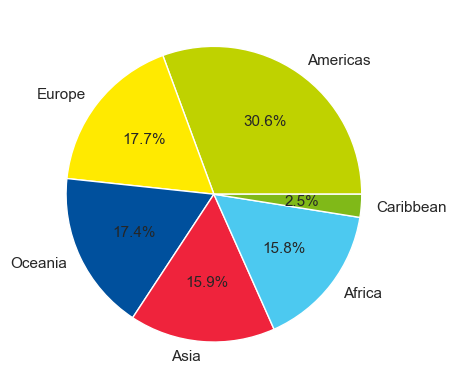

Pie chart of Total BCEs Sequestration by Continent:


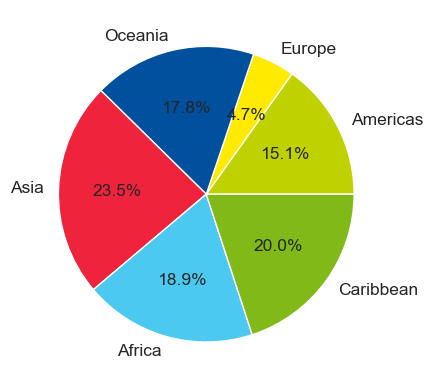

In [43]:
colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total Blue Carbon Sequestration by Continent:")
plt.pie(bd['Total Blue Carbon Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 11})
plt.show()

colors = [pal[continent] for continent in bd['Continent']]
print("Pie chart of Total BCEs Sequestration by Continent:")
plt.pie(bd['Total BCEs Sequestration (tC)'], colors=colors, labels=bd['Continent'], 
        autopct='%1.1f%%', textprops={'fontsize': 12.5})
plt.show()

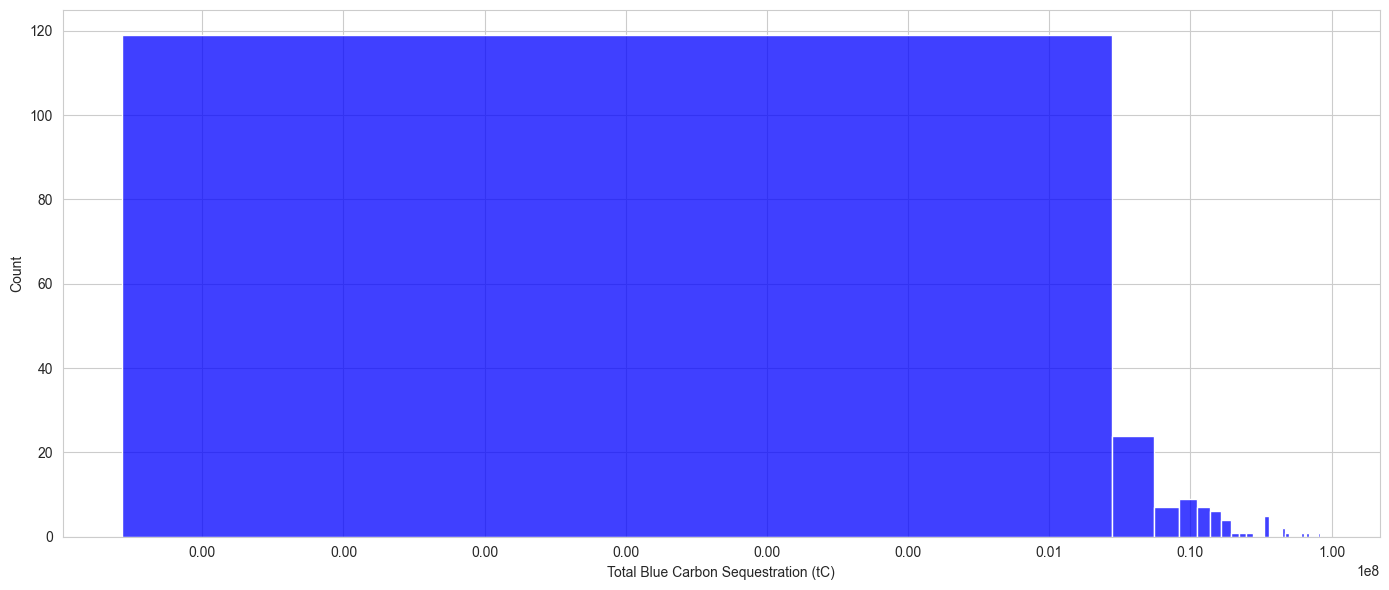

In [44]:
plt.figure(figsize=(14, 6))
sns.histplot(data=sdf, x='Total Blue Carbon Sequestration (tC)', bins=30, color='blue')
plt.xscale('log')
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.show()

In [45]:
# Build world geometries (USA split + ISO fixes)
world = build_world_geodataframe(WLD_SHP, USA_SPLIT_CSV)
wld   = world   # alias used by map cells and mapper_bce / map_and_barplot

# Join with plot_data and compute category labels for BCE totals
country_data_bce = build_country_data(
    world=world,
    plot_data=plot_data,
    var='uptake_total_mean',
    which='BCE',
)


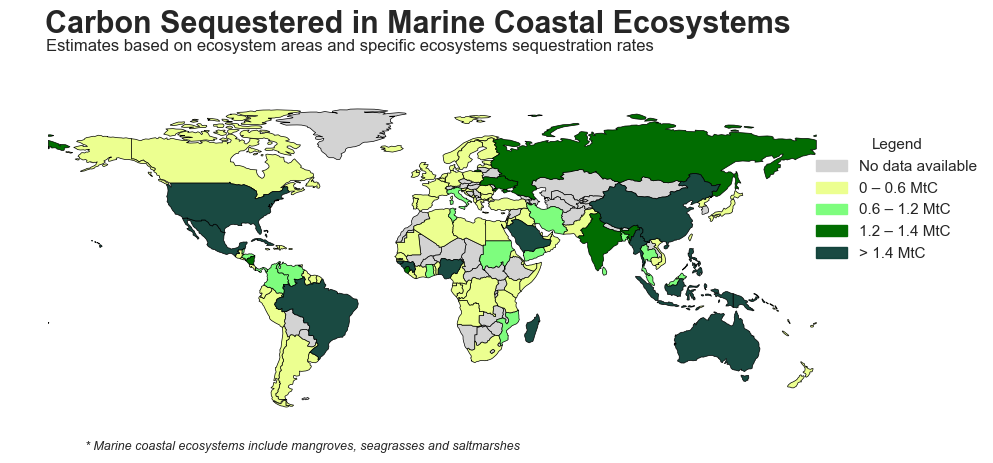

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
legend_patches = []
for cat, color in color_map2.items():
    subset = country_data_bce[country_data_bce['cat'] == cat]
    subset.plot(ax=ax, color=color, label=cat, edgecolor='black', linewidth=0.5)
    legend_patches.append(Patch(color=color, label=cat))

fig.text(0.05, 0.8, 'Carbon Sequestered in Marine Coastal Ecosystems', 
         fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.051, 0.764, "Estimates based on ecosystem areas and specific ecosystems sequestration rates", 
         fontsize=12, va='top', ha='left')

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 0.45),
           loc='lower center', ncol=1, fontsize=11, 
           title='Legend',
        title_fontsize=11, frameon=False)

ax.axis('off')
plt.figtext(0.525, 0.25, "* Marine coastal ecosystems include mangroves, seagrasses and saltmarshes", ha="right", fontsize=9, style="italic")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

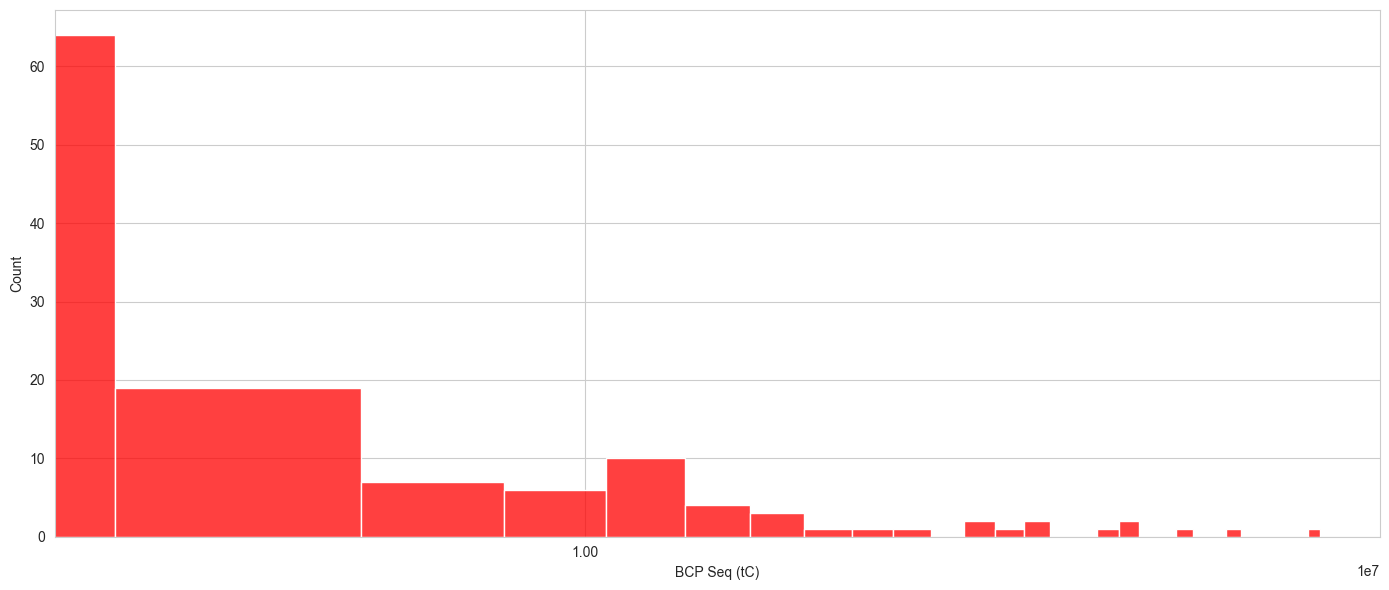

In [47]:
plt.figure(figsize=(14, 6))
sns.histplot(data=plot_data, x='BCP Seq (tC)', bins=30, color='red')
plt.xscale('log')
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.tight_layout()
plt.show()

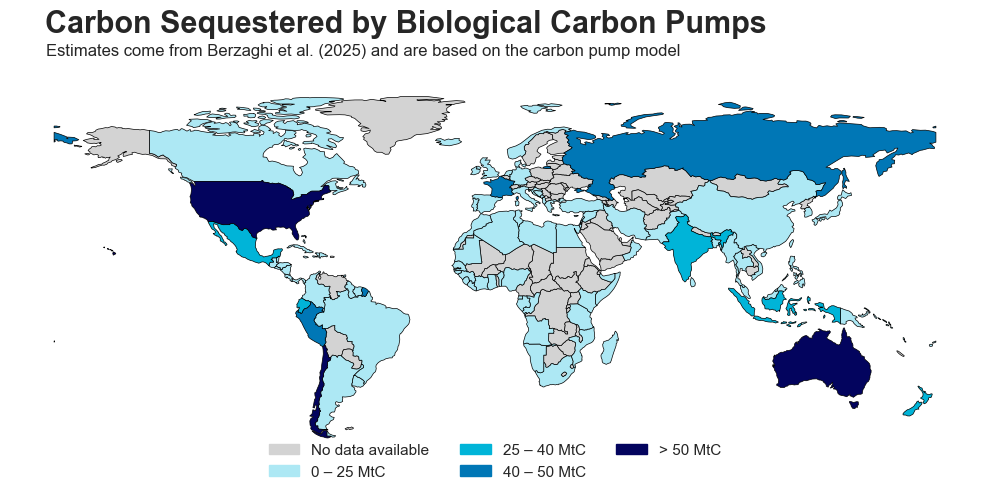

In [48]:
country_data_bcp = build_country_data(
    world=world,
    plot_data=plot_data,
    var='BCP Seq (tC)',
    which='BCP',
)

fig, ax = plt.subplots(figsize=(10, 8))
legend_patches = []

for cat, color in color_map3.items():
    subset = country_data_bcp[country_data_bcp['cat'] == cat]
    subset = subset[subset.geometry.is_valid & subset.geometry.notnull()]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, label=cat, edgecolor='black', linewidth=0.5)
        legend_patches.append(Patch(color=color, label=cat))

fig.text(0.05, 0.8125, 'Carbon Sequestered by Biological Carbon Pumps', 
         fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.051, 0.77, "Estimates come from Berzaghi et al. (2025) and are based on the carbon pump model", 
         fontsize=12, va='top', ha='left')

plt.legend(handles=legend_patches, bbox_to_anchor=(0.5, -0.1),
           loc='lower center', ncol=3, fontsize=11, 
           title='',
        title_fontsize=11, frameon=False)

ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [49]:
# Legacy column aliases used by sequestration / visualisation cells
ddf = data.copy()

ddf['Total_BCE_area_km2'] = ddf[
    ['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].sum(axis=1, skipna=True)
dq = ddf.dropna(subset=['uptake_salt_mean', 'uptake_seag_mean', 'uptake_mang_mean'])


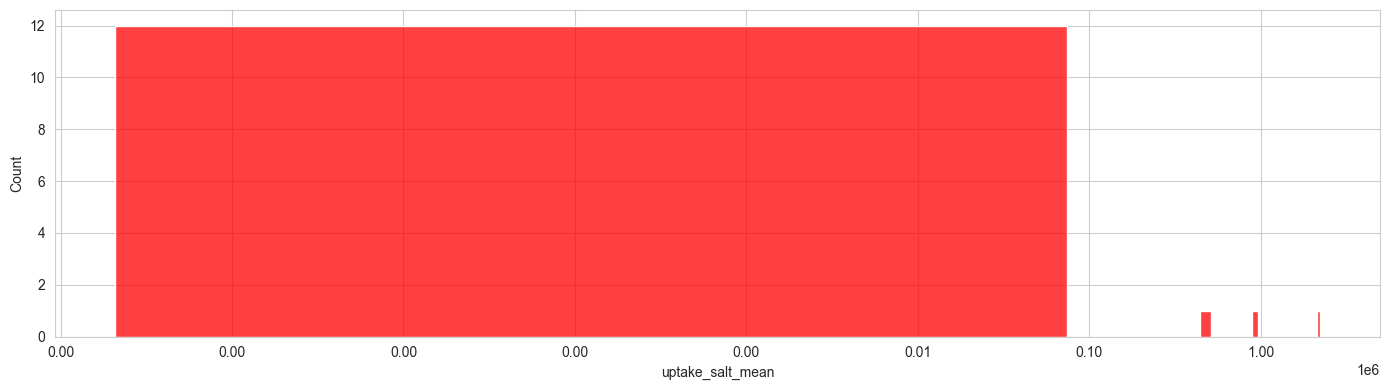

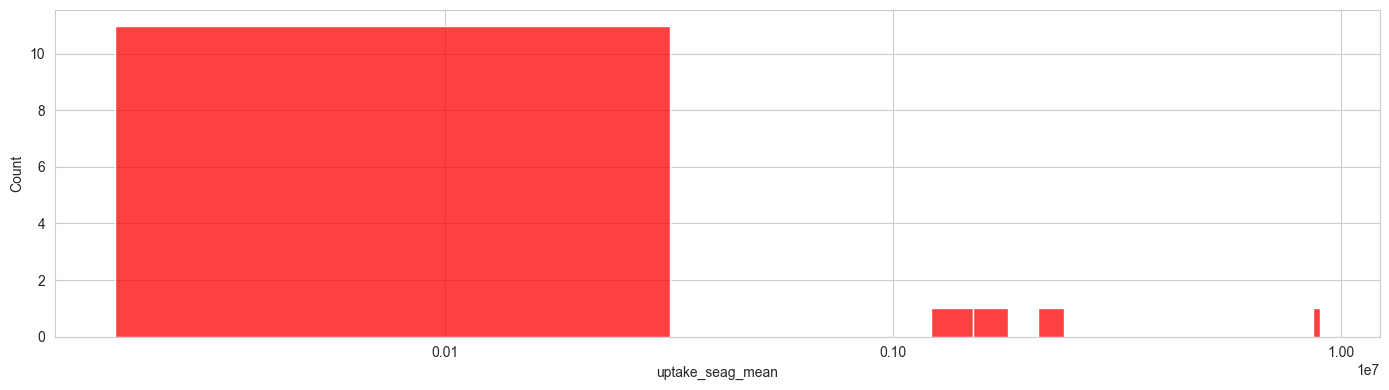

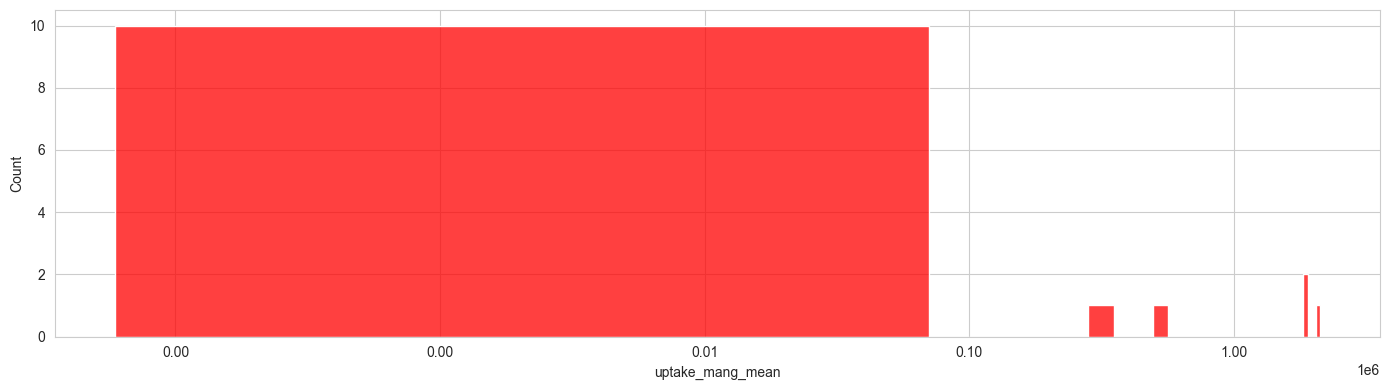

In [50]:
targvars = ['uptake_salt_mean', 'uptake_seag_mean', 'uptake_mang_mean']
colopat = ['#F2C94C', '#E27D60', '#85E3FF']

for var in targvars:
    plt.figure(figsize=(14, 4))
    sns.histplot(data=dq, x=var, bins=30, color='red')
    plt.xscale('log')
    plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    plt.gca().xaxis.set_major_formatter(ScalarFormatter())
    plt.tight_layout()
    plt.show()

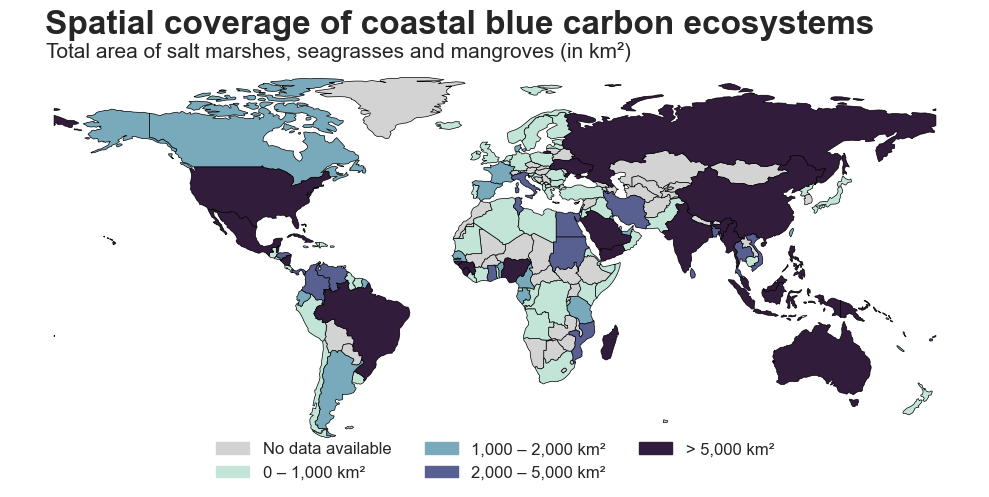

In [51]:
var = 'Total BCEs Area (km²)'
palet = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
title = 'Spatial coverage of coastal blue carbon ecosystems'
subtitle = "Total area of salt marshes, seagrasses and mangroves (in km²)"
ddb = plot_data.copy()
ddb['Total BCEs Area (km²)'] = ddb[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']].sum(axis=1, skipna=True)
mapper_bce(ddb, var, 'areas', palet, title, subtitle, world)

## EEZ Choropleth Test
Map total coastal BCE area (km²) over EEZ polygons (`plot_eez_choropleth`). Robinson projection, bins [100–500, 500–1k, 1k–2k, 2k–5k, 5k–50k], land in grey background.

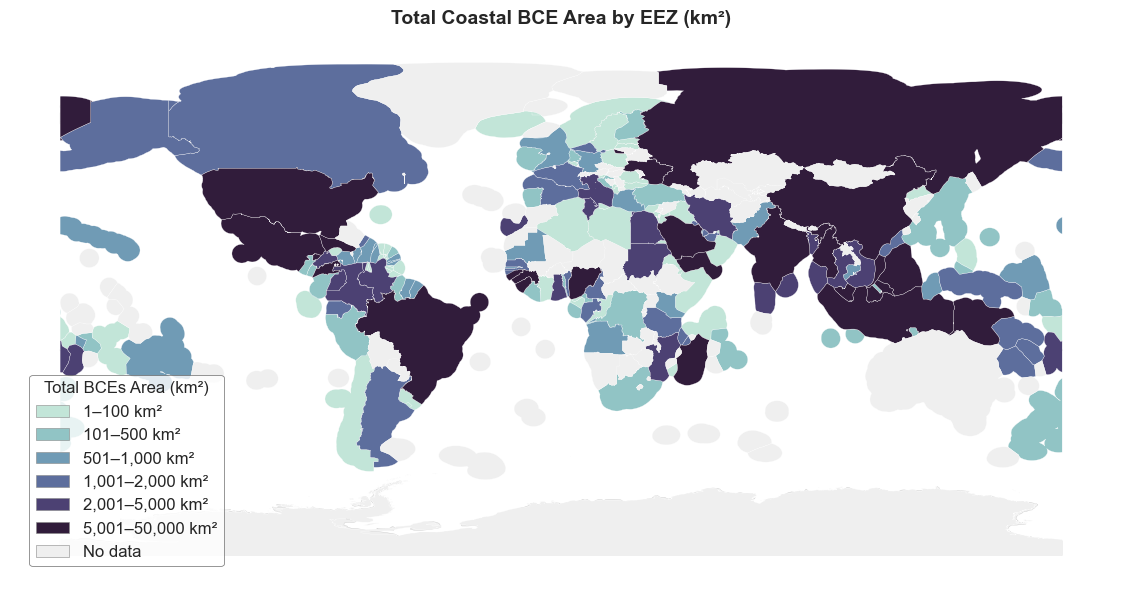

Display CRS  : EPSG:4326
Total bounds : [-180.  -90.  180.   87.]
Rows merged  : 328
Non-null values: 325


In [56]:
# EEZ file    : EEZ_land_union_v4_202410.shp  (data_source/shp/eez/)
# Join column : TERRITORY1  (present in plot_data)

# Build input: total BCE area per EEZ territory
eez_df = plot_data[
    ['TERRITORY1', 'saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']
].copy()
eez_df['Total BCEs Area (km²)'] = (
    eez_df[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']]
    .sum(axis=1, skipna=True)
)

fig, ax, eez_disp = plot_eez_choropleth(
    eez_gdf=EEZ_SHP,
    data_df=eez_df,
    value_col='Total BCEs Area (km²)',
    merge_on='TERRITORY1',
    world_gdf=WLD_SHP,
    bins=[0, 100, 500, 1000, 2000, 5000, 50000],
    palette='cubehelix',
    projection='EPSG:4326',
    missing_color='#efefef',
    legend_fontsize=12,
    figsize=(14, 6),
    title='Total Coastal BCE Area by EEZ (km²)',
    dissolve_by=None,
    clip_land=False,
)
plt.show()

# Diagnostic — inspect the reprojected EEZ layer returned by the function
print("Display CRS  :", eez_disp.crs)
print("Total bounds :", eez_disp.total_bounds.round(0))
print("Rows merged  :", len(eez_disp))
print("Non-null values:", eez_disp['Total BCEs Area (km²)'].notna().sum())


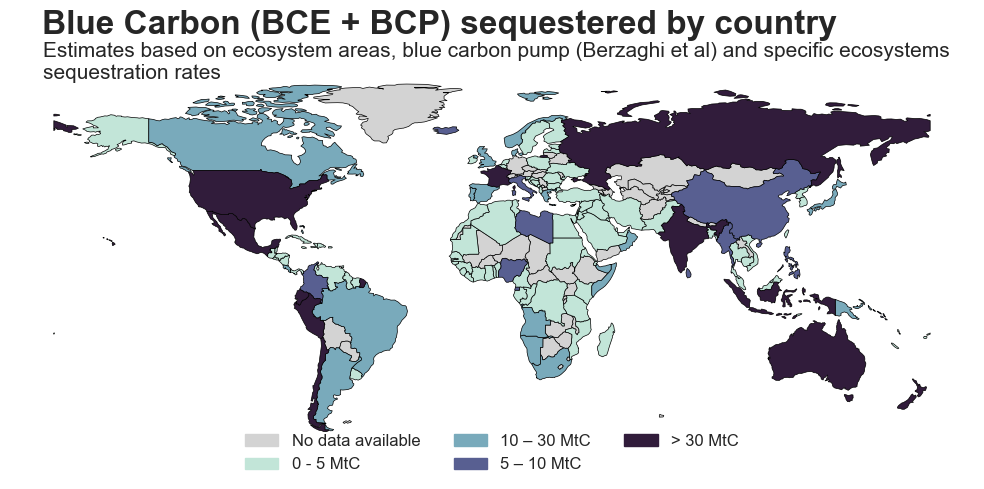

In [ ]:
var = 'Total BCseq'
palet = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
title = 'Blue Carbon (BCE + BCP) sequestered by country'
subtitle = "Estimates based on ecosystem areas, blue carbon pump (Berzaghi et al) and specific ecosystems \nsequestration rates"
mapper_bce(ddb, var, 'Total BCW uptake', palet, title, subtitle)

### BCE Area and Uptake Bar Charts

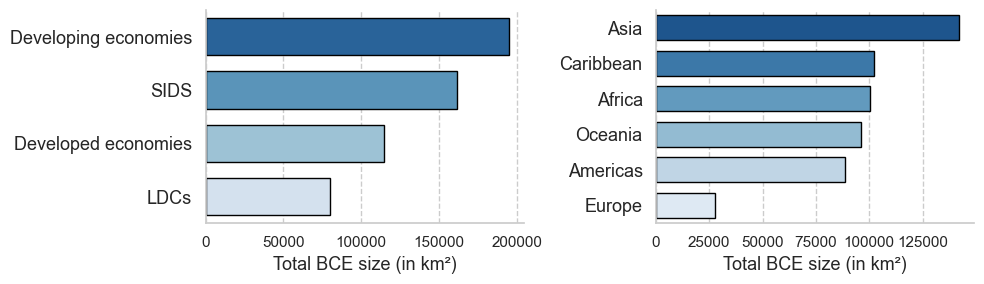

In [ ]:
grou = ddf.groupby('Groups')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou['Total_BCE_area_km2'] = grou['Total_BCE_area_km2']

grou2 = ddf.groupby('Continent')['Total_BCE_area_km2'].sum().sort_values(ascending=False).reset_index()
grou2['Total_BCE_area_km2'] = grou2['Total_BCE_area_km2']

# on 1 row and 2 cols
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
sns.set_theme(style='whitegrid')
# Groups
sns.barplot(data=grou, x='Total_BCE_area_km2', y='Groups', width=0.7, palette='Blues_r', ax=axs[0], edgecolor='black')
axs[0].set_ylabel('')
axs[0].set_yticklabels(axs[0].get_yticklabels(), fontsize=13)
axs[0].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[0])
axs[0].grid(True, axis='x', linestyle='--')

# Continents
sns.barplot(data=grou2, x='Total_BCE_area_km2', y='Continent', width=0.7, palette='Blues_r', ax=axs[1], edgecolor='black')
axs[1].set_ylabel('')
axs[1].set_yticklabels(axs[1].get_yticklabels(), fontsize=13)
axs[1].set_xlabel('Total BCE size (in km²)', fontsize=13)
sns.despine(ax=axs[1])
axs[1].grid(True, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

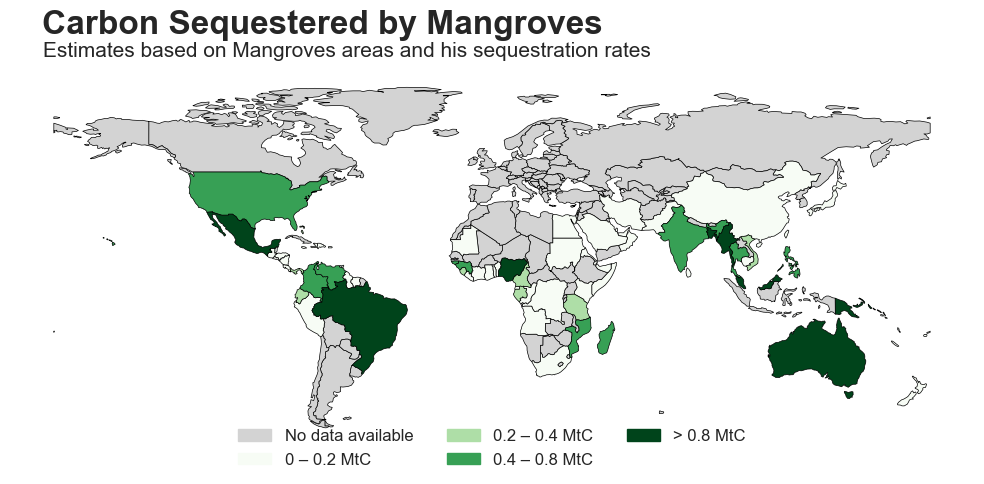

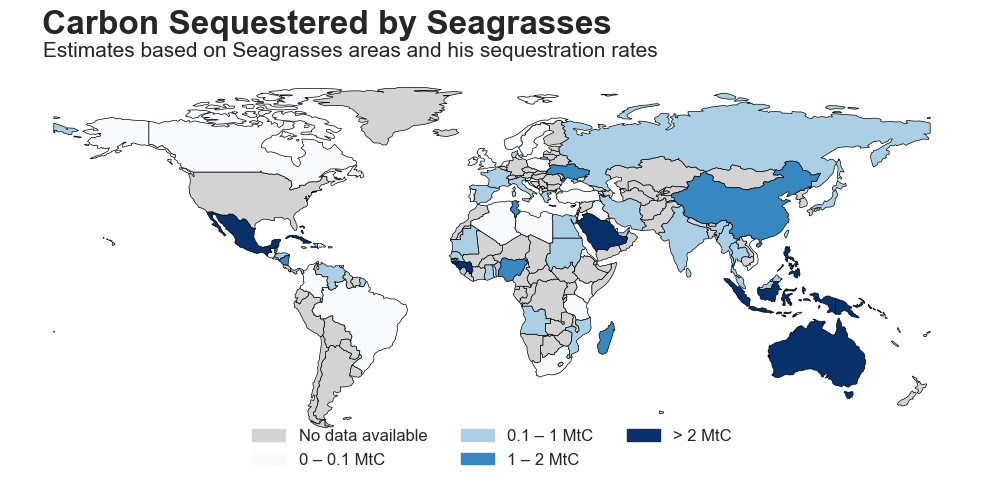

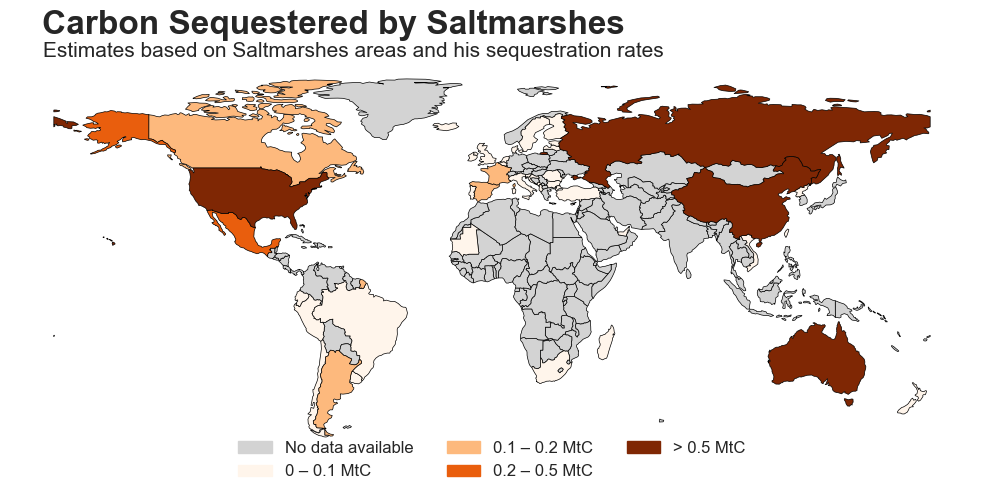

In [ ]:
Dictvars = {
    'Mangroves': ['Uptake Mang (t/km2)', 'Greens', 'Carbon Sequestered by Mangroves',
                  'Estimates based on Mangroves areas and his sequestration rates'],
    'Seagrasses': ['Uptake Seag (t/km2)', 'Blues', 'Carbon Sequestered by Seagrasses',
                   'Estimates based on Seagrasses areas and his sequestration rates'],
    'Saltmarshes': ['Uptake Salt (t/km2)', 'Oranges', 'Carbon Sequestered by Saltmarshes',
                    'Estimates based on Saltmarshes areas and his sequestration rates']
}

for ecosystem, (var, palet, title, subtitle) in Dictvars.items():
    mapper_bce(ddb, var, ecosystem, palet=palet, title=title, subtitle=subtitle)

In [ ]:
ddf.groupby('Groups')['tot_uptake (tC)'].mean().sort_values(ascending=False).reset_index()

,Groups,tot_uptake (tC)
0,LDCs,"699,556.4029"
1,Developing economies,"679,221.7019"
2,SIDS,"639,253.5858"
3,Developed economies,"562,928.6476"


In [ ]:
ddf.groupby('Groups')['Total BCseq'].mean().sort_values(ascending=False).reset_index()

,Groups,Total BCseq
0,Developed economies,"10,234,783.8548"
1,Developing economies,"7,043,086.7367"
2,SIDS,"3,129,045.6259"
3,LDCs,"2,879,513.1112"


<function matplotlib.pyplot.show(close=None, block=None)>

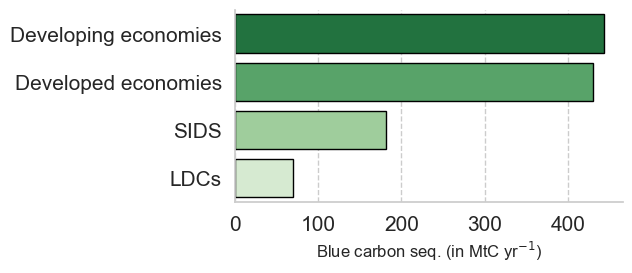

In [ ]:
grou = ddf.groupby('Groups')['Total BCseq'].sum().sort_values(ascending=False).reset_index()
grou['Total BCseq'] = grou['Total BCseq']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2.5))
sns.barplot(data=grou, x='Total BCseq', y='Groups', width=0.8, palette='Greens_r', edgecolor='black')
# text on bars
# for p in plt.gca().patches:
#     plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2, 
#                    f'{p.get_width():.2f}', va='center', ha='left', fontsize=9, color='steelblue')
plt.ylabel('')
plt.xlabel('Blue carbon seq. (in MtC yr$^{-1}$)')
sns.despine()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

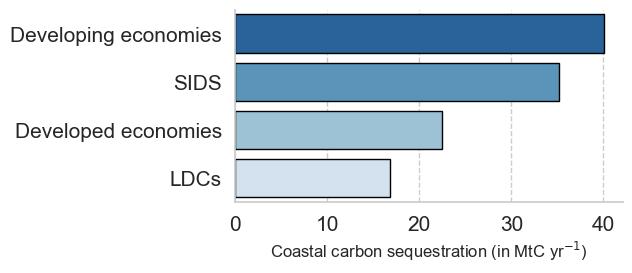

In [ ]:
grou = ddf.groupby('Groups')['tot_uptake (tC)'].sum().sort_values(ascending=False).reset_index()
grou['tot_uptake (tC)'] = grou['tot_uptake (tC)']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2.5))
sns.barplot(data=grou, x='tot_uptake (tC)', y='Groups', width=0.8, palette='Blues_r', edgecolor='black')
# text on bars
# for p in plt.gca().patches:
#     plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2, 
#                    f'{p.get_width():.2f} MtC', va='center', ha='left', fontsize=9)
plt.ylabel('')
plt.xlabel('Coastal carbon sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

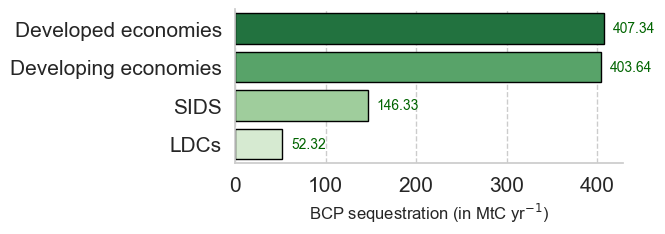

In [ ]:
grou = ddf.groupby('Groups')['BCP Seq (tC)'].sum().sort_values(ascending=False).reset_index()
grou['BCP Seq (tC)'] = grou['BCP Seq (tC)']/1e6

sns.set_theme(style='whitegrid')
plt.figure(figsize=(5, 2))
sns.barplot(data=grou, x='BCP Seq (tC)', y='Groups', width=0.8, palette='Greens_r', edgecolor='black')
# text on bars
for p in plt.gca().patches:
    plt.gca().text(p.get_width() + 10, p.get_y() + p.get_height()/2,
                   f'{p.get_width():.2f}', va='center', ha='left', fontsize=10, color='darkgreen')
plt.ylabel('')
plt.xlabel('BCP sequestration (in MtC yr$^{-1}$)')
sns.despine()
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.grid(True, axis='x', linestyle='--')
plt.show

In [ ]:
t = ddf[['ISO', 'Continent', 'Groups', 'Uptake Salt (t/km2)', 'Uptake Seag (t/km2)',
     'Uptake Mang (t/km2)', 'BCP Seq (tC)']].copy()
# Only sum numeric columns to avoid TypeError
ecosystem_totals = t.select_dtypes(include='number').sum()
ecosystem_totals = ecosystem_totals / 1e6 
ecosystem_totals = ecosystem_totals.sort_values(ascending=False)  # Fixing the sort_values issue
print('Sequestration by NCS (Natural Carbon Sink) in MtC by year')
ecosystem_totals

Sequestration by NCS (Natural Carbon Sink) in MtC by year


BCP Seq (tC)          1,017.1517
Uptake Seag (t/km2)      86.0940
Uptake Mang (t/km2)      20.5495
Uptake Salt (t/km2)       9.2657
dtype: float64

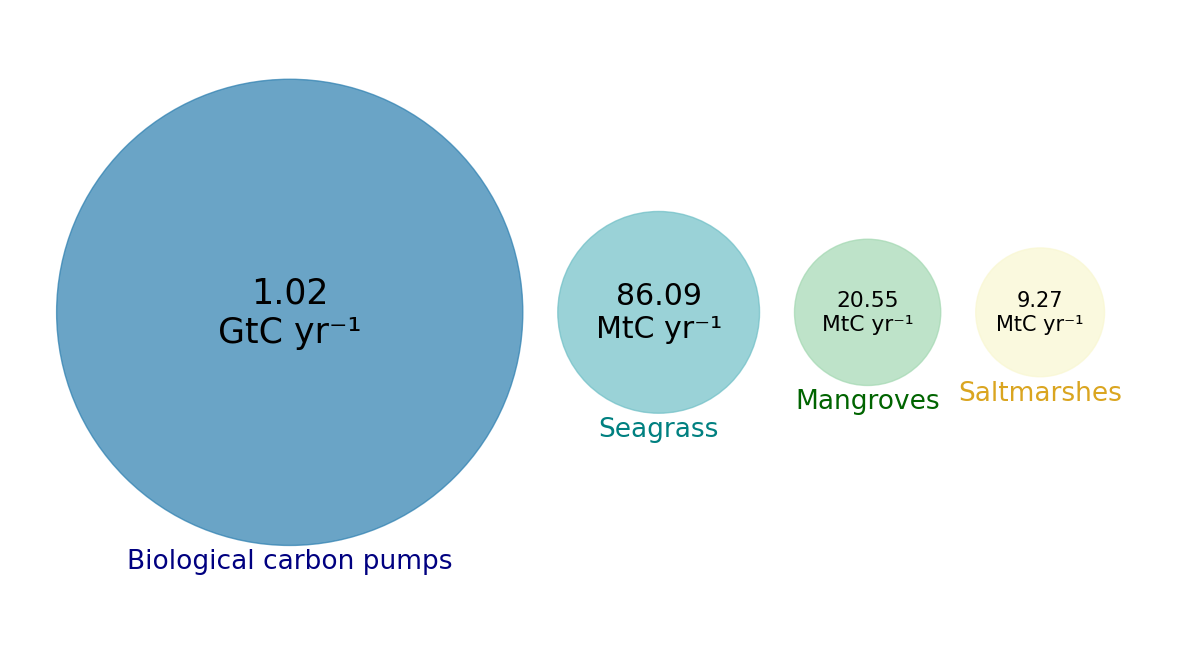

In [ ]:
ecosystem_totals.index = ["Biological carbon pumps", "Seagrass", "Mangroves", "Saltmarshes"]
circle_area_plot(
    ecosystem_totals=ecosystem_totals,
    colors=['#2b7eaf', '#6fbfc6', '#a3d8b2', '#f9f7d1'],
    label_colors=['navy', 'teal', 'darkgreen', 'goldenrod']
)


In [ ]:
uptake_by_continent = t.groupby('Continent').agg({
    'BCP Seq (tC)': 'sum',
    'Uptake Salt (t/km2)': 'sum',
    'Uptake Seag (t/km2)': 'sum',
    'Uptake Mang (t/km2)': 'sum'
}).reset_index()
uptake_by_continent = uptake_by_continent.rename(columns={
    'BCP Seq (tC)': 'Carbon Pumps',
    'Uptake Salt (t/km2)': 'Saltmarshes',
    'Uptake Seag (t/km2)': 'Seagrasses',
    'Uptake Mang (t/km2)': 'Mangroves'
})
uptake_by_continent[['Carbon Pumps', 'Saltmarshes',
                     'Seagrasses', 'Mangroves']] = (
    uptake_by_continent[['Carbon Pumps', 'Saltmarshes',
                         'Seagrasses', 'Mangroves']] / 1e6
)
uptake_by_continent.to_csv(SUMMARY_DIR / 'sequestration_by_continent.csv', index=False)
uptake_by_continent


## Regressions

Log-log regression models linking BCW to EEZ size, CO₂ emissions, and debt.

In [ ]:
sns.set_theme(style='whitegrid')

Regression equation: $y = 9.61 + 0.70x$ | $R² = 0.20$


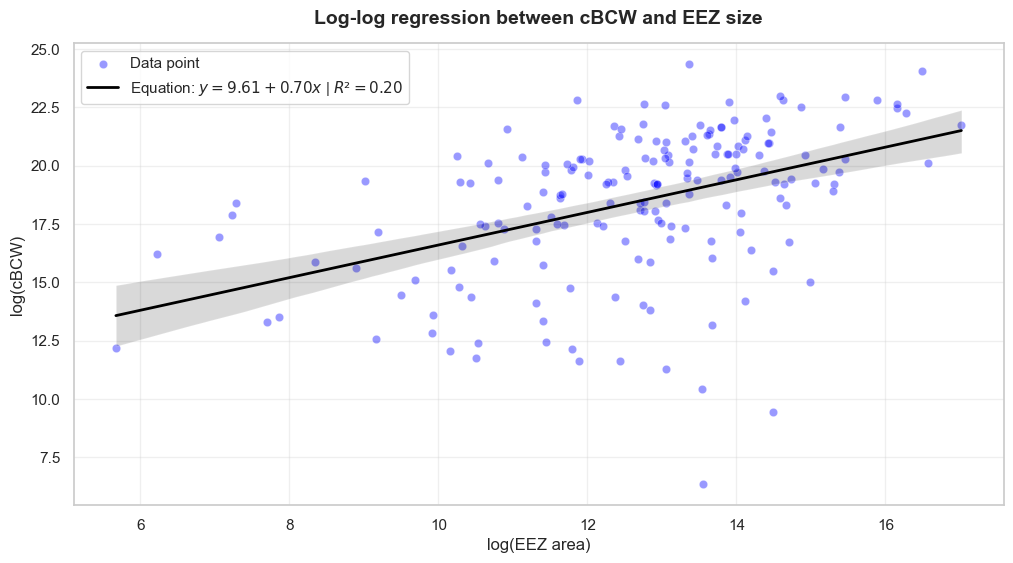

In [ ]:
df = data.copy()
df = df[(df['Area_EEZ_KM2'] > 0) & (df['cBCW'] > 0)].copy()
df['log_EEZ'] = np.log(df['Area_EEZ_KM2'])
df['log_cBCW'] = np.log(df['cBCW'])
df = df.dropna(subset=['log_EEZ', 'log_cBCW'])
X = df['log_EEZ']
y = df['log_cBCW']
X = sm.add_constant(X)  # intercept

model = sm.OLS(y, X).fit()
a_hat = model.params['const']  # Intercept (a^)
b_hat = model.params['log_EEZ']  # Coefficient (b^)
R2 = model.rsquared  # Coefficient R²

# regression formula
equation = f"$y = {a_hat:.2f} + {b_hat:.2f}x$ | $R² = {R2:.2f}$"  
print(f"Regression equation: {equation}")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='log_EEZ', y='log_cBCW', alpha=0.4, color='blue')
sns.regplot(x='log_EEZ', y='log_cBCW', data=df, scatter=False, color='black', line_kws={"linewidth": 2})
plt.xlabel('log(EEZ area)')
plt.ylabel('log(cBCW)')
plt.title('Log-log regression between cBCW and EEZ size', 
          fontweight='bold', fontsize=14, pad=14)
plt.legend(labels=['Data point', f'Equation: {equation}'], loc='best')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
a = data.copy()
a['tot_uptake (tC)'] = a['uptake_total_mean']   # alias for regression cells
a['total_BCE_area'] = a[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']].fillna(0).sum(axis=1)
a = a[['ISO', 'Groups', 'Population', 'Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'total_BCE_area',
       'tot_uptake (tC)', 'cBCW', 'cBCW_per_capita']]
a.rename(columns={'Area_EEZ_KM2': 'EEZ'}, inplace=True)
a['total_BCE_area'] = a['total_BCE_area'].replace(0, np.nan)
a['log EEZ'] = np.log(a['EEZ'])
a['log BCE'] = np.log(a['total_BCE_area'])
a.head()


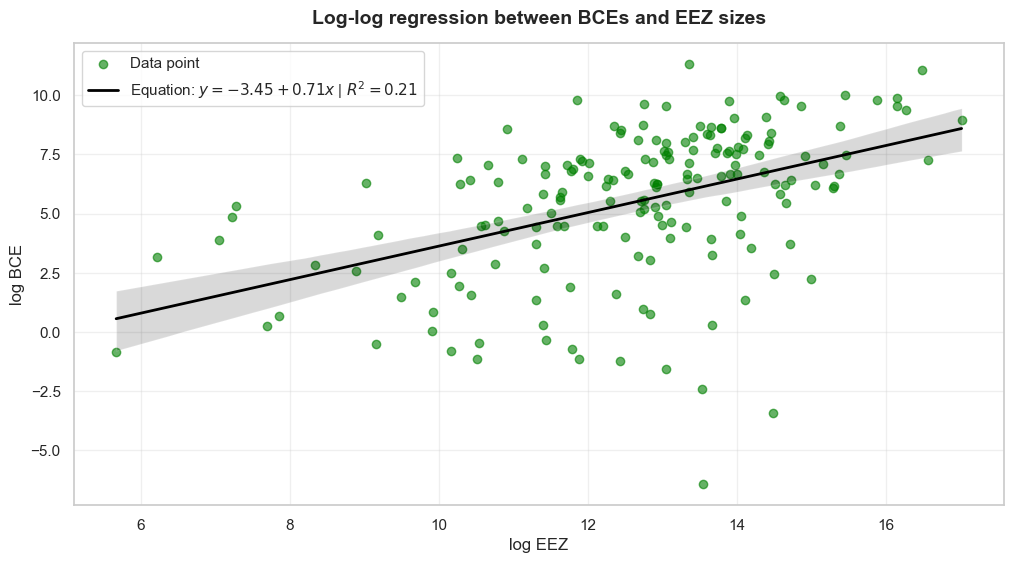

In [ ]:
a = a.dropna(subset=['log EEZ', 'log BCE'])
X = a['log EEZ']
y = a['log BCE']
X = sm.add_constant(X)  # intercept
model = sm.OLS(y, X).fit()
a_hat = model.params['const']  # Interception (a^)
b_hat = model.params['log EEZ']  # Coefficient (b^)

R2 = model.rsquared  # Coefficient R²
equation = f"$y = {a_hat:.2f} + {b_hat:.2f}x$ | $R^2 = {R2:.2f}$"

plt.figure(figsize=(12, 6))
plt.scatter(a['log EEZ'], a['log BCE'], color='green', alpha=0.6)
sns.regplot(x='log EEZ', y='log BCE', data=a, scatter=False, color='black', line_kws={"linewidth": 2})
plt.xlabel('log EEZ')
plt.ylabel('log BCE')
plt.title('Log-log regression between BCEs and EEZ sizes', 
          fontweight='bold', fontsize=14, pad=14)
plt.legend(labels=['Data point', f'Equation: {equation}'], loc='best')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
regplotter(data, 'CO2_emissions_2023', 'log CO2',
           'Log-log Regression Between BCW and CO2 emissions per Capita',
           'CO2 emissions')

ddf['BCEs area'] = ddf[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']].fillna(0).sum(axis=1).replace(0, np.nan)
ddt = data.copy()
ddt['BCEs Size'] = ddt[['saltmarshes_area_km2', 'seagrasses_area_km2', 'mangroves_area_km2']].fillna(0).sum(axis=1).replace(0, np.nan)
ddt['Area_EEZ_KM2_per_capita'] = ddt['Area_EEZ_KM2'] / ddt['Population']
ddt['BCEs_PCAP'] = ddt['BCEs Size'] / ddt['Population']
ddt['cBCW'] = ddt['cBCW']
ddt['BCW'] = ddt['Total BCW']
ddt['EEZ'] = ddt['Area_EEZ_KM2']

regplotter(ddt, 'Area_EEZ_KM2', 'log(EEZ Size)',
           'Log-log relationship between BCE and EEZ sizes',
           'EEZ', 'BCEs Size', 'green')
regplotter(ddt, 'Area_EEZ_KM2', 'log(EEZ)',
           'Log-log relationship between BCE and EEZ sizes in per-capita values',
           'Area_EEZ_KM2_per_capita', 'BCEs_PCAP', 'brown')
regplotter(data, 'Debt (2015 US$)', 'log Debt',
           'Log-log regression between BCW and Debt',
           'Debt', 'Total BCW')

regplotter(ddt, 'EEZ', 'log(EEZ)',
           'Log-log relationship between BCW and EEZ size',
           'EEZ', 'BCW', 'black')


In [ ]:
# BCW vs CO2 emissions per capita
regplotter_log_axes(
    dtf=data,
    var='CO2_emissions_2023',
    varname='log CO2',
    title='Log-log Regression Between coastal BCW and CO2 emissions per capita',
    xlab='CO2 emissions per capita',
    yvar='cBCW'
)

# BCW vs Debt per capita
regplotter_log_axes(
    dtf=data,
    var='Debt (2015 US$)',
    varname='log Debt',
    title='Log-log Regression Between coastal BCW and Debt per capita',
    xlab='Debt per capita (2015 US$)',
    yvar='cBCW'
)

# Total BCW per capita vs EEZ per capita
regplotter_log_axes(
    dtf=data,
    var='Area_EEZ_KM2_per_capita',
    varname='log EEZ',
    title='Log-log relationship between Total BCW and EEZ per capita',
    xlab='EEZ per capita (km²)',
    yvar='Total BCW_per_capita'
)


## Bar Charts — BCW Analysis

Country and group-level bar charts for coastal BCW, BCP wealth, and total BCW.

### Coastal BCW per Capita (Top 30)

In [ ]:
df = data.copy()
by_country = df[['ISO', 'cBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)

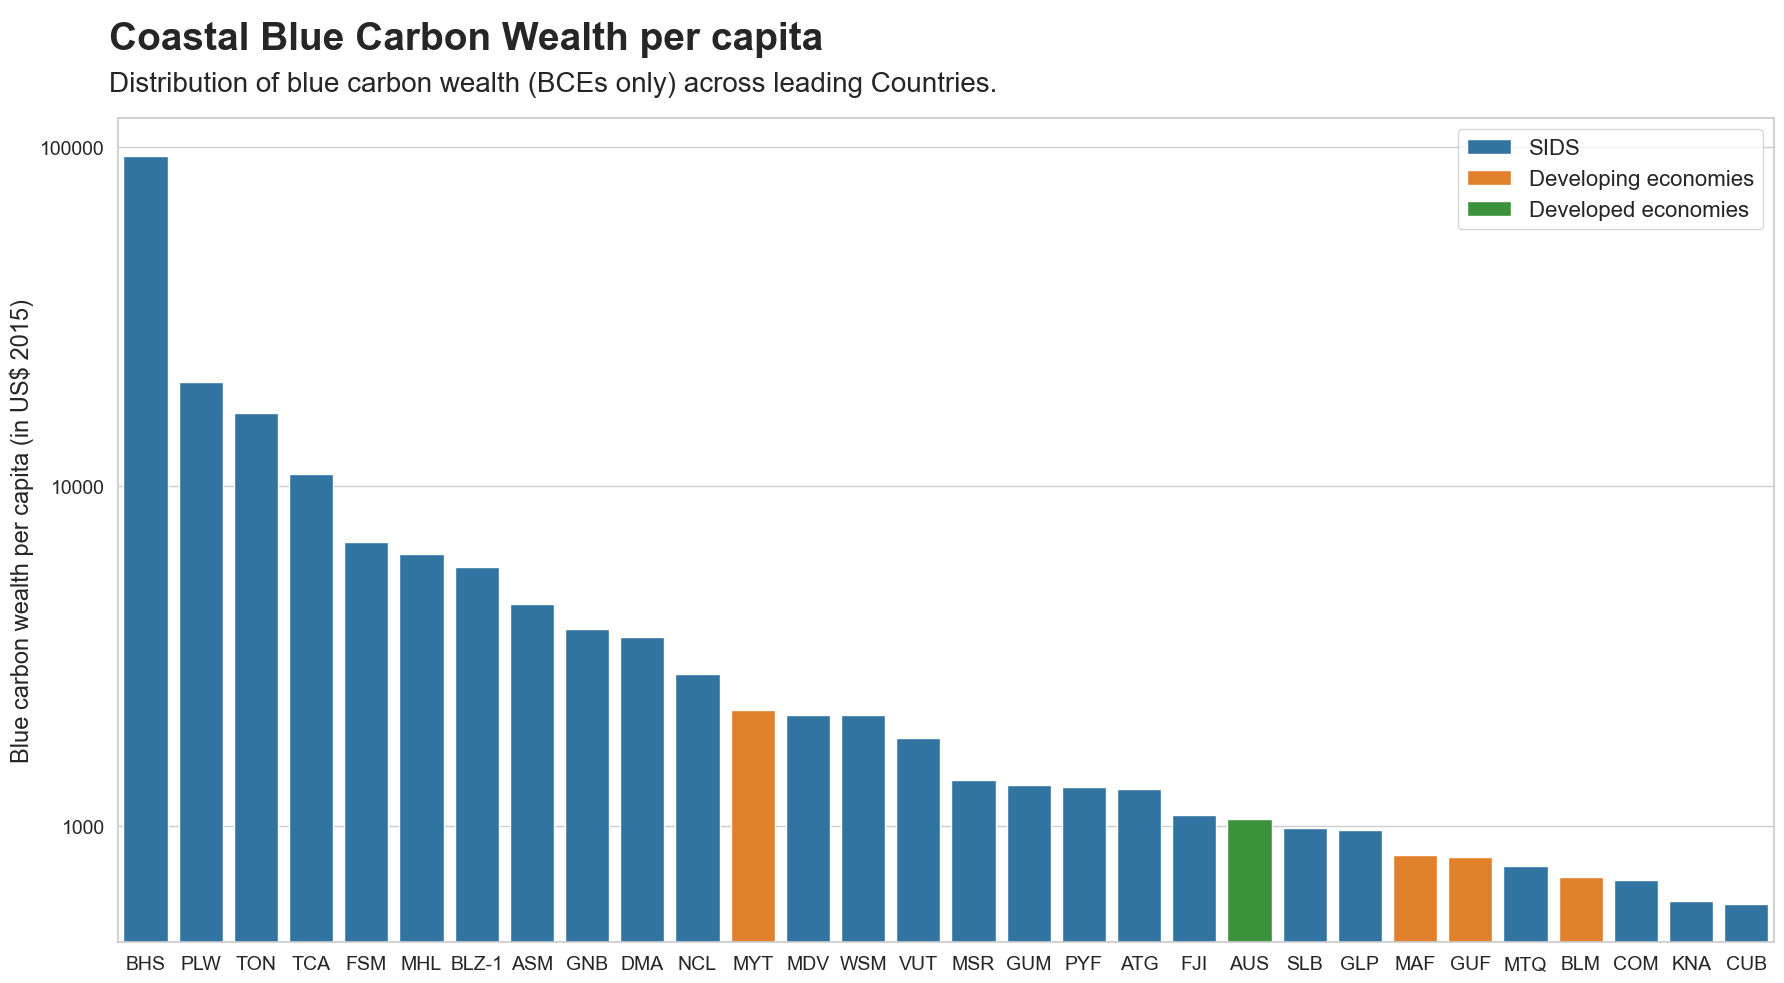

In [ ]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='cBCW_per_capita', palette= 'tab10', hue='Groups',ax=ax)
fig.text(0.065, 0.97, 'Coastal Blue Carbon Wealth per capita', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.065, 0.92, 'Distribution of blue carbon wealth (BCEs only) across leading Countries.', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Blue carbon wealth per capita (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

In [ ]:
color_mapping = GROUPS_COLORMAP


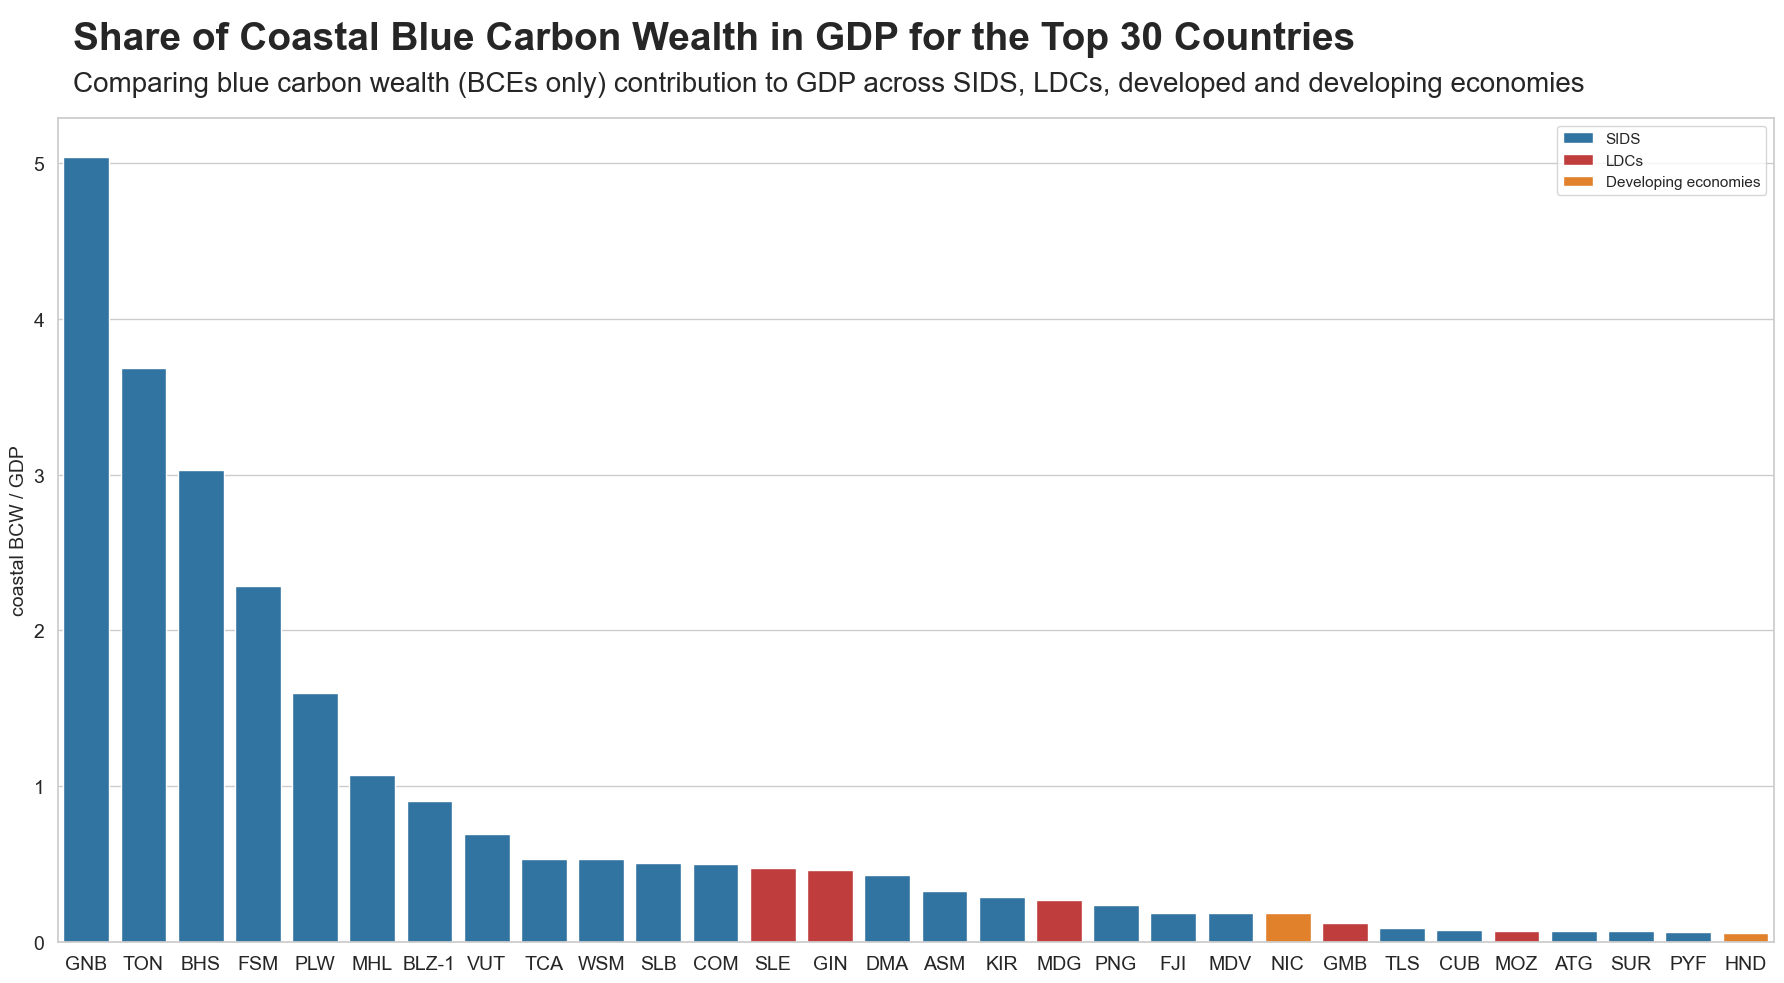

In [ ]:
by_bg = df[['ISO', 'Groups', 'cBCW', 'GDP']]
by_bg['BCW_to_GDP_ratio'] = by_bg['cBCW'] / by_bg['GDP']
by_bg['BCW_to_GDP_ratio'] = by_bg['BCW_to_GDP_ratio'].replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
by_bg = by_bg.sort_values(by='BCW_to_GDP_ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='BCW_to_GDP_ratio', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.045, 0.97, 'Share of Coastal Blue Carbon Wealth in GDP for the Top 30 Countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.045, 0.92, 'Comparing blue carbon wealth (BCEs only) contribution to GDP across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('coastal BCW / GDP', fontsize=14)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

### BCP Wealth per Capita (Top 30)

In [ ]:
by_country = data[['ISO', 'country_name', 'oBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='oBCW_per_capita', ascending=False)

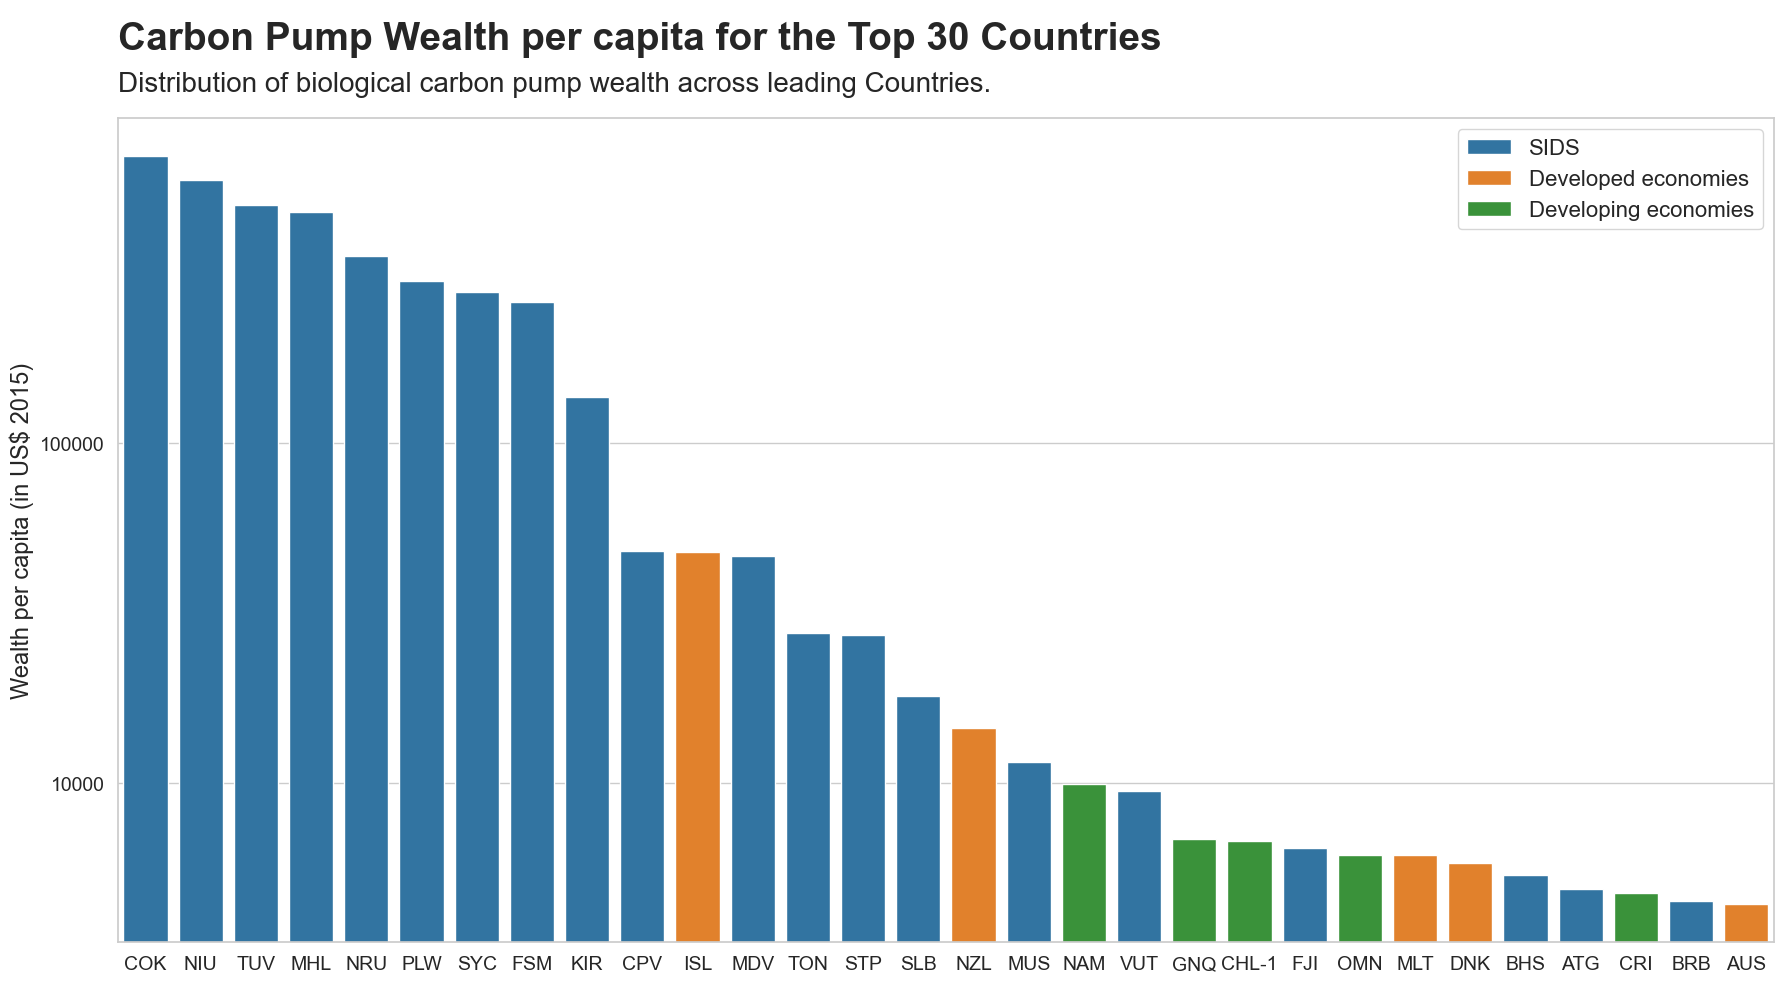

In [ ]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='oBCW_per_capita', palette= 'tab10', hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Carbon Pump Wealth per capita for the Top 30 Countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Distribution of biological carbon pump wealth across leading Countries.', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Wealth per capita (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

In [ ]:
by_bg = df[['ISO', 'Groups', 'oBCW', 'GDP']]
by_bg['oBCW to GDP ratio'] = by_bg['oBCW'] / by_bg['GDP']
by_bg['oBCW to GDP ratio'] = by_bg['oBCW to GDP ratio'].replace([np.inf, -np.inf], np.nan)
by_bg = by_bg.sort_values(by='oBCW to GDP ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='oBCW to GDP ratio', palette=color_mapping, hue='Groups', ax=ax)
fig.text(0.045, 0.97, 'Share of BCP Wealth in GDP for the Top 30 Countries',
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.045, 0.92, 'Comparing biological carbon pump wealth (oBCW) contribution to GDP across SIDS, LDCs, developed and developing economies',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('oBCW / GDP', fontsize=14)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend()
plt.show()


### Total BCW per Capita (Top 30)

In [ ]:
by_country = df[['ISO', 'country_name', 'Total BCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='Total BCW_per_capita', ascending=False)

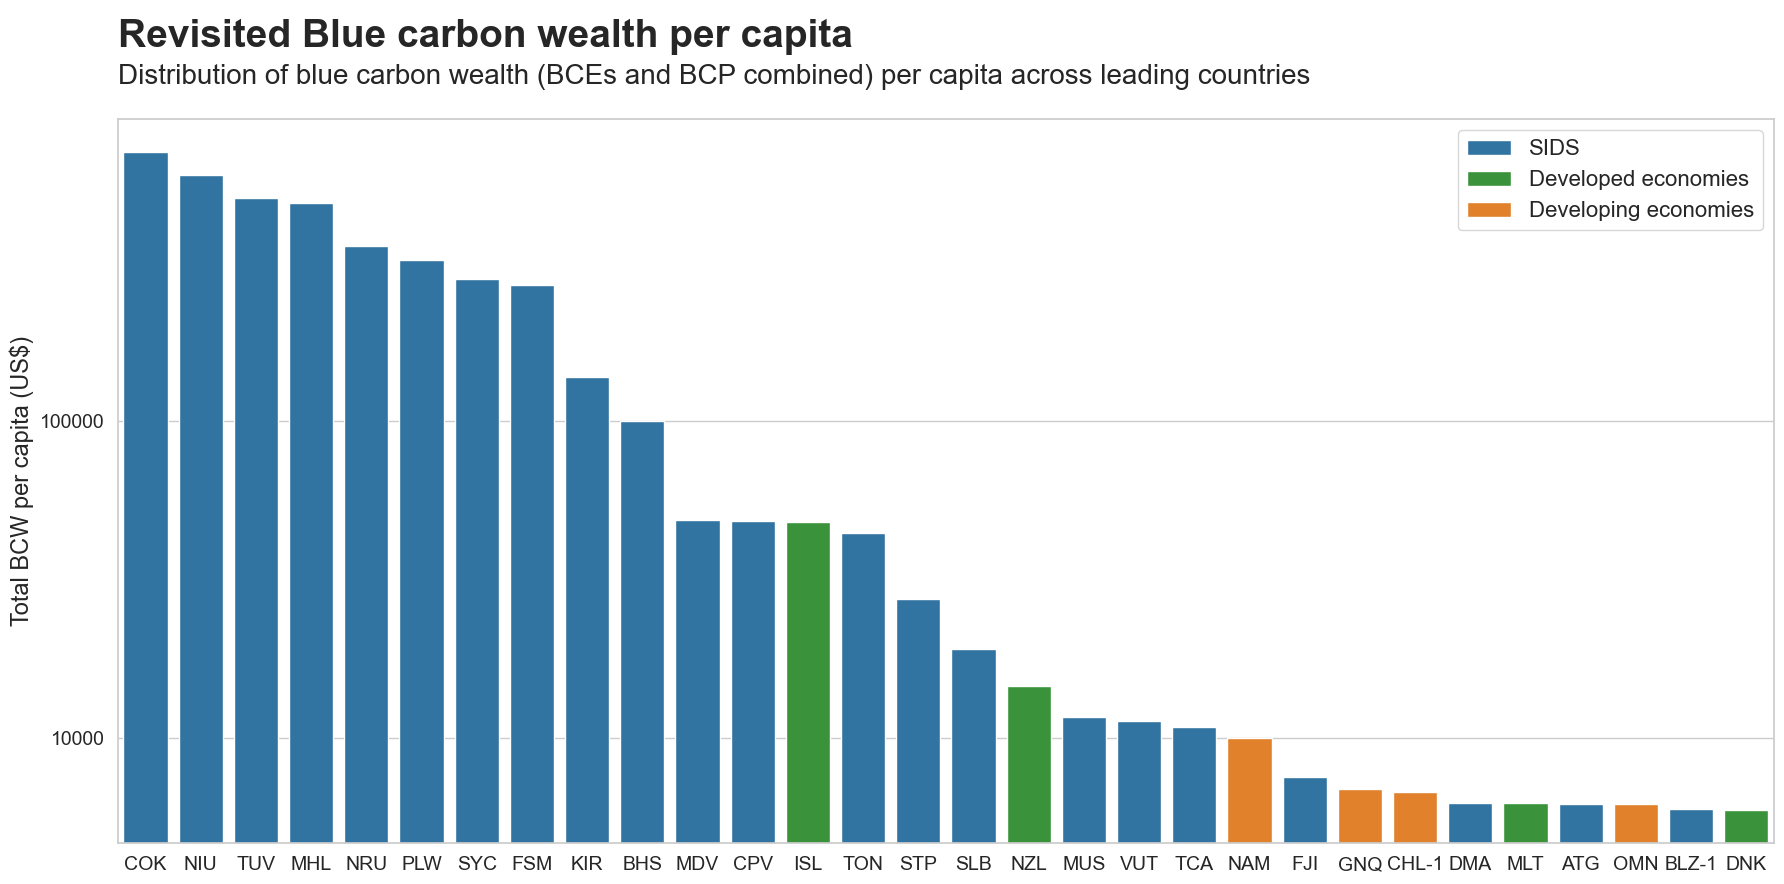

In [ ]:
fig, ax = plt.subplots(figsize=(18, 9))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='Total BCW_per_capita', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Revisited Blue carbon wealth per capita', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Distribution of blue carbon wealth (BCEs and BCP combined) per capita across leading countries',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Total BCW per capita (US$)', fontsize=17)
plt.xlabel('')
plt.xticks(fontsize=17)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

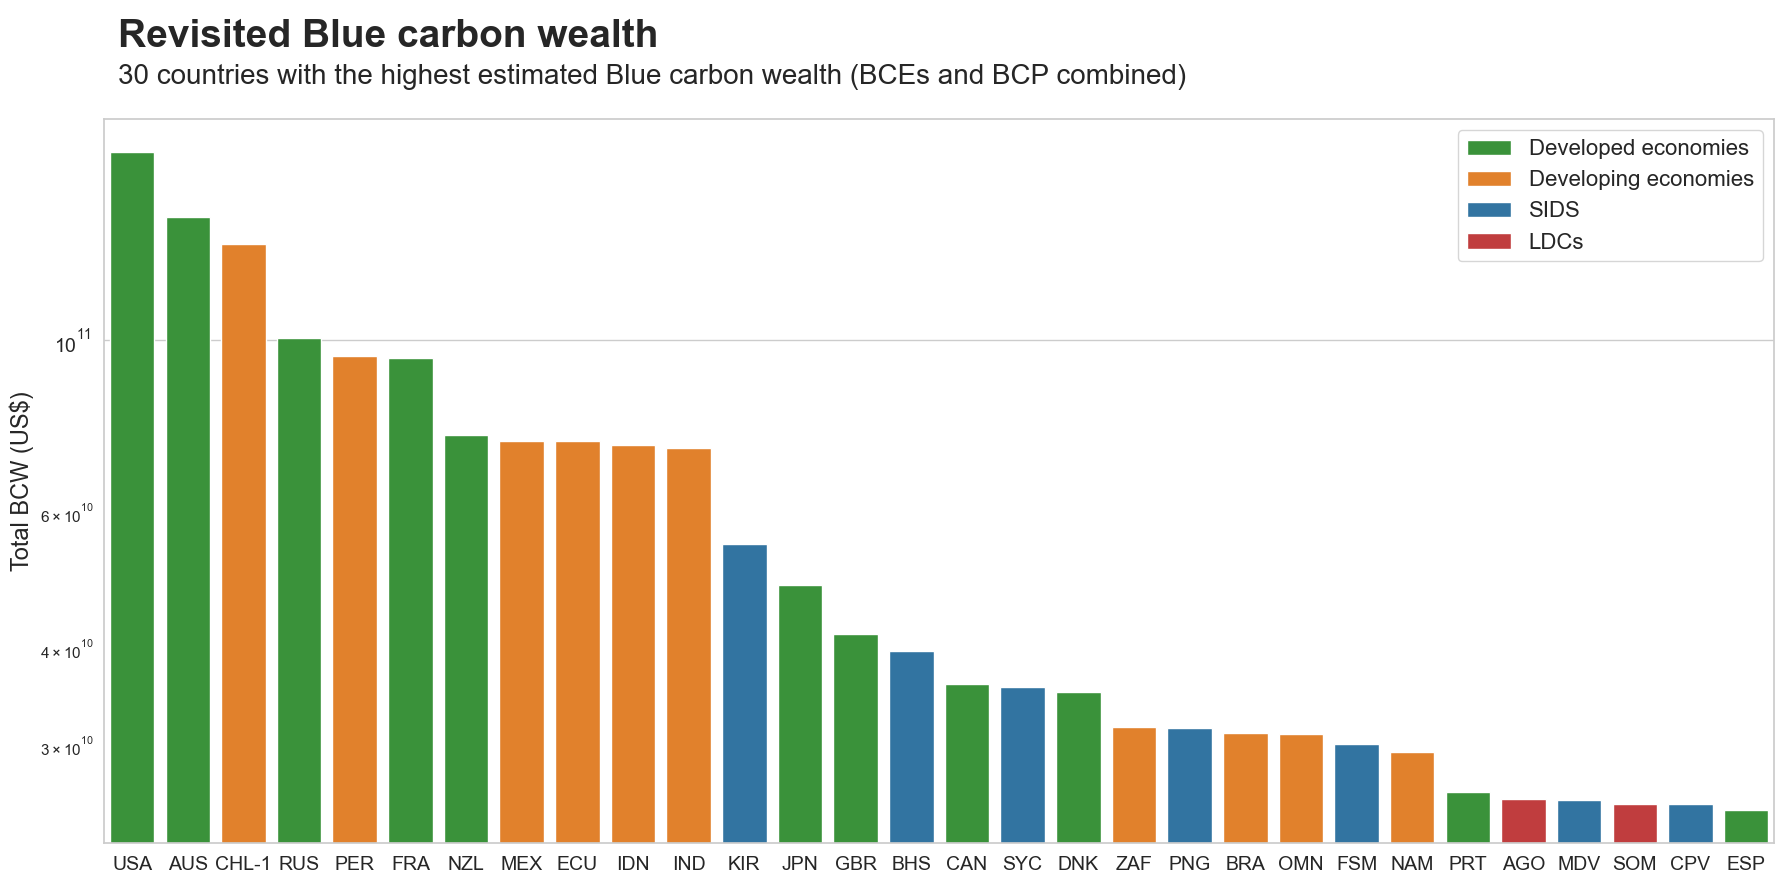

In [ ]:
by_country = df[['ISO', 'Total BCW', 'Groups']]
by_country = by_country.sort_values(by='Total BCW', ascending=False)

fig, ax = plt.subplots(figsize=(18, 9))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(30), x='ISO', y='Total BCW', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'Revisited Blue carbon wealth', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, '30 countries with the highest estimated Blue carbon wealth (BCEs and BCP combined)',
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('Total BCW (US$)', fontsize=17)
plt.xlabel('')
plt.xticks(fontsize=17)
ax.set_yscale("log")
# format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

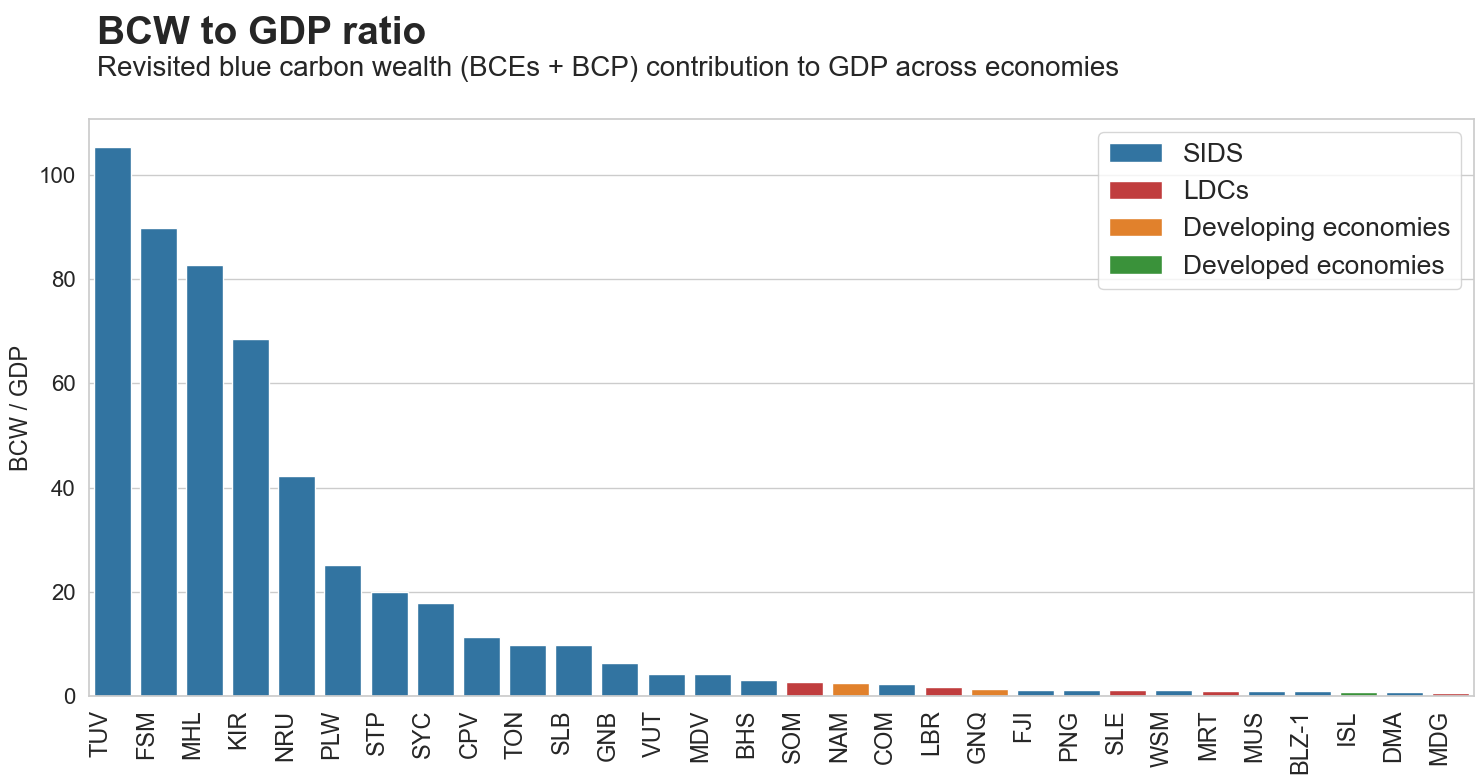

In [ ]:
by_bg = df[['ISO', 'Groups', 'Total BCW', 'GDP']]
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW'] / by_bg['GDP']
by_bg['Total BCW to GDP ratio'] = by_bg['Total BCW to GDP ratio'].replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
by_bg = by_bg.sort_values(by='Total BCW to GDP ratio', ascending=False).head(30)
palette = by_bg['Groups'].map(color_mapping)

fig, ax = plt.subplots(figsize=(15, 8))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg, x='ISO', y='Total BCW to GDP ratio', palette= color_mapping, hue='Groups',ax=ax)
fig.text(0.07, 0.97, 'BCW to GDP ratio', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.07, 0.92, 'Revisited blue carbon wealth (BCEs + BCP) contribution to GDP across economies', 
         fontsize=20, va='top', ha='left')
plt.title('d', color='white', pad=70)
plt.ylabel('BCW / GDP', fontsize=17)
# plt.yscale("log")
# format_log_axis_plain('y')
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xticks(rotation=90, ha='right', fontsize=17)
plt.tight_layout()
plt.legend(fontsize=19)
plt.show()

In [ ]:
by_bg.groupby('Groups')['Total BCW to GDP ratio'].mean()

Groups
Developed economies     0.8063
Developing economies    1.9272
LDCs                    1.5137
SIDS                   23.1654
Name: Total BCW to GDP ratio, dtype: float64

### EEZ per Capita

In [ ]:
by_eez = df[['country_name','ISO', 'Groups', 'Area_EEZ_KM2', 'Population']]
by_eez['Area_EEZ_KM2_per_capita'] = by_eez['Area_EEZ_KM2'] / by_eez['Population']
by_eez_sorted = by_eez.sort_values(by='Area_EEZ_KM2_per_capita', ascending=False)
top_30_eez = by_eez_sorted.head(30)

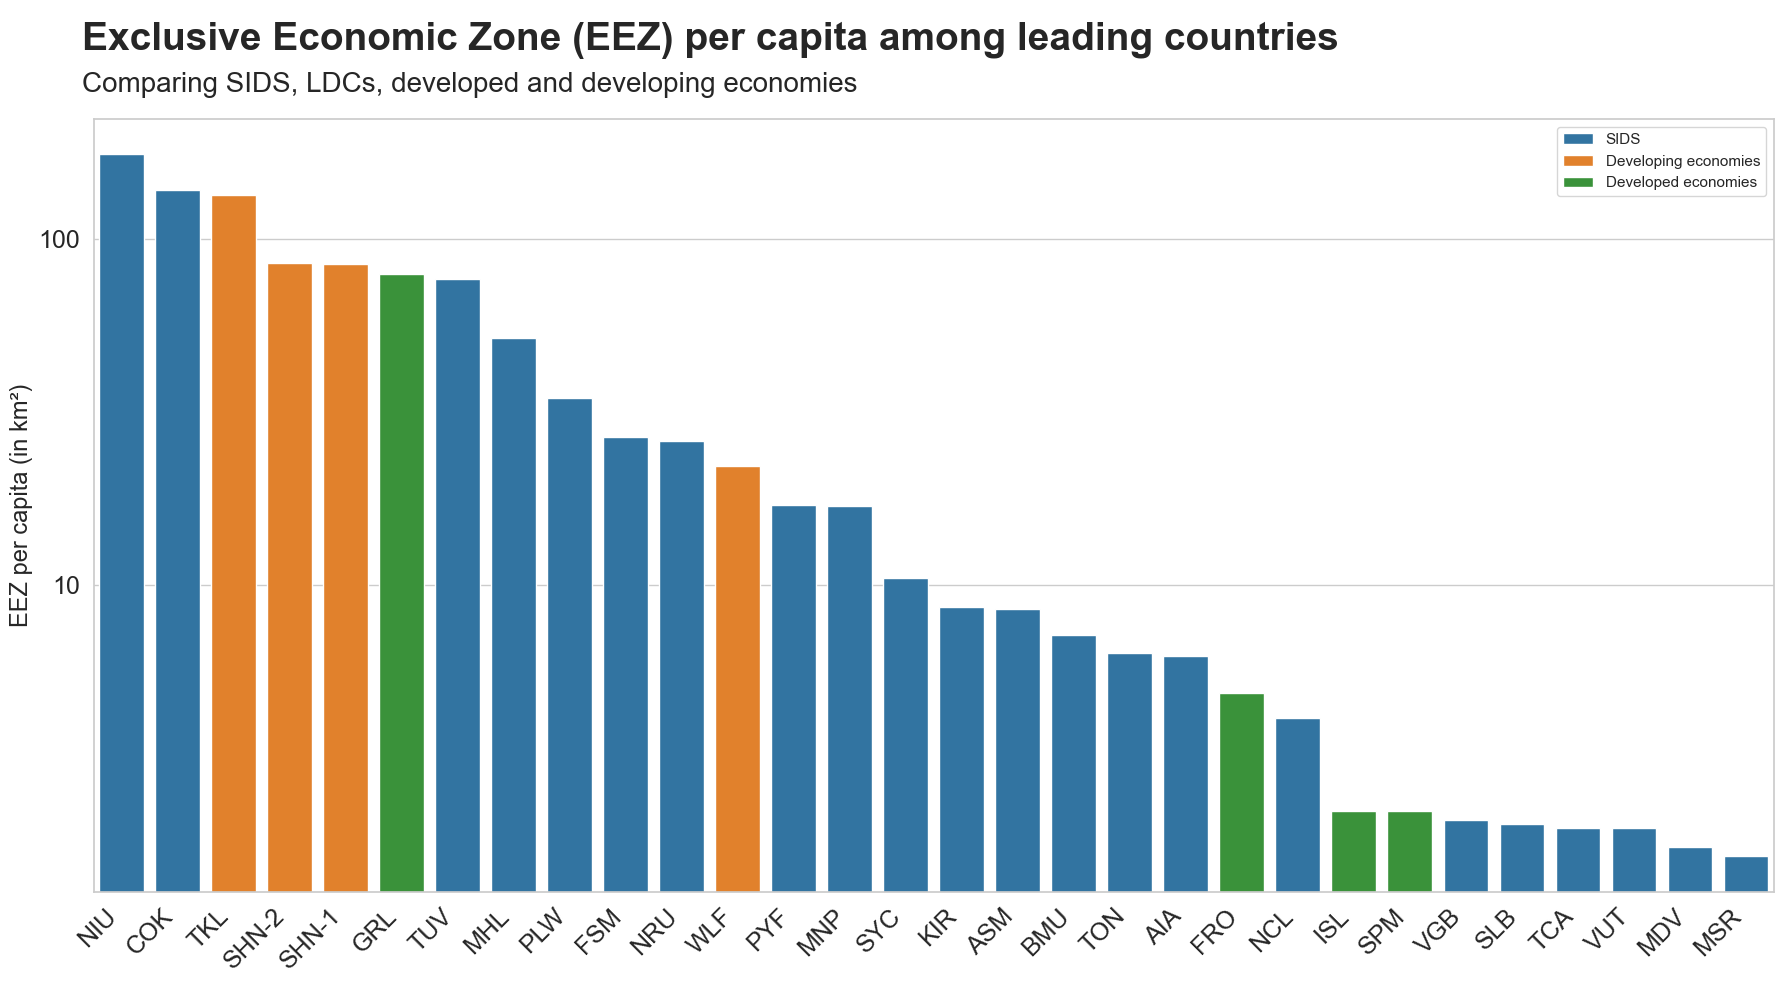

In [ ]:
fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(top_30_eez, x='ISO', y='Area_EEZ_KM2_per_capita', palette= 'tab10', ci=False, hue='Groups',ax=ax)
fig.text(0.05, 0.97, 'Exclusive Economic Zone (EEZ) per capita among leading countries', 
         fontsize=28, fontweight='bold', va='top', ha='left')
fig.text(0.05, 0.92, 'Comparing SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')

# fig.text(0.045, 0, 'Note: The suffixes added to ISO codes, such as SHN-1, SHN-2, SHN-3 for Saint Helena, Ascension, and Tristan Da Cunha, and KIR-1 for the Gilbert Islands, KIR-2 for the Phoenix Islands, and KIR-3 for the Line Islands of Kiribati, are used to differentiate these territories under the same ISO designation.', 
#          fontsize=18, va='top', ha='left', wrap=True)

plt.title('d', color='white', pad=70)
plt.ylabel('EEZ per capita (in km²)', fontsize=17)
plt.xlabel('')
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.legend()
plt.show()

## Choropleth Maps — BCW per Capita

World maps showing per-capita blue carbon wealth by country.

### Coastal BCW per Capita

In [ ]:
plot_data['cBCW_per_capita'] = plot_data['cBCW'] / plot_data['Population']
plot_data['oBCW_per_capita'] = plot_data['oBCW'] / plot_data['Population']

by_country = plot_data[['ISO', 'cBCW_per_capita', 'Groups']]
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)

In [ ]:
by_country['cat'] = by_country['cBCW_per_capita'].apply(categorize_bcw_pcap)


In [ ]:
color_map = {
    'No data available': '#d3d3d3',
    '0 - 5 US$': '#FFFF00',
    '5 - 50 US$': '#98FB98',
    '50 - 500 US$': '#006400',
    '> 500 US$': '#FF6347'
}

country_data = wld.set_index('ISO_A3').join(by_country.set_index('ISO'))
country_data = country_data[['NAME', 'CONTINENT', 'geometry', 'cBCW_per_capita', 'cat']]
country_data = country_data.reset_index()
country_data = country_data.rename(columns={'ISO_A3': 'ISO'})
country_data['cat'] = country_data['cat'].fillna('No data available')

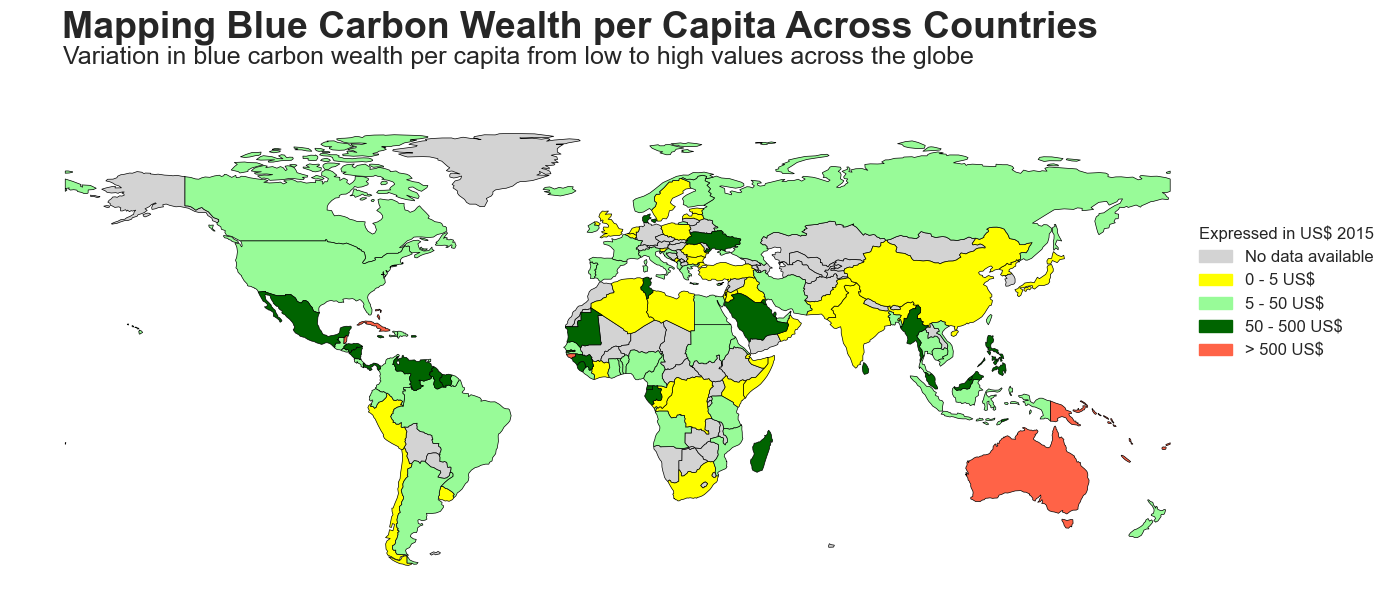

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 10))
legend_patches = []
for cat, color in color_map.items():
    subset = country_data[country_data['cat'] == cat]
    subset.plot(ax=ax, color=color, label=cat, edgecolor='black', linewidth=0.5)
    legend_patches.append(Patch(color=color, label=cat))

fig.text(0.05, 0.83, 'Mapping Blue Carbon Wealth per Capita Across Countries', 
         fontsize=27, fontweight='bold', va='top', ha='left')
fig.text(0.051, 0.794, 'Variation in blue carbon wealth per capita from low to high values across the globe', 
         fontsize=18, va='top', ha='left')

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 0.45),
           loc='lower center', ncol=1, fontsize=12, 
           title='Expressed in US$ 2015',
        title_fontsize=12, frameon=False)

ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Coastal BCW per Capita (map + bar chart)

In [ ]:
# print(sns.color_palette("ch:start=.2,rot=-.3", n_colors=4)[::-1])
hex_col = ['#27203f', '#51618f', '#7da6c0', '#c2e2e2']
list_col = hex_col[::-1]
print(list_col)

['#c2e2e2', '#7da6c0', '#51618f', '#27203f']


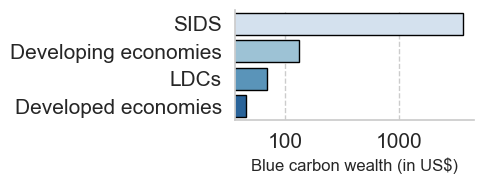

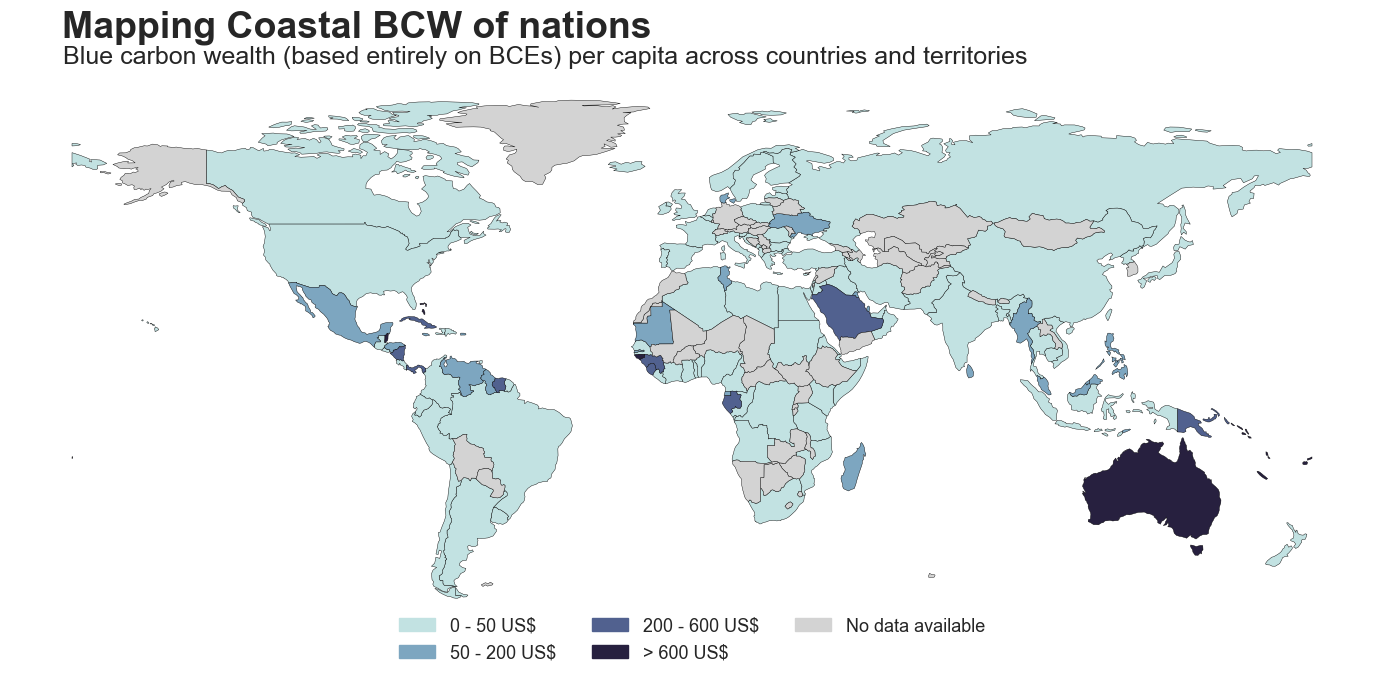

In [ ]:
map_and_barplot(df=plot_data,
                var='cBCW_per_capita',
                group_col='Groups',
                thresholds=[50, 200, 600],
                labels=['0 - 50 US$', '50 - 200 US$', '200 - 600 US$', '> 600 US$'],
                colors=list_col,
                title='Mapping Coastal BCW of nations',
                subtitle='Blue carbon wealth (based entirely on BCEs) per capita across countries and territories',
                xlabel_bar='Blue carbon wealth (in US$)',
                fig_size_map=(14, 10),
                fig_size_bar=(5, 2),
                cmap_palette='Blues')

# oBCW
# map_and_barplot(df=plot_data,
#                 var='oBCW',
#                 group_col='Groups',
#                 thresholds=[10e9, 50e9, 10e10],
#                 labels=['0 - 3B US$', '3 - 5B US$', '5 - 20B US$', '> 20B US$'],
#                 colors=["#fdf0d5", "#ffb703", "#ca6702", "#B24100"],
#                 title='Mapping oBCW of nations and territories',
#                 subtitle='Distribution of Biological Carbon Pump Wealth (oBCW) across countries and territories',
#                 xlabel_bar='Biological carbon pump wealth (in US$)',
#                 fig_size_map=(14, 10),
#                 fig_size_bar=(5, 2),
#                 cmap_palette='Blues')

### BCP Wealth per Capita

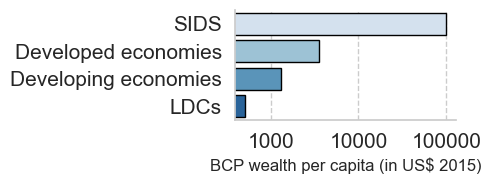

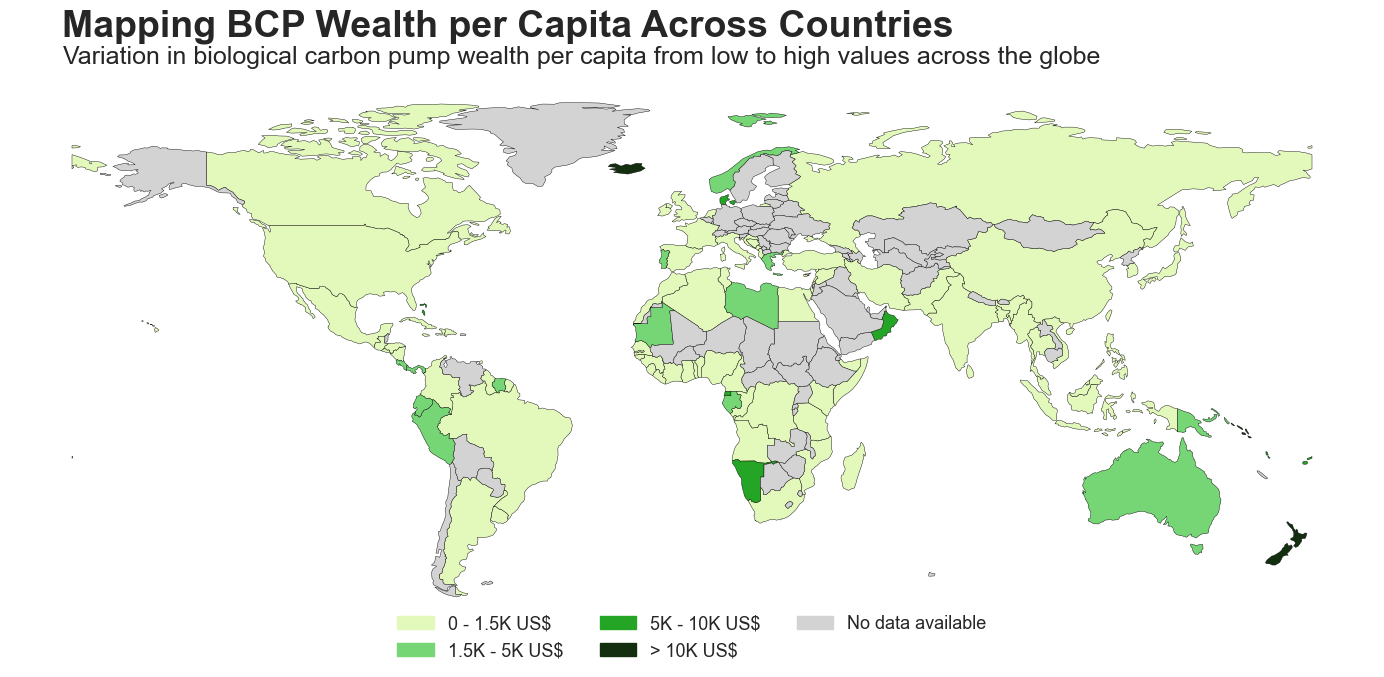

In [ ]:
map_and_barplot(df=data,
                var='oBCW_per_capita',
                group_col='Groups',
                thresholds=[15e2, 5e3, 1e4],
                labels=['0 - 1.5K US$', '1.5K - 5K US$', '5K - 10K US$', '> 10K US$'],
                colors=["#E3F9BC", "#76D676", "#25A525", "#132F10"],
                title='Mapping BCP Wealth per Capita Across Countries',
                subtitle='Variation in biological carbon pump wealth per capita from low to high values across the globe',
                xlabel_bar='BCP wealth per capita (in US$ 2015)',
                fig_size_map=(14, 10),
                fig_size_bar=(5, 2),
                cmap_palette='Blues')

### Total BCW per Capita

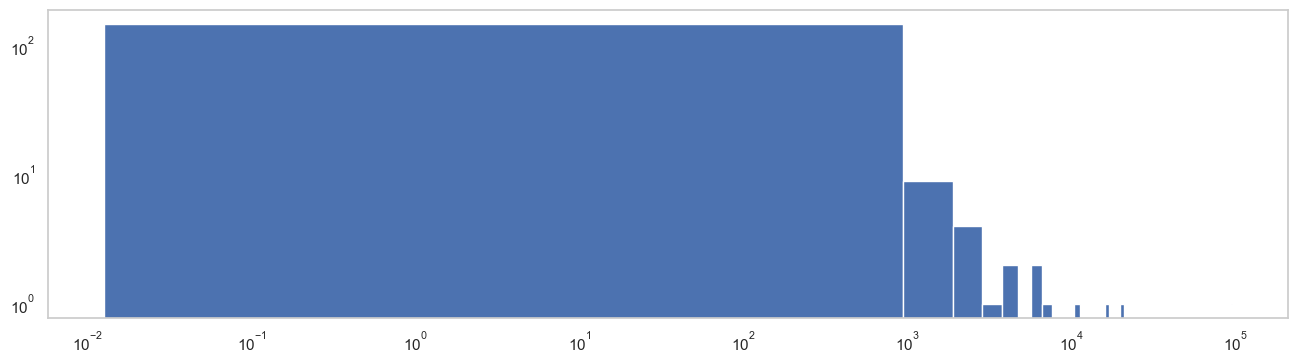

In [ ]:
data['cBCW_per_capita'].hist(bins=100, log=True, figsize=(16, 4))
plt.xscale("log")
plt.grid(False)
plt.show()

In [ ]:
colors_rgb = sns.color_palette('ch:start=.2,rot=-.3', n_colors=5)[::-1]
hex_colors = [rgb_to_hex(c) for c in colors_rgb]
hex_colors = hex_colors[::-1]


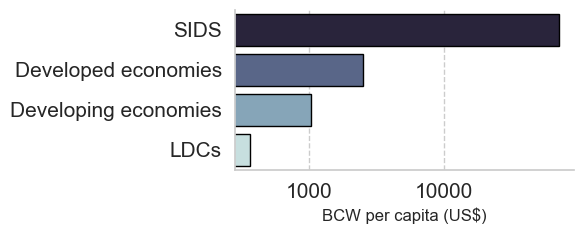

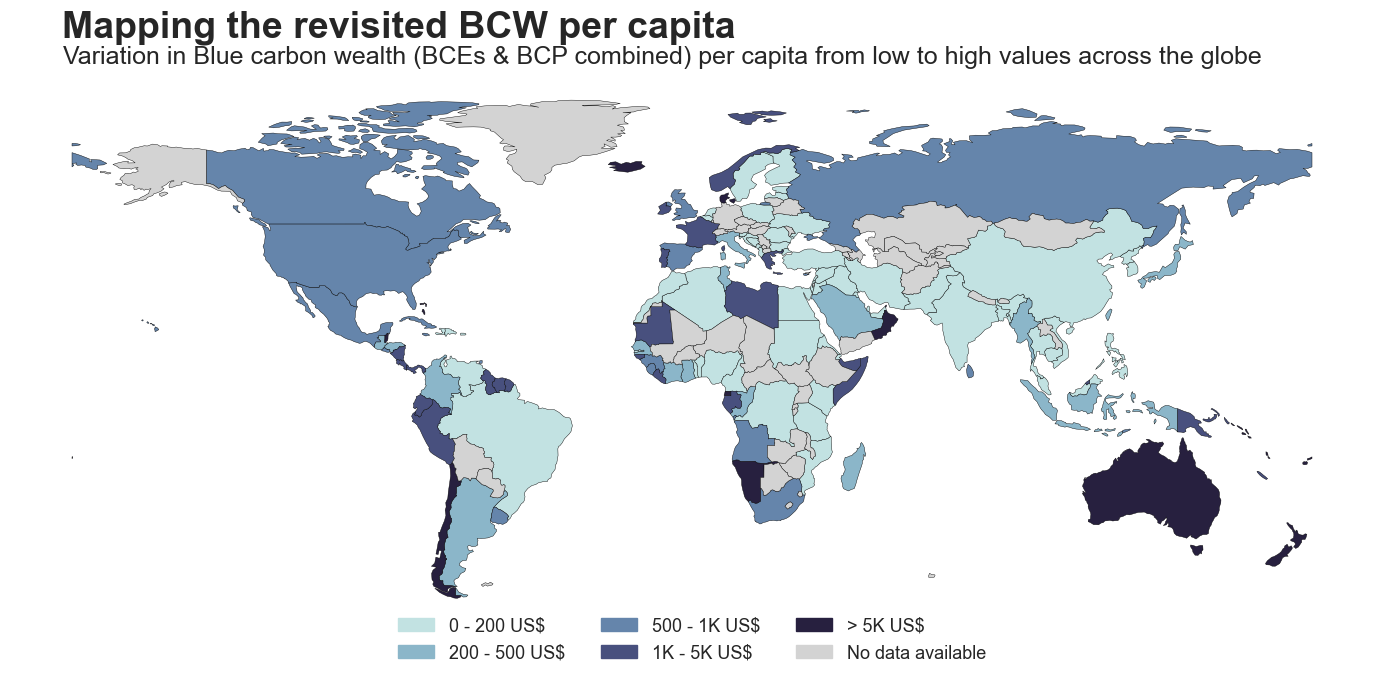

In [ ]:
colors_list = sns.color_palette("ch:start=.2,rot=-.3", n_colors=4)[::-1]
# map_and_barplot(df=plot_data,
#                 var='Total BCW_per_capita',
#                 group_col='Groups',
#                 thresholds=[2e2, 5e2, 1e3, 5e3, 1e4],
#                 labels=['0 - 200 US$', '200 - 500 US$', '500 - 1K US$', '1K - 5K US$', '> 5K US$'],
#                 colors=["#fdf0d5", "#ffb703", "#ca6702", "#a53860", "#38040e"],
#                 title='Mapping the revisited BCW per capita',
#                 subtitle='Variation in Blue carbon wealth (BCEs & BCP combined) per capita from low to high values across the globe',
#                 xlabel_bar='BCW per capita (US$)',
#                 fig_size_map=(14, 10),
#                 fig_size_bar=(6, 2.5),
#                 cmap_palette=colors_list)

map_and_barplot(df=plot_data,
                var='Total BCW_per_capita',
                group_col='Groups',
                thresholds=[2e2, 5e2, 1e3, 5e3, 1e4],
                labels=['0 - 200 US$', '200 - 500 US$', '500 - 1K US$', '1K - 5K US$', '> 5K US$'],
                colors=hex_colors,
                title='Mapping the revisited BCW per capita',
                subtitle='Variation in Blue carbon wealth (BCEs & BCP combined) per capita from low to high values across the globe',
                xlabel_bar='BCW per capita (US$)',
                fig_size_map=(14, 10),
                fig_size_bar=(6, 2.5),
                cmap_palette=colors_list)

## Continental and Group Analysis

Aggregate BCW per capita by continent and economic group. Wind rose charts for top countries per continent.

### By Continent

In [ ]:
continent = df.groupby('Continent')[['cBCW', 'oBCW', 'Total BCW', 'Population']].sum().reset_index()
continent['cBCW_per_capita'] = continent['cBCW'] / continent['Population']
continent['oBCW_per_capita'] = continent['oBCW'] / continent['Population']
continent['Total BCW_per_capita'] = continent['Total BCW'] / continent['Population']
# continent.rename(columns={
#     'oBCW': 'PCW', 'oBCW_per_capita': 'PCW_PCAP'
#     }).to_csv('continent_summary.csv', index=False, float_format='%.6f')
continent.head()

,Continent,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Africa,"44,418,540,097.8378","331,418,202,456.8002","375,836,742,554.6380","1,465,946,459.0000",30.3002,226.0780,256.3782
1,Americas,"35,499,708,767.1814","691,365,028,241.0952","726,864,737,008.2766","1,017,200,349.0000",34.8994,679.6744,714.5738
2,Asia,"58,007,978,919.3643","323,037,668,443.8782","381,045,647,363.2424","4,809,238,643.0000",12.0618,67.1702,79.2320
3,Caribbean,"47,215,138,664.6042","12,789,226,745.1626","60,004,365,409.7667","44,309,064.0000","1,065.5865",288.6368,"1,354.2233"
4,Europe,"11,213,497,108.3893","409,310,658,816.7332","420,524,155,925.1224","828,450,578.0000",13.5355,494.0677,507.6032


In [ ]:
pal = CONTINENT_PAL


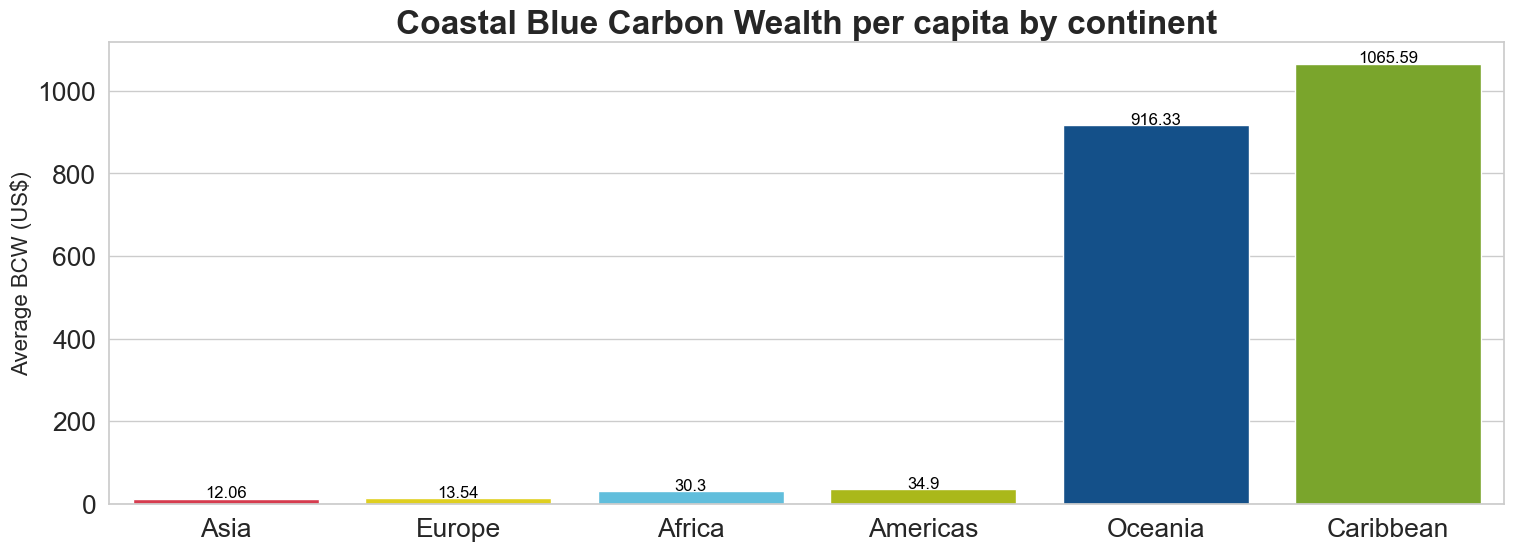

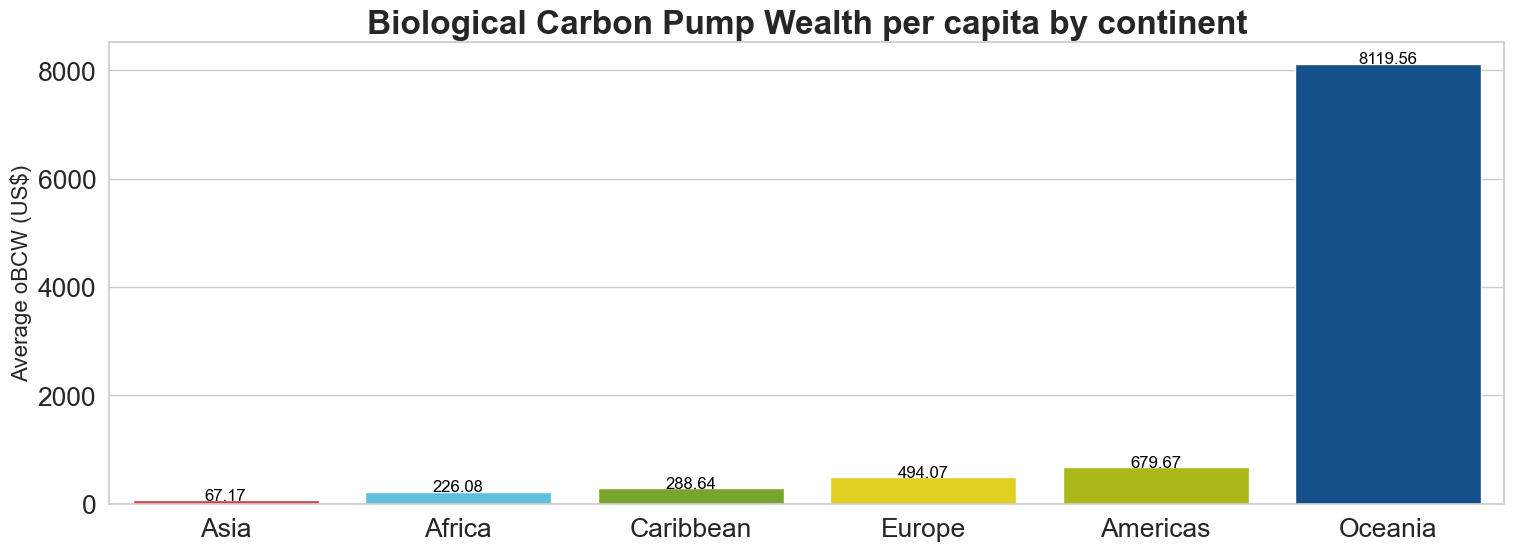

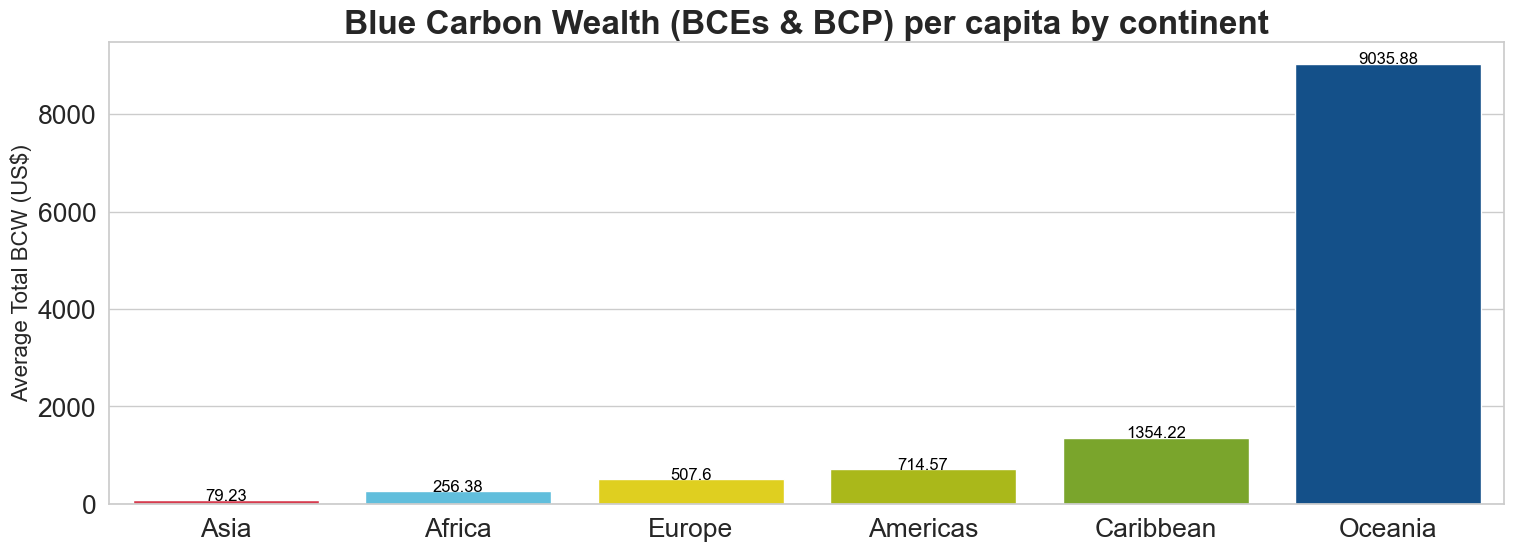

In [ ]:
varlist = ['cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']
titles = ['Coastal Blue Carbon Wealth per capita by continent',
          'Biological Carbon Pump Wealth per capita by continent',
          'Blue Carbon Wealth (BCEs & BCP) per capita by continent']
ylabels = ['Average BCW (US$)',
           'Average oBCW (US$)',
              'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    cdf = continent.copy()
    cdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(18, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(cdf, x='Continent', y=var, ci=False, palette=pal)
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.xlabel('')
    for i, v in enumerate(cdf[var]):
        plt.text(
            i, v + 3, str(round(v, 2)), 
            color='black', ha='center'
        )
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.ylabel(ylabel, fontsize=16)
    plt.show()

In [ ]:
cont = continent.copy()
varlits = ['cBCW', 'oBCW', 'Total BCW']
varlist = ['cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']
for var, tot in zip(varlist, varlits):
    tota = cont[tot].sum()
    cont[f'prop_{tot}'] = round((cont[tot]/tota) * 100, 2).astype(str) + '%'
    cont[f'prop_{tot}'] = cont[f'prop_{tot}'].astype(str)
    cont['Continent'] =cont['Continent'].astype('object')
    cont[f'Estimated_{var}'] = cont['Continent'] + ' (' + cont[var].round(2).astype(str) + ' US$ on avg.)'
cont = cont.drop(columns=varlist + varlits)
cont

,Continent,Population,prop_cBCW,Estimated_cBCW_per_capita,prop_oBCW,Estimated_oBCW_per_capita,prop_Total BCW,Estimated_Total BCW_per_capita
0,Africa,"1,465,946,459.0000",18.64%,Africa (30.3 US$ on avg.),15.49%,Africa (226.08 US$ on avg.),15.8%,Africa (256.38 US$ on avg.)
1,Americas,"1,017,200,349.0000",14.89%,Americas (34.9 US$ on avg.),32.31%,Americas (679.67 US$ on avg.),30.56%,Americas (714.57 US$ on avg.)
2,Asia,"4,809,238,643.0000",24.34%,Asia (12.06 US$ on avg.),15.1%,Asia (67.17 US$ on avg.),16.02%,Asia (79.23 US$ on avg.)
3,Caribbean,"44,309,064.0000",19.81%,Caribbean (1065.59 US$ on avg.),0.6%,Caribbean (288.64 US$ on avg.),2.52%,Caribbean (1354.22 US$ on avg.)
4,Europe,"828,450,578.0000",4.7%,Europe (13.54 US$ on avg.),19.13%,Europe (494.07 US$ on avg.),17.68%,Europe (507.6 US$ on avg.)
5,Oceania,"45,827,843.0000",17.62%,Oceania (916.33 US$ on avg.),17.39%,Oceania (8119.56 US$ on avg.),17.41%,Oceania (9035.88 US$ on avg.)


In [ ]:
country_data = df[['ISO', 'country_name', 'Continent', 'cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']].copy()
country_data.head()

,ISO,country_name,Continent,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,AE,"Abu musa, Greater and Lesser Tunb",Asia,NaN,NaN,NaN
1,AFG,Afghanistan,Asia,NaN,NaN,NaN
2,US-AK,Alaska,Americas,NaN,NaN,NaN
3,ALB,Albania,Europe,13.1251,58.2919,71.4170
4,DZA,Algeria,Africa,0.4072,136.7252,137.1324


### By Economic Group

In [ ]:
groups = df.groupby('Groups')[['cBCW', 'oBCW', 'Total BCW', 'Population']].sum().reset_index()
groups['cBCW_per_capita'] = groups['cBCW'] / groups['Population']
groups['oBCW_per_capita'] = groups['oBCW'] / groups['Population']
groups['Total BCW_per_capita'] = groups['Total BCW'] / groups['Population']
groups['Groups'] = groups['Groups'].replace({'Developed economies': 'Developed', 'Developing economies': 'Developing'})
groups.head()

,Groups,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Developed,"46,936,681,004.8789","857,025,114,050.5247","903,961,795,055.4036","1,429,633,557.0000",32.8313,599.4719,632.3031
1,Developing,"84,313,338,247.6777","849,233,915,750.6542","933,547,253,998.3318","5,538,886,372.0000",15.2221,153.3221,168.5442
2,LDCs,"30,245,113,282.8801","110,075,794,888.8379","140,320,908,171.7180","1,169,293,241.0000",25.8661,94.1387,120.0049
3,SIDS,"73,972,207,948.5723","307,860,044,064.8064","381,832,252,013.3786","73,159,766.0000","1,011.1050","4,208.0512","5,219.1563"


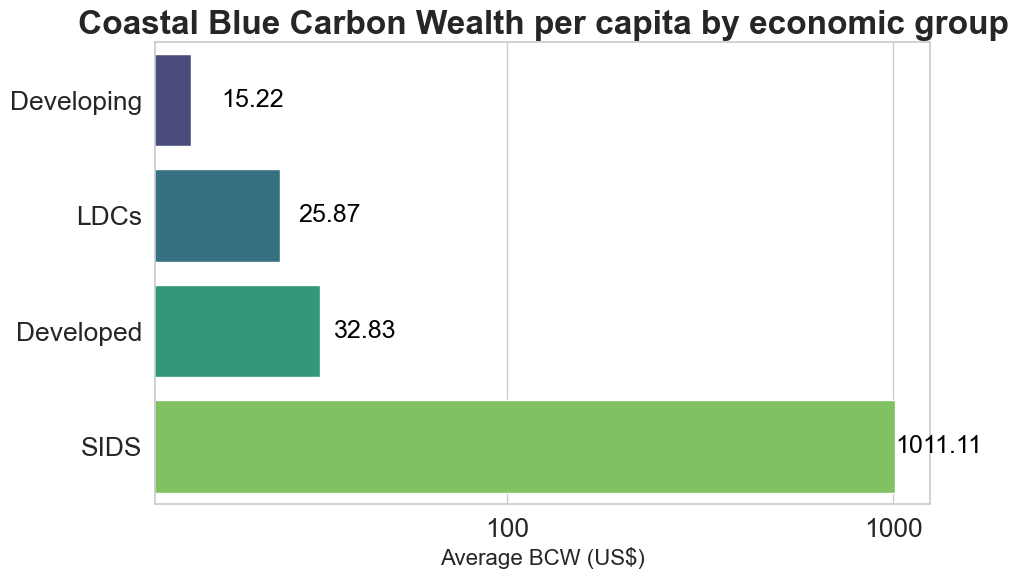

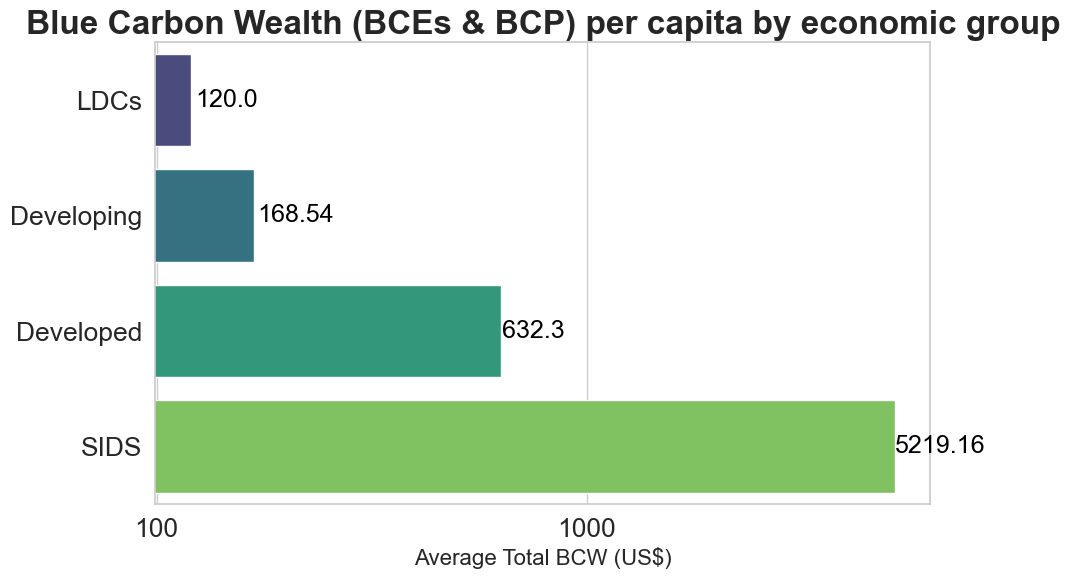

In [ ]:
# horizontal barplot for groups
varlist = ['cBCW_per_capita', 'Total BCW_per_capita']
titles = ['Coastal Blue Carbon Wealth per capita by economic group',
          'Blue Carbon Wealth (BCEs & BCP) per capita by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, str(round(v, 2)), 
            color='black', va='center', fontsize=18
        )
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

In [ ]:
groups = df.groupby('Groups')[['cBCW', 'oBCW', 'Total BCW', 'Population']].mean().reset_index()
groups['cBCW_per_capita'] = groups['cBCW'] / groups['Population']
groups['oBCW_per_capita'] = groups['oBCW'] / groups['Population']
groups['Total BCW_per_capita'] = groups['Total BCW'] / groups['Population']
groups['Groups'] = groups['Groups'].replace({'Developed economies': 'Developed', 'Developing economies': 'Developing'})
groups.head()

,Groups,cBCW,oBCW,Total BCW,Population,cBCW_per_capita,oBCW_per_capita,Total BCW_per_capita
0,Developed,"1,235,175,815.9179","31,741,670,890.7602","22,599,044,876.3851","24,231,077.2373",50.9749,"1,309.9571",932.6471
1,Developing,"1,429,039,631.3166","18,871,864,794.4590","14,818,210,380.9259","66,733,570.7470",21.4141,282.7942,222.0503
2,LDCs,"1,374,777,876.4945","6,879,737,180.5524","6,378,223,098.7145","31,602,520.0270",43.5022,217.6958,201.8264
3,SIDS,"1,344,949,235.4286","7,893,847,283.7130","6,583,314,689.8858","1,283,504.6667","1,047.8725","6,150.2287","5,129.1708"


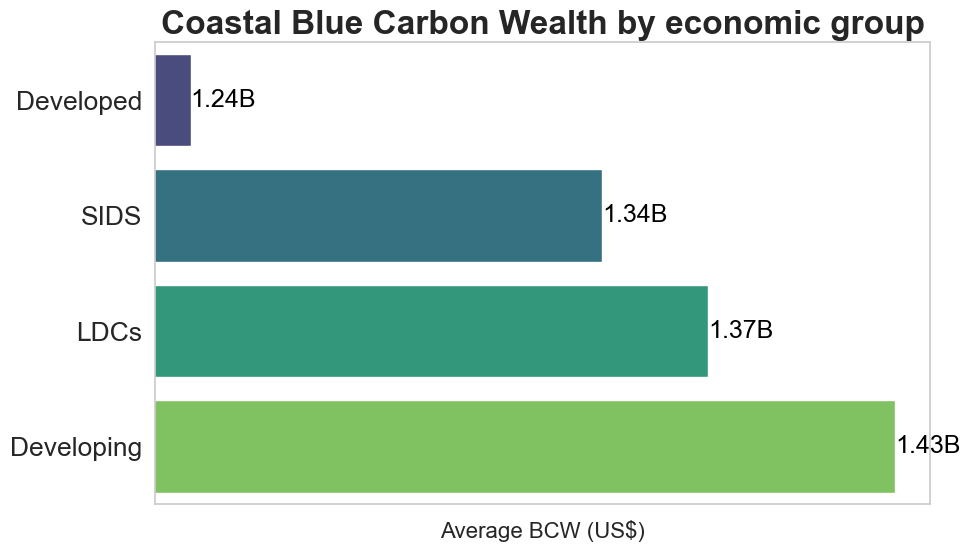

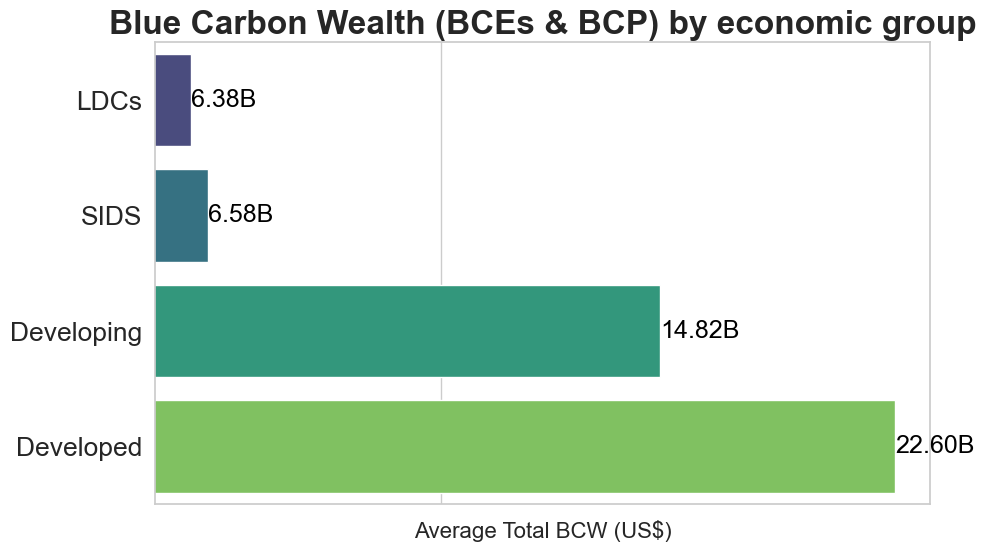

In [ ]:
# horizontal barplot for groups
varlist = ['cBCW', 'Total BCW']
titles = ['Coastal Blue Carbon Wealth by economic group',
          'Blue Carbon Wealth (BCEs & BCP) by economic group']
ylabels = ['Average BCW (US$)',
           'Average Total BCW (US$)']
for var, title, ylabel in zip(varlist, titles, ylabels):
    gdf = groups.copy()
    gdf.sort_values(by=var, inplace=True)
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.barplot(gdf, y='Groups', x=var, ci=False, palette='viridis')
    plt.title(title, fontweight='bold',
            fontsize=24)
    plt.ylabel('')
    for i, v in enumerate(gdf[var]):
        plt.text(
            v + 3, i, f'{v/1e9:.2f}B', 
            color='black', va='center', fontsize=18
        )
    plt.xticks(visible=False)
    plt.xscale("log")
    format_log_axis_plain('x')
    plt.tick_params(axis='both', which='major', labelsize=19)
    plt.xlabel(ylabel, fontsize=16)
    plt.show()

### Wind Rose Charts

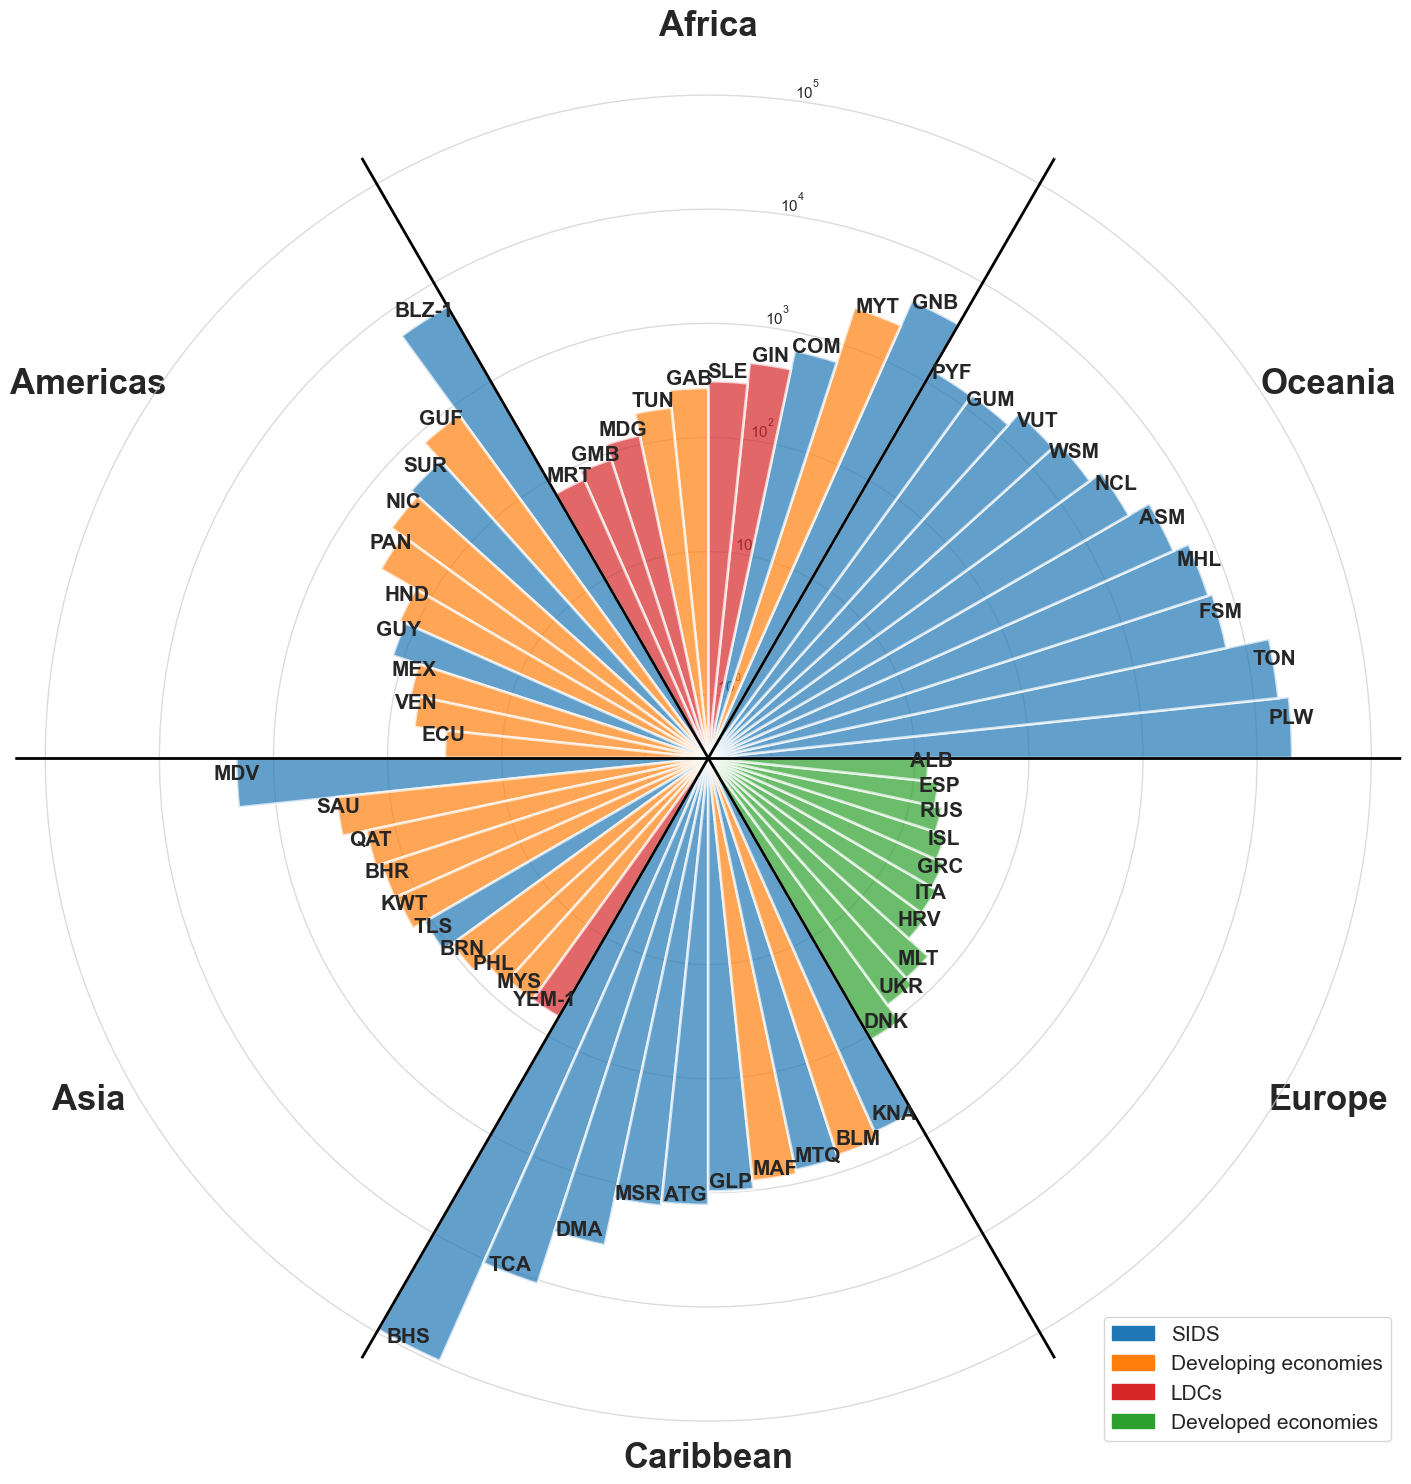

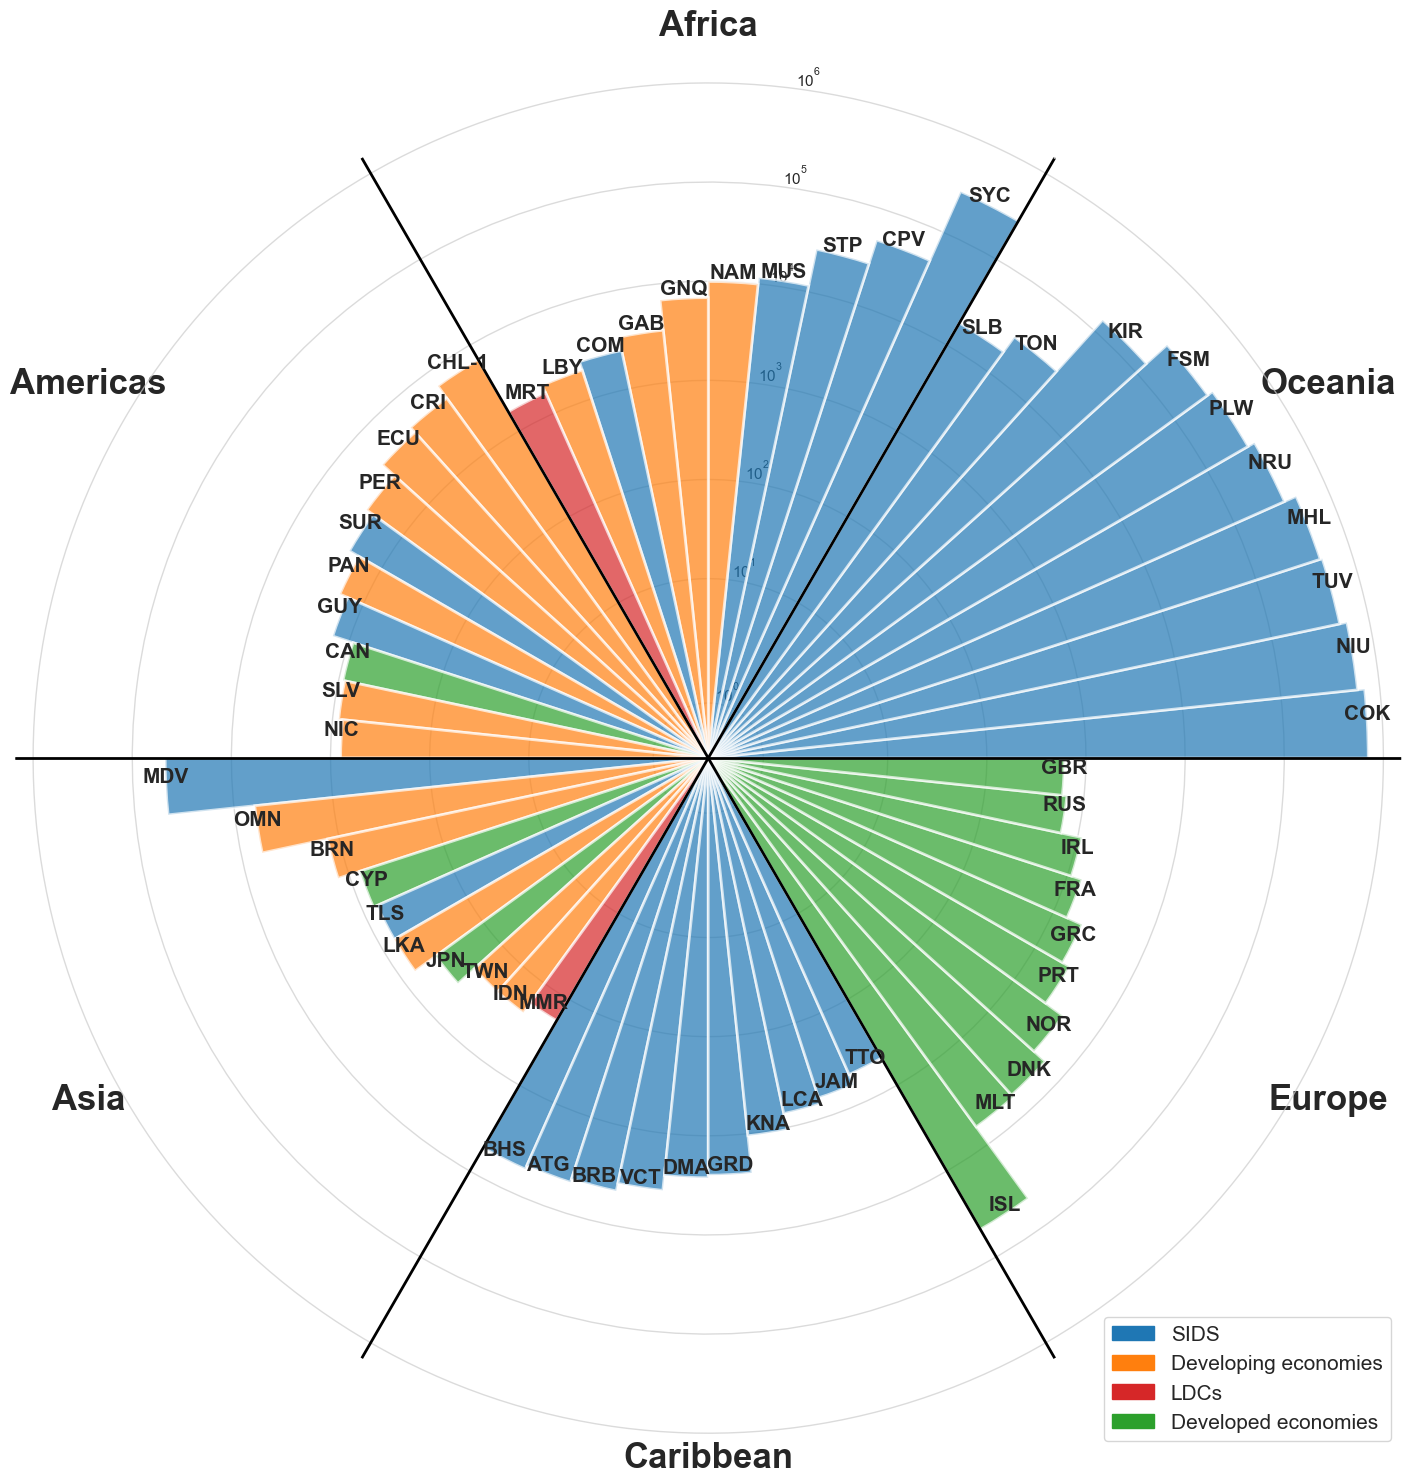

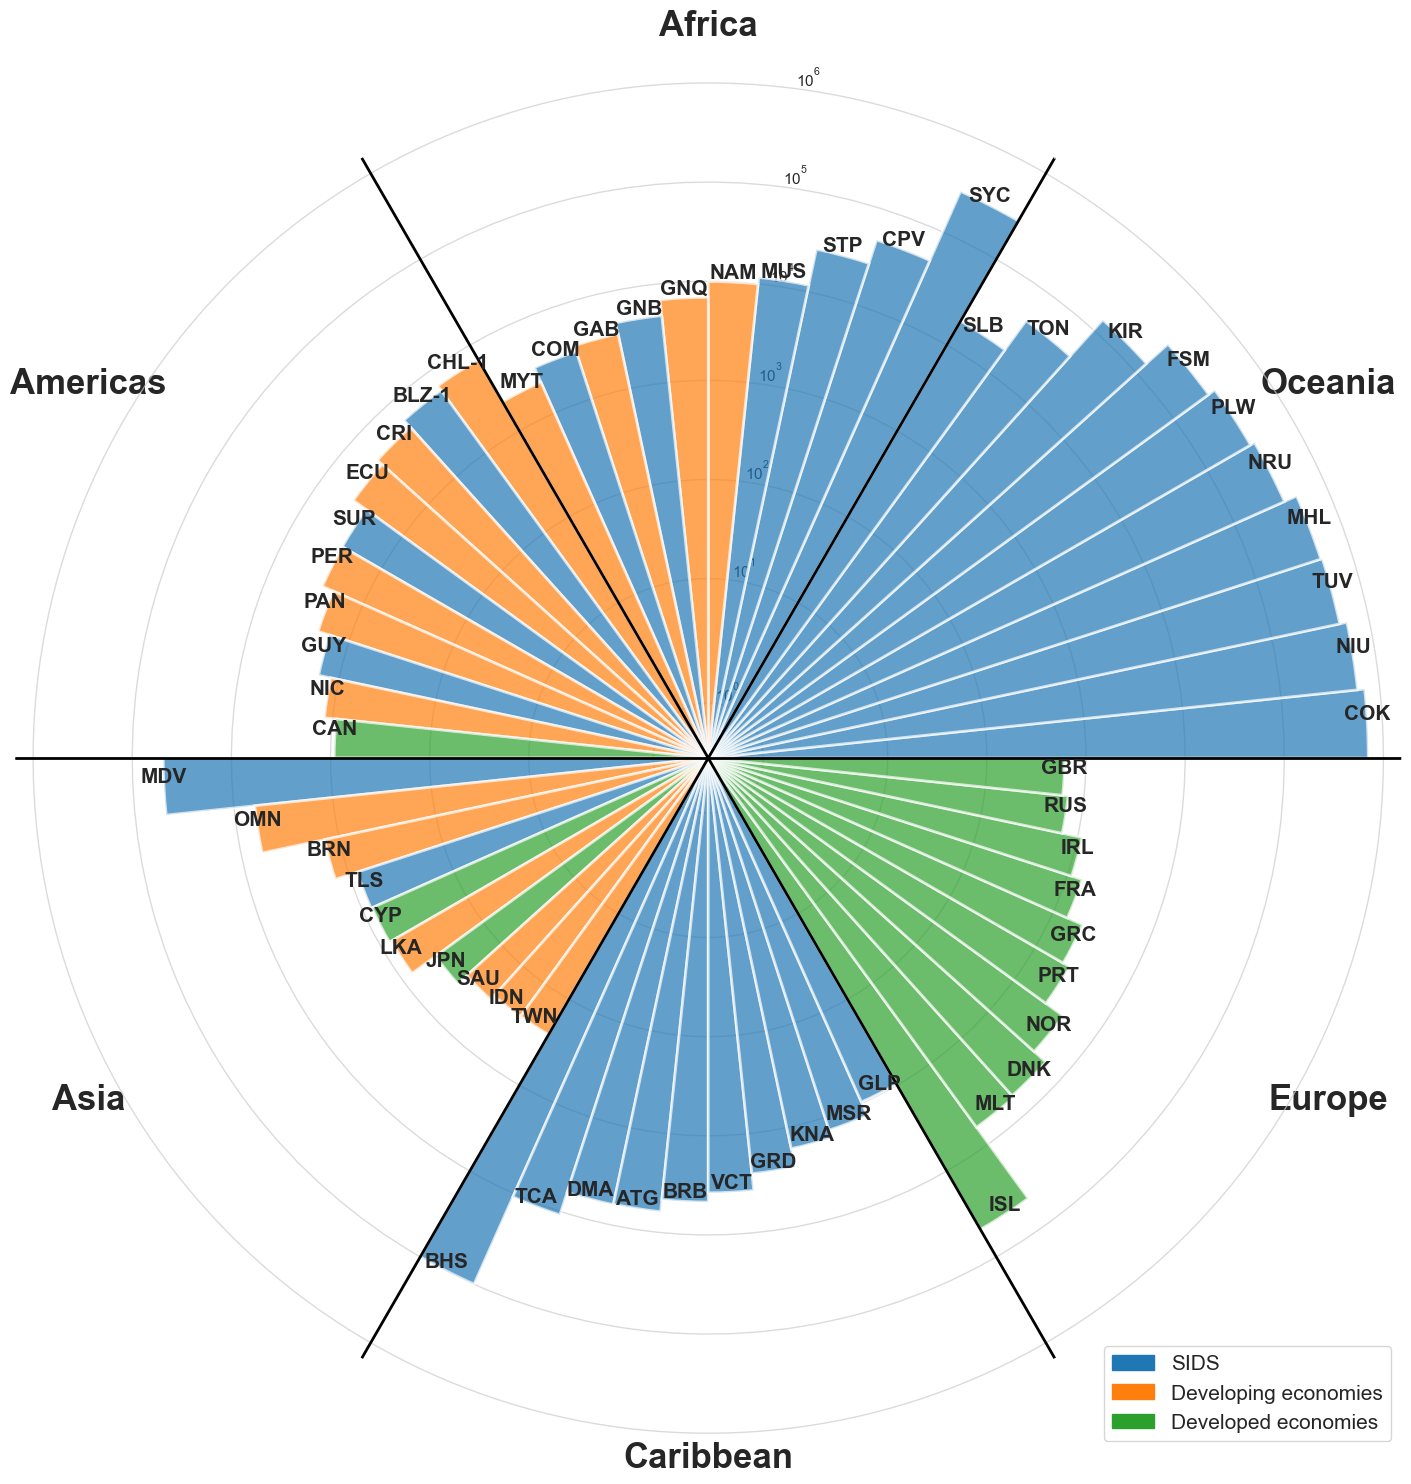

In [ ]:
pf = df[['Continent', 'ISO', 'Groups', 'cBCW_per_capita', 'oBCW_per_capita', 'Total BCW_per_capita']].copy()

# Top 10 countries for each Continent by cBCW_per_capita, oBCW_per_capita and Total BCW_per_capita
top_10_bcw = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'cBCW_per_capita')).reset_index(drop=True)
top_10_bcw.drop(columns=['oBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_oBCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'oBCW_per_capita')).reset_index(drop=True)
top_10_oBCW.drop(columns=['cBCW_per_capita', 'Total BCW_per_capita'], inplace=True)
top_10_Total_BCW = pf.groupby('Continent').apply(lambda x: x.nlargest(10, 'Total BCW_per_capita')).reset_index(drop=True)
top_10_Total_BCW.drop(columns=['cBCW_per_capita', 'oBCW_per_capita'], inplace=True)

datasets = [top_10_bcw, top_10_oBCW, top_10_Total_BCW]

category_colors = {
    'SIDS': '#1f77b4',       # Bleu
    'Developing economies': '#ff7f0e',  # Orange
    'Developed economies': '#2ca02c',    # Vert
    'LDCs': '#d62728'         # Rouge
}
for dta in datasets:
    if 'cBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'cBCW_per_capita'
        category_col = 'Groups'
    elif 'oBCW_per_capita' in dta.columns:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'oBCW_per_capita'
        category_col = 'Groups'
    else:
        segment_col = 'Continent'
        label_col = 'ISO'
        value_col = 'Total BCW_per_capita'
        category_col = 'Groups'

    wind_rose(dta, segment_col=segment_col, label_col=label_col, value_col=value_col,
              category_col=category_col, n_top=10, figsize=(18, 18), category_colors=category_colors)

## Joint Regimes and Overlapping Claims

Estimate BCW for maritime areas under joint management or contested jurisdiction.

### Data Preparation

In [ ]:
dta = pd.read_csv(SUMMARY_DIR / 'bce_data.csv')
dta = dta.rename(columns={'country_name': 'entity', 'ISO_TER1': 'ISO'})
dta = dta[['entity', 'ISO', 'Area_EEZ_KM2', 'Continent']]
otj = dta[dta['entity'].str.contains('Joint regime|Overlapping', na=False)]
otj = otj.sort_values(by='entity').reset_index(drop=True)

for _, row in otj.iterrows():
    if 'Joint regime' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'JR-{row.name + 1}'
    elif 'Overlapping claim' in row['entity']:
        otj.loc[row.name, 'ISO'] = f'OC-{row.name - 20}'
otj
# 21 Joint regimes and 11 Overlapping claims
# Only one with data on Seq: Joint regime area Torres Strait Treaty: Papua New Guinea and Australia


In [ ]:
full = pd.read_csv(DATA_DIR / 'shp' / 'EEZ_full.csv')
full = full[['UNION', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3']]

otj_full = otj.merge(full, left_on='entity', right_on='UNION', how='left').drop(columns=['UNION'])

country_Total_BCW = df[['ISO', 'Total BCW_per_capita']].copy()
country_Total_BCW_unique = country_Total_BCW.drop_duplicates(subset='ISO')
otj_full['Total BCWpcap_1'] = otj_full['ISO_TER1'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_2'] = otj_full['ISO_TER2'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])
otj_full['Total BCWpcap_3'] = otj_full['ISO_TER3'].map(country_Total_BCW_unique.set_index('ISO')['Total BCW_per_capita'])

otj_full['Total BCW_InvolvedStates'] = otj_full[['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3']].mean(axis=1).replace(0, np.nan)
otj_full.drop(columns=['Total BCWpcap_1', 'Total BCWpcap_2', 'Total BCWpcap_3', 'ISO_TER1', 'ISO_TER2', 'ISO_TER3'], inplace=True)


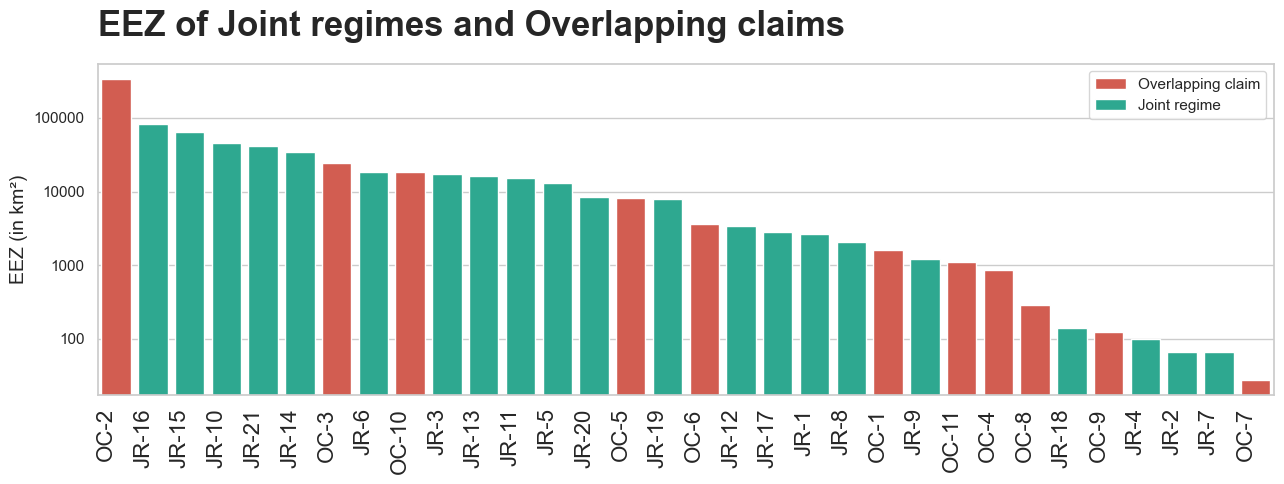

In [ ]:
plt.figure(figsize=(13, 5))
palette = {
    'Joint regime': '#1ABC9C',   # turquoise
    'Overlapping claim': '#E74C3C'  # corail chaud
}
otj_full['entity_type'] = otj_full['entity'].apply(lambda x: 'Joint regime' if 'Joint regime' in x else 'Overlapping claim')
sns.barplot(data=otj_full.sort_values(by='Area_EEZ_KM2', ascending=False), x='ISO', 
            y='Area_EEZ_KM2', hue='entity_type', palette=palette)

plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=16)
plt.ylabel('EEZ (in km²)', fontsize=14)
plt.yscale('log')
format_log_axis_plain('y')

plt.title('EEZ of Joint regimes and Overlapping claims', 
          fontsize=25, fontweight='bold', pad=20, loc='left')

plt.legend()
plt.tight_layout()
plt.show()

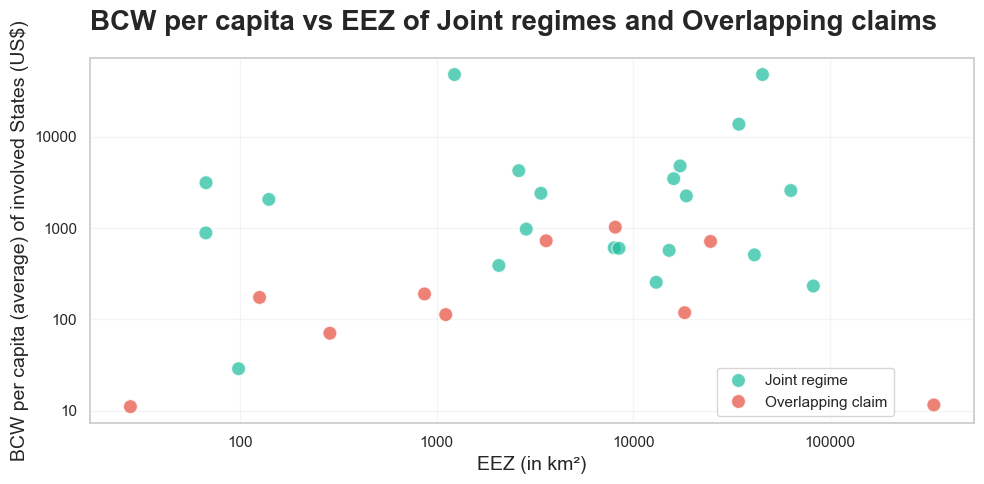

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=otj_full, x='Area_EEZ_KM2', y='Total BCW_InvolvedStates', hue='entity_type', 
                palette=palette, s=100, alpha=0.7)

plt.xlabel('EEZ (in km²)', fontsize=14)
plt.ylabel('BCW per capita (average) of involved States (US$)', fontsize=14)

plt.title('BCW per capita vs EEZ of Joint regimes and Overlapping claims',
          fontsize=20, fontweight='bold', pad=20, loc='left')

plt.yscale('log')
plt.xscale('log')
format_log_axis_plain('y')
format_log_axis_plain('x')

plt.legend(title='', bbox_to_anchor=(0.7, 0), loc='lower left', ncol=1)
plt.tight_layout()
plt.grid(alpha=0.2)
plt.show()

### Bootstrap Estimates

In [ ]:
# 1. Calcul du Total BCW par km² pour chaque pays
df['Total BCW_per_km2'] = df['Total BCW'] / df['Area_EEZ_KM2']

# 2. Bootstrap pour IC95% de Total BCW_per_km²
n_boot = 10000
d_boot = df['Total BCW_per_km2'].dropna().values
boot_means = np.random.choice(d_boot, size=(n_boot, len(d_boot)), replace=True).mean(axis=1)

Total_BCWperkm_mean = boot_means.mean()
Total_BCWperkm_ci = np.percentile(boot_means, [2.5, 97.5])

# 3. Aires totales des zones JR et OC
joint_area = otj_full[otj_full['entity_type'] == 'Joint regime']['Area_EEZ_KM2'].sum()
overlapping_area = otj_full[otj_full['entity_type'] == 'Overlapping claim']['Area_EEZ_KM2'].sum()

# 4. Estimations avec IC95% pour JR et OC
joint_Total_BCW_mean = joint_area * Total_BCWperkm_mean
joint_Total_BCW_ci = joint_area * Total_BCWperkm_ci

overlapping_Total_BCW_mean = overlapping_area * Total_BCWperkm_mean
overlapping_Total_BCW_ci = overlapping_area * Total_BCWperkm_ci

# 5. Affichage
print(f"Mean Total BCW per km²: {Total_BCWperkm_mean:,.2f} US$/km² "
      f"[{Total_BCWperkm_ci[0]:,.2f} ; {Total_BCWperkm_ci[1]:,.2f}]")

print(f"We estimate that the total Total BCW in Joint regimes is approximately "
      f"{joint_Total_BCW_mean/1e9:,.2f}B US$ "
      f"[{joint_Total_BCW_ci[0]/1e9:,.2f}B ; {joint_Total_BCW_ci[1]/1e9:,.2f}B]")

print(f"We estimate that the total Total BCW in Overlapping claims is approximately "
      f"{overlapping_Total_BCW_mean/1e9:,.2f}B US$ "
      f"[{overlapping_Total_BCW_ci[0]/1e9:,.2f}B ; {overlapping_Total_BCW_ci[1]/1e9:,.2f}B]")


Mean Total BCW per km²: 13,797.21 US$/km² [10,650.31 ; 17,602.25]
We estimate that the total Total BCW in Joint regimes is approximately 5.20B US$ [4.02B ; 6.64B]
We estimate that the total Total BCW in Overlapping claims is approximately 5.49B US$ [4.24B ; 7.00B]


In [ ]:
# Moyenne ponderee par l'aire (ratio global)
Total_BCWperkm_mean_aw = df['Total BCW'].sum() / df['Area_EEZ_KM2'].sum()

# Bootstrap par "pays" pour l'IC95% du ratio global
n_boot = 10000
rng = np.random.default_rng(42)
means_aw = []

vals = df[['Total BCW', 'Area_EEZ_KM2']].dropna().to_numpy()
n = len(vals)

for _ in range(n_boot):
    sample = vals[rng.integers(0, n, n), :]   # bootstrap pays
    num = sample[:,0].sum()
    den = sample[:,1].sum()
    if den > 0:
        means_aw.append(num/den)

means_aw = np.array(means_aw)
aw_ci = np.percentile(means_aw, [2.5, 97.5])

print(f"Weighted mean Total BCW per km²: {Total_BCWperkm_mean_aw:,.2f} US$/km² "
      f"[{aw_ci[0]:,.2f} ; {aw_ci[1]:,.2f}]")

Weighted mean Total BCW per km²: 8,224.41 US$/km² [7,702.13 ; 13,133.19]


In [ ]:
byc = df.dropna(subset=['Total BCW','Area_EEZ_KM2','Continent']).copy()
res = []

for cont, g in byc.groupby('Continent'):
    m = g['Total BCW'].sum() / g['Area_EEZ_KM2'].sum()
    # petit bootstrap par continent
    arr = g[['Total BCW','Area_EEZ_KM2']].to_numpy()
    b = []
    for _ in range(5000):
        samp = arr[rng.integers(0, len(arr), len(arr)), :]
        den = samp[:,1].sum()
        if den>0:
            b.append(samp[:,0].sum()/den)
    ci = np.percentile(b, [2.5,97.5])
    res.append((cont, m, ci[0], ci[1]))

continent_rates = pd.DataFrame(res, columns=['Continent','Total BCWperkm','ci_lo','ci_hi'])
continent_rates

,Continent,Total BCWperkm,ci_lo,ci_hi
0,Africa,"10,854.6545","7,864.0347","14,406.8299"
1,Americas,"11,074.8626","5,429.0769","21,522.3398"
2,Asia,"8,002.8288","4,836.5592","11,801.2699"
3,Caribbean,"18,690.6932","4,250.5906","34,557.7856"
4,Europe,"11,643.2407","5,887.0323","39,174.6488"
5,Oceania,"8,366.6279","4,747.5358","10,898.6266"


In [ ]:
# 1) Taux globaux pondere (au cas ou un continent manque)
df_clean = df.dropna(subset=['Total BCW','Area_EEZ_KM2']).copy()
global_rate = df_clean['Total BCW'].sum() / df_clean['Area_EEZ_KM2'].sum()

# Bootstrap pour IC95% global (coherent avec ta methode precedente)
rng = np.random.default_rng(42)
n_boot = 10000
vals = df_clean[['Total BCW','Area_EEZ_KM2']].to_numpy()
n = len(vals)
boot_ratio = []
for _ in range(n_boot):
    samp = vals[rng.integers(0, n, n), :]
    den = samp[:,1].sum()
    if den > 0:
        boot_ratio.append(samp[:,0].sum()/den)
boot_ratio = np.array(boot_ratio)
global_ci_lo, global_ci_hi = np.percentile(boot_ratio, [2.5, 97.5])

# 2) Table des taux par continent (tu l'as deja creee: continent_rates)
#    Continent | Total BCWperkm | ci_lo | ci_hi
# On la transforme en dict pour merge facile
rate_map = continent_rates.set_index('Continent')[['Total BCWperkm','ci_lo','ci_hi']]

# 3) Prep des donnees OTJ (JR / OC)
cols_needed = ['entity','ISO','Continent','entity_type','Area_EEZ_KM2']
missing_cols = [c for c in cols_needed if c not in otj_full.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes dans otj_full: {missing_cols}")

otj = otj_full[cols_needed].copy()

# 4) Merge des taux continentaux
otj = otj.merge(rate_map, left_on='Continent', right_index=True, how='left')

# 5) Fallback: si continent inconnu => utiliser le taux global pondere
otj['Total BCWperkm'] = otj['Total BCWperkm'].fillna(global_rate)
otj['ci_lo']    = otj['ci_lo'].fillna(global_ci_lo)
otj['ci_hi']    = otj['ci_hi'].fillna(global_ci_hi)

# 6) Estimations par entite
otj['Total BCW_est']      = otj['Area_EEZ_KM2'] * otj['Total BCWperkm']
otj['Total BCW_est_low']  = otj['Area_EEZ_KM2'] * otj['ci_lo']
otj['Total BCW_est_high'] = otj['Area_EEZ_KM2'] * otj['ci_hi']

result_otj = otj.rename(columns={
    'Area_EEZ_KM2':'EEZ_area',
    'Total BCWperkm':'rate_per_km2',
    'ci_lo':'rate_ci_lo',
    'ci_hi':'rate_ci_hi'
})[[
    'entity','ISO','Continent','entity_type','EEZ_area',
    'rate_per_km2','rate_ci_lo','rate_ci_hi',
    'Total BCW_est','Total BCW_est_low','Total BCW_est_high'
]]

# 7) Totaux par type (JR / OC) et global
def summarize(group):
    return pd.Series({
        'Total BCW_total'     : group['Total BCW_est'].sum(),
        'Total BCW_total_low' : group['Total BCW_est_low'].sum(),
        'Total BCW_total_high': group['Total BCW_est_high'].sum()
    })

summary_by_type = (result_otj
                   .groupby('entity_type', dropna=False)
                   .apply(summarize)
                   .reset_index())

summary_global = summarize(result_otj)

# 8) Impression lisible (en milliards US$)
def to_billion(x): return x / 1e9

print("=== TOTALS BY TYPE (Billion US$) ===")
for _, row in summary_by_type.iterrows():
    et = row['entity_type']
    print(f"{et}: {to_billion(row['Total BCW_total_low']):.2f}B  -  "
          f"{to_billion(row['Total BCW_total']):.2f}B  -  "
          f"{to_billion(row['Total BCW_total_high']):.2f}B")

print("\n=== GLOBAL TOTAL (Billion US$) ===")
print(f"{to_billion(summary_global['Total BCW_total_low']):.2f}B  -  "
      f"{to_billion(summary_global['Total BCW_total']):.2f}B  -  "
      f"{to_billion(summary_global['Total BCW_total_high']):.2f}B")

# 9) Resultats par entite (DataFrame principal)
# result_otj

=== TOTALS BY TYPE (Billion US$) ===
Joint regime: 2.23B  -  4.14B  -  8.04B
Overlapping claim: 1.96B  -  3.50B  -  5.43B

=== GLOBAL TOTAL (Billion US$) ===
4.19B  -  7.64B  -  13.47B


In [ ]:
global_rate, global_ci_lo, global_ci_hi

(np.float64(10032.409872342474),
 np.float64(7702.13479079121),
 np.float64(13133.189159972948))

### Econometric Predictions (Log-Log + Smearing)

In [ ]:
# =========================
# Préparation des données
# =========================
X = df[['Area_EEZ_KM2', 'Continent']].copy()
X['log_EEZ'] = np.log(X['Area_EEZ_KM2'])
X.drop(columns=['Area_EEZ_KM2'], inplace=True)
y = np.log(df['Total BCW'])

X = pd.get_dummies(X, columns=['Continent'], drop_first=True)
regdata = pd.concat([X, y], axis=1).dropna()
X = regdata.drop(columns=['Total BCW']).astype(float)
y = regdata['Total BCW'].astype(float)

# Ajout constante pour statsmodels
X_sm = sm.add_constant(X)

# =========================
# Régression log-log avec statsmodels
# =========================
model_sm = sm.OLS(y, X_sm).fit(cov_type='HC3')  # robust SE
print(model_sm.summary())

# =========================
# Prédictions avec IC
# =========================
otj_pred = otj_full[['Area_EEZ_KM2', 'Continent']].copy()
otj_pred['log_EEZ'] = np.log(otj_pred['Area_EEZ_KM2'])
areas = otj_pred['Area_EEZ_KM2'].values
otj_pred.drop(columns=['Area_EEZ_KM2'], inplace=True)
otj_pred = pd.get_dummies(otj_pred, columns=['Continent'], drop_first=True)

# Ajout de colonnes manquantes si besoin pour aligner
for col in X.columns:
    if col not in otj_pred.columns:
        otj_pred[col] = 0
otj_pred = otj_pred[X.columns].astype(float)  # même ordre que pour l'entraînement

otj_pred_sm = sm.add_constant(otj_pred)

predictions = model_sm.get_prediction(otj_pred_sm)
pred_summary = predictions.summary_frame(alpha=0.05)  # 95% CI

# =========================
# Conversion et assemblage final
# =========================
resid_log = model_sm.resid
S = np.mean(np.exp(resid_log))  # smearing factor

Total_BCW_pred = np.exp(pred_summary['mean']) * S
Total_BCW_lower = np.exp(pred_summary['mean_ci_lower']) * S
Total_BCW_upper = np.exp(pred_summary['mean_ci_upper']) * S

# Total_BCW estimé avec méthode Total_BCWperkm
Total_BCW_est = areas * Total_BCWperkm_mean

result_df = pd.DataFrame({
    'entity': otj_full['entity'],
    'ISO': otj_full['ISO'],
    'Continent': otj_full['Continent'],
    'EEZ_area': areas,
    'Total BCW_pred': Total_BCW_pred,
    'Total BCW_pred_lower': Total_BCW_lower,
    'Total BCW_pred_upper': Total_BCW_upper,
    'Total BCW_est': Total_BCW_est
})

result_df['Total BCW_est_low'] = areas * Total_BCWperkm_ci[0]
result_df['Total BCW_est_high'] = areas * Total_BCWperkm_ci[1]
print(f"""
Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: {result_df['Total BCW_pred_lower'].sum()/1e9:.2f} billion US$
- Point estimate: {result_df['Total BCW_pred'].sum()/1e9:.2f} billion US$
- Upper bound: {result_df['Total BCW_pred_upper'].sum()/1e9:.2f} billion US$""")
result_df.head()

                            OLS Regression Results                            
Dep. Variable:              Total BCW   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     29.55
Date:                Fri, 31 Oct 2025   Prob (F-statistic):           1.08e-24
Time:                        22:50:34   Log-Likelihood:                -468.57
No. Observations:                 192   AIC:                             951.1
Df Residuals:                     185   BIC:                             973.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.8751    

,entity,ISO,Continent,EEZ_area,Total BCW_pred,Total BCW_pred_lower,Total BCW_pred_upper,Total BCW_est,Total BCW_est_low,Total BCW_est_high
0,Joint regime area Torres Strait Treaty: Papua ...,JR-1,Oceania,"2,620.8506","6,071,938.6184","751,001.1116","49,092,388.8333","36,160,431.3536","27,912,865.1486","46,132,858.7776"
1,Joint regime area: Barbados / Guyana,JR-2,Caribbean,67.1575,"284,069.1403","54,165.6023","1,489,788.2248","926,586.8023","715,248.4496","1,182,123.5670"
2,Joint regime area: Costa Rica / Ecuador (Galap...,JR-3,Americas,"17,337.2422","290,618,711.4975","61,019,104.0972","1,384,144,141.7741","239,205,607.1216","184,646,963.6681","305,174,415.2119"
3,Joint regime area: Croatia / Slovenia,JR-4,Europe,98.3189,"159,033.7813","17,431.8901","1,450,889.3436","1,356,527.1840","1,047,126.8992","1,730,634.1398"
4,Joint regime area: Dominican Republic / Colombia,JR-5,Caribbean,"13,110.7034","154,794,701.5388","66,773,678.2183","358,844,985.9862","180,891,155.4773","139,633,025.3927","230,777,836.9164"


In [ ]:
SEED = 42
B_SIM = 10000  # number of draws for parametric simulation of the total
rng = np.random.default_rng(SEED)

df_ = df.copy()
df_ = df_.loc[(df_['Area_EEZ_KM2'] > 0) & (df_['Total BCW'] > 0)].copy()

X = df_[['Area_EEZ_KM2', 'Continent']].copy()
X['log_EEZ'] = np.log(X['Area_EEZ_KM2'])
X.drop(columns=['Area_EEZ_KM2'], inplace=True)

y = np.log(df_['Total BCW'])  # dependent variable on log scale

# dummies
X = pd.get_dummies(X, columns=['Continent'], drop_first=True)

# drop rows with any remaining NA
regdata = pd.concat([X, y.rename('Total BCW')], axis=1).dropna()
X = regdata.drop(columns=['Total BCW']).astype(float)
y = regdata['Total BCW'].astype(float)

# add constant for statsmodels
X_sm = sm.add_constant(X, has_constant='add')

# estimation: statsmodels OLS with robust HC3 SE
model_sm = sm.OLS(y, X_sm).fit(cov_type='HC3')  # robust SE
print(model_sm.summary())

# predictions per entity (JR / OC) with smearing
# prepare prediction design matrix for otj_full
otj_pred = otj_full[['Area_EEZ_KM2', 'Continent']].copy()
assert (otj_pred['Area_EEZ_KM2'] > 0).all(), "Area_EEZ_KM2 must be > 0 for log transform in otj_pred"
otj_pred['log_EEZ'] = np.log(otj_pred['Area_EEZ_KM2'])
areas = otj_pred['Area_EEZ_KM2'].values  # keep raw areas for Total BCW-per-km method
otj_pred.drop(columns=['Area_EEZ_KM2'], inplace=True)
otj_pred = pd.get_dummies(otj_pred, columns=['Continent'], drop_first=True)

# align dummy columns with training design X
for col in X.columns:
    if col not in otj_pred.columns:
        otj_pred[col] = 0.0
otj_pred = otj_pred[X.columns].astype(float)
otj_pred_sm = sm.add_constant(otj_pred, has_constant='add')

# point predictions on log scale
pred_log = model_sm.predict(otj_pred_sm)
resid_log = model_sm.resid # duan smearing factor (global)
S = float(np.mean(np.exp(resid_log)))  # E[exp(epsilon)]

# per-entity predictions in levels (E[Y|X])
Total_BCW_pred = np.exp(pred_log) * S

# optional: approximate 95% CI per entity via linear CI on log scale + smearing
pred_obj = model_sm.get_prediction(otj_pred_sm)
pred_summary = pred_obj.summary_frame(alpha=0.05)  # mean_ci_lower/upper on log scale
Total_BCW_lower = np.exp(pred_summary['mean_ci_lower'].values) * S
Total_BCW_upper = np.exp(pred_summary['mean_ci_upper'].values) * S

# total and its 95% CI via parametric simulation (do not sum per-entity CIs)
beta_hat = model_sm.params.values
# use the (robust) covariance matrix returned by statsmodels with cov_type='HC3'
V_beta = model_sm.cov_params().values

totals = np.empty(B_SIM, dtype=float)
X_pred_full = otj_pred_sm.values  # (n_pred x k)

for b in range(B_SIM):
    beta_b = rng.multivariate_normal(mean=beta_hat, cov=V_beta, check_valid='ignore')
    mu_log_b = X_pred_full @ beta_b                     # log-scale mean
    pred_b = np.exp(mu_log_b) * S                       # back-transform with smearing
    totals[b] = pred_b.sum()

tot_low, tot_mid, tot_high = np.percentile(totals, [2.5, 50.0, 97.5])

# Total_BCW-per-km comparator (needs Total_BCWperkm_mean and Total_BCWperkm_ci = (low, high))
Total_BCW_est = areas * Total_BCWperkm_mean
Total_BCW_est_low = areas * Total_BCWperkm_ci[0]
Total_BCW_est_high = areas * Total_BCWperkm_ci[1]

# assemble result table
result_df = pd.DataFrame({
    'entity': otj_full['entity'].values,
    'ISO': otj_full['ISO'].values,
    'Continent': otj_full['Continent'].values,
    'EEZ_area': areas.astype(float),
    'Total BCW_pred': Total_BCW_pred.astype(float),
    'Total BCW_pred_lower': Total_BCW_lower.astype(float),
    'Total BCW_pred_upper': Total_BCW_upper.astype(float),
    'Total BCW_est': Total_BCW_est.astype(float),
    'Total BCW_est_low': Total_BCW_est_low.astype(float),
    'Total BCW_est_high': Total_BCW_est_high.astype(float),
})

# reporting
total_point = float(result_df['Total BCW_pred'].sum())

print(f"""
Total Total BCW (JR/OC) — statsmodels + smearing (levels):
- Point estimate: {total_point/1e9:.2f} billion US$
- 95% CI (parametric, aggregated): [{tot_low/1e9:.2f}, {tot_high/1e9:.2f}] billion US$
(median of simulated totals: {tot_mid/1e9:.2f} billion US$)

Comparator — Total BCW-per-km:
- Point estimate: {result_df['Total BCW_est'].sum()/1e9:.2f} billion US$
- 95% range (agg by sum of pointwise): [{result_df['Total BCW_est_low'].sum()/1e9:.2f}, {result_df['Total BCW_est_high'].sum()/1e9:.2f}] billion US$
""")

# return final table for further use
# result_df


                            OLS Regression Results                            
Dep. Variable:              Total BCW   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     29.55
Date:                Fri, 31 Oct 2025   Prob (F-statistic):           1.08e-24
Time:                        22:50:34   Log-Likelihood:                -468.57
No. Observations:                 192   AIC:                             951.1
Df Residuals:                     185   BIC:                             973.9
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.8751    

In [ ]:
hall1 = otj_full[['ISO', 'entity']].rename(columns={'entity':'country_name'}).sort_values(by='country_name').reset_index(drop=True)
hall2 = data[['ISO', 'country_name']].sort_values(by='country_name').reset_index(drop=True)
hall = pd.concat([hall2, hall1], axis=0)
# hall.to_excel('country_names_ISO.xlsx', index=False)

In [ ]:
print(f"""
Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: {result_df['Total BCW_pred_lower'].sum()/1e9:.2f} billion US$
- Point estimate: {result_df['Total BCW_pred'].sum()/1e9:.2f} billion US$
- Upper bound: {result_df['Total BCW_pred_upper'].sum()/1e9:.2f} billion US$""")


Total Total BCW estimated for Joint regimes and Overlapping claims:
- Lower bound: 6.23 billion US$
- Point estimate: 14.59 billion US$
- Upper bound: 37.68 billion US$


In [ ]:
pal = {**CONTINENT_PAL, 'unknown': '#d3D3D3'}


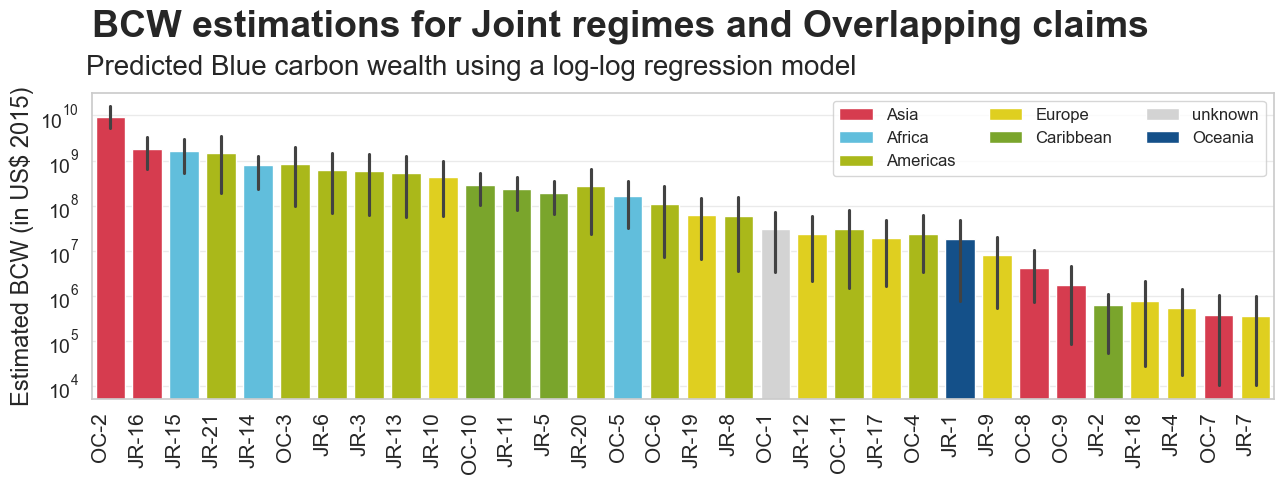

In [ ]:
# preds
df_pred_ci = result_df[['ISO', 'Continent', 'Total BCW_pred', 'Total BCW_pred_lower', 'Total BCW_pred_upper']].copy()
df_pred_ci = df_pred_ci.sort_values(by='Total BCW_pred', ascending=False)
df_pred_ci = df_pred_ci.melt(id_vars=['ISO', 'Continent'], 
                            value_vars=['Total BCW_pred', 'Total BCW_pred_lower', 'Total BCW_pred_upper'],
                            var_name='Type', value_name='Total BCW')
df_pred_ci['Type'] = df_pred_ci['ISO'].apply(
    lambda x: 'Joint regime' if x.startswith('JR-') else ('Overlapping claim' if x.startswith('OC-') else 'Other'))
df_pred_ci['Continent'] = df_pred_ci['Continent'].fillna('unknown')

# estim
df_est_ci = result_df[['ISO', 'Continent', 'Total BCW_est', 'Total BCW_est_low', 'Total BCW_est_high']].copy()
df_est_ci = df_est_ci.sort_values(by='Total BCW_est', ascending=False)
df_est_ci = df_est_ci.melt(id_vars=['ISO', 'Continent'], 
                            value_vars=['Total BCW_est', 'Total BCW_est_low', 'Total BCW_est_high'],
                            var_name='Type', value_name='Total BCW')
df_est_ci['Type'] = df_est_ci['ISO'].apply(
    lambda x: 'Joint regime' if x.startswith('JR-') else ('Overlapping claim' if x.startswith('OC-') else 'Other'))
df_est_ci['Continent'] = df_est_ci['Continent'].fillna('unknown')

# LR
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=df_pred_ci, x='ISO', y='Total BCW', hue='Continent', palette=pal, ax=ax)
plt.title('BCW estimations for Joint regimes and Overlapping claims',
          fontsize=27, fontweight='bold', pad=40, loc='left')
fig.text(0.0725, 0.875, 'Predicted Blue carbon wealth using a log-log regression model', 
         fontsize=20, va='top', ha='left')
plt.ylabel('Estimated BCW (in US$ 2015)', fontsize=17)
plt.xlabel('', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xticks(rotation=90, ha='right', fontsize=15)
plt.legend(fontsize=12, loc='upper right', ncol=3)
plt.tight_layout()
plt.grid(axis='y', alpha=0.4)
plt.show()

## Debt Analysis

Compare BCW to total external debt across countries and economic groups.

In [ ]:
be = df[['country_name', 'ISO', 'Groups', 'Continent', 'Population', 'cBCW', 'cBCW_per_capita', 
         'Total BCW', 'Total BCW_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita',
         'BCW_to_Debt_ratio']].copy()
be.head()

,country_name,ISO,Groups,Continent,Population,cBCW,cBCW_per_capita,Total BCW,Total BCW_per_capita,Debt (2015 US$),Debt (2015 US$)_per_capita,BCW_to_Debt_ratio
0,"Abu musa, Greater and Lesser Tunb",AE,NaN,Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,LDCs,Asia,"41,454,761.0000",NaN,NaN,NaN,NaN,"2,588,228,316.5025",62.4350,NaN
2,Alaska,US-AK,NaN,Americas,NaN,"642,830,100.1929",NaN,"642,830,100.1929",NaN,NaN,NaN,NaN
3,Albania,ALB,Developed economies,Europe,"2,811,655.0000","36,903,385.1708",13.1251,"200,800,073.0626",71.4170,"8,579,785,823.0375","3,051.5073",0.0234
4,Algeria,DZA,Developing economies,Africa,"46,164,219.0000","18,797,922.9248",0.4072,"6,330,608,753.1612",137.1324,"5,523,025,799.7245",119.6387,1.1462


**30 Premiers**

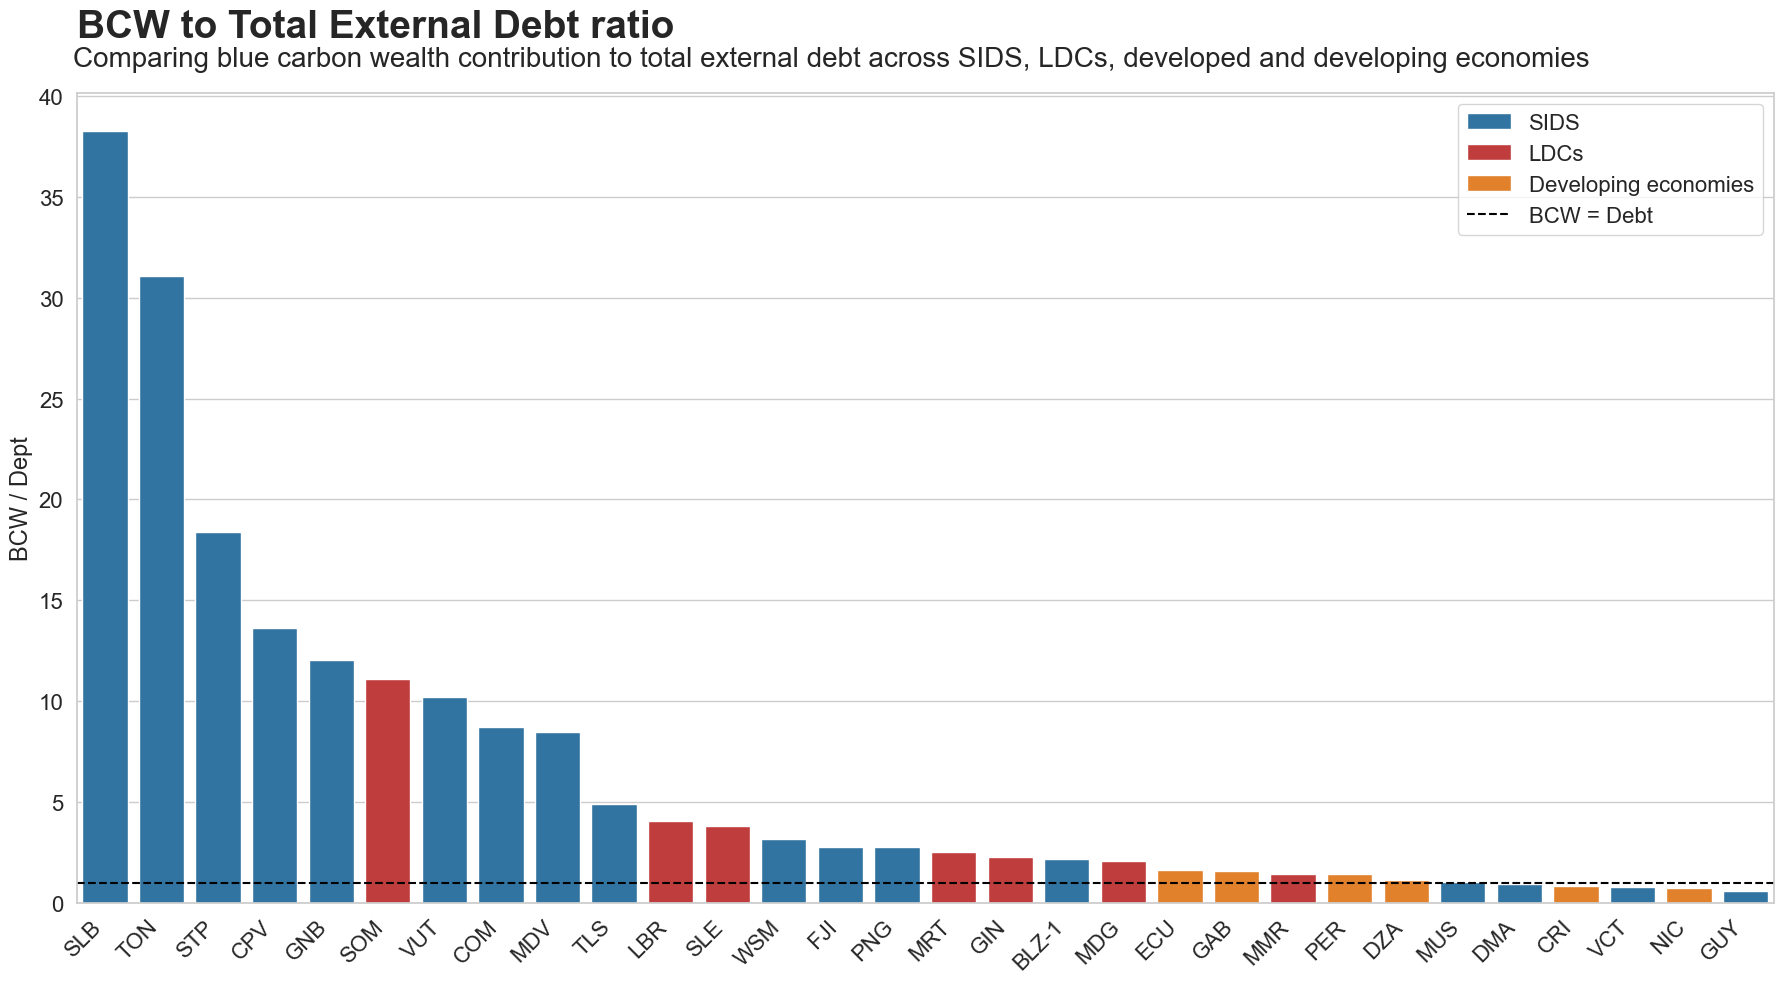

In [ ]:
by_bg = be[['ISO', 'Groups', 'BCW_to_Debt_ratio']]
by_bg = be.sort_values(by='BCW_to_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(18, 10))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:30, :], x='ISO', y='BCW_to_Debt_ratio', palette= color_mapping,ci=False, hue='Groups',ax=ax)
plt.title('BCW to Total External Debt ratio', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.045, 0.945, 'Comparing blue carbon wealth contribution to total external debt across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.axhline(y=1, color='black', linestyle='--', label='BCW = Debt')
plt.ylabel('BCW / Dept', fontsize=17)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tight_layout()
plt.legend(fontsize=16)
plt.show()

**30 Suivants**

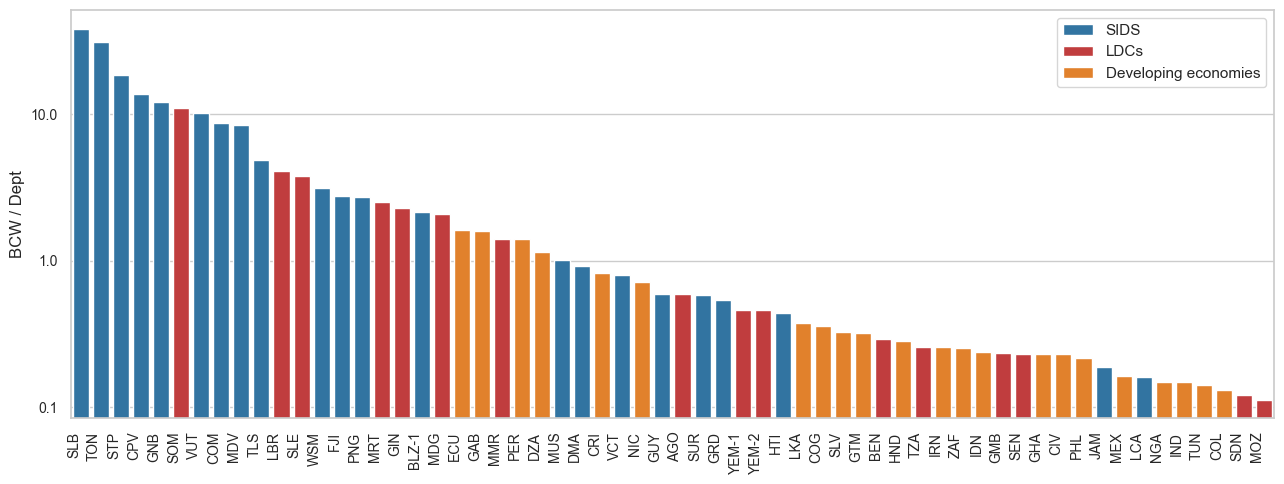

In [ ]:
by_bg = be[['ISO', 'Groups', 'BCW_to_Debt_ratio']].copy()
by_bg = be.sort_values(by='BCW_to_Debt_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:60, :], x='ISO', y='BCW_to_Debt_ratio', ci=False, palette= color_mapping, 
            hue='Groups',ax=ax)
plt.ylabel('BCW / Dept', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=90,ha='right')
plt.tick_params(axis='both', which='major', labelsize=10)
ax.set_yscale("log")
format_log_axis_plain('y')
plt.tight_layout()
plt.legend()
plt.show()

## Summary Table

Country-level summary statistics grouped by economic classification.

In [ ]:
# Select relevant columns
tbl = data[['ISO', 'country_name', 'Groups', 'Continent', 'Area_EEZ_KM2',
            'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita', 'GDP', 'GDP_per_capita',
            'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']].copy()

# Numerical columns to summarise
num_cols = ['Area_EEZ_KM2', 'Area_EEZ_KM2_per_capita', 'Total BCW', 'Total BCW_per_capita',
            'GDP', 'GDP_per_capita', 'Debt (2015 US$)', 'Debt (2015 US$)_per_capita']

# Conversion factors for units
conversion_factors = {
    'Area_EEZ_KM2':               1 / 1_000,
    'Total BCW':                  1 / 1_000_000_000,
    'Total BCW_per_capita':       1,
    'GDP':                        1 / 1_000_000_000,
    'GDP_per_capita':             1,
    'Debt (2015 US$)':            1 / 1_000_000_000,
    'Debt (2015 US$)_per_capita': 1,
}

# Stats for all countries
results = [stats_for_group(tbl, 'All-Countries', num_cols, conversion_factors)]

# Stats for each group
for g in sorted(tbl['Groups'].dropna().unique()):
    sub_df = tbl[tbl['Groups'] == g]
    results.append(stats_for_group(sub_df, g, num_cols, conversion_factors))

# Fusion and formatting
summary_final = pd.concat(results, ignore_index=True)
summary_final.columns = [
    "Groups", "No.", "Stat",
    "EEZ Area (1,000 km²)", "EEZ per capita",
    "Total BCW (billion US$)", "Total BCW per capita",
    "GDP (billion US$)", "GDP per capita",
    "TED (billion US$)", "TED per capita",
]

summary_final.to_csv(SUMMARY_DIR / 'data_summary.csv', index=False, float_format='%.2f')
summary_final


## Supplementary Figures

Additional bar charts and combined plots for publication appendix.

### Coastal BCW Country-Level

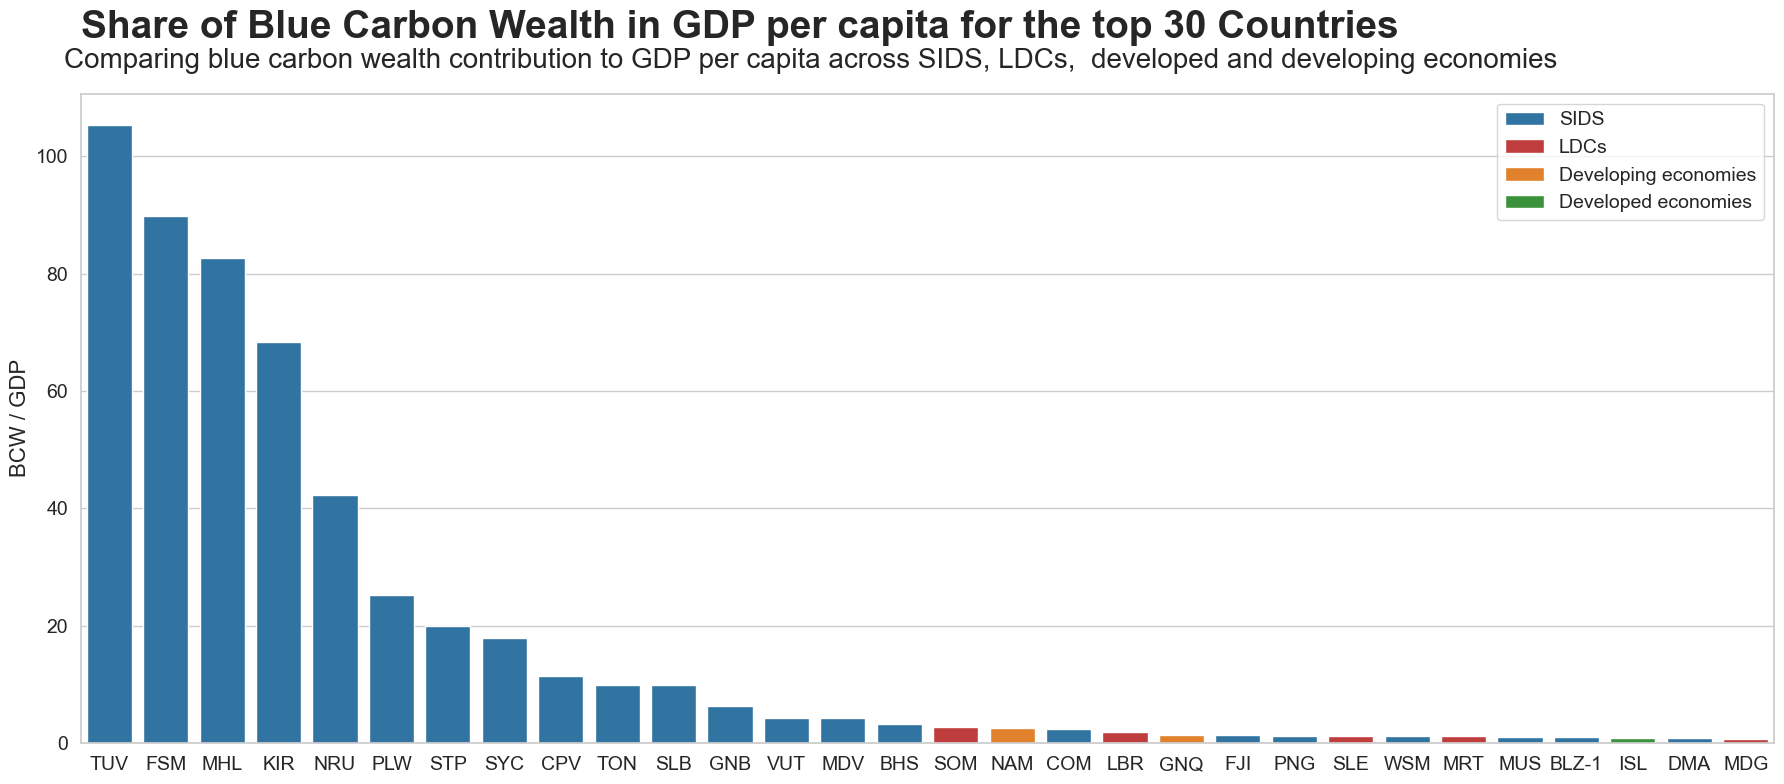

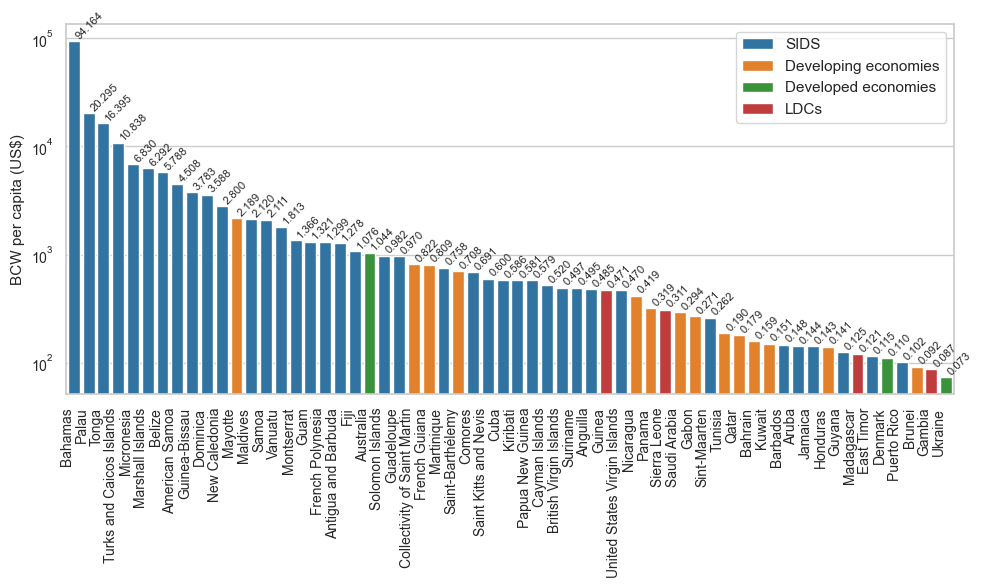

In [ ]:
by_bg = df[['ISO', 'Groups', 'BCW_to_GDP_ratio']]
by_bg = by_bg.sort_values(by='BCW_to_GDP_ratio', ascending=False)

fig, ax = plt.subplots(figsize=(18, 8))
sns.set_theme(style='whitegrid')
sns.barplot(by_bg.iloc[:30, :], x='ISO', y='BCW_to_GDP_ratio', palette= color_mapping,
 hue='Groups',ax=ax)
plt.title('Share of Blue Carbon Wealth in GDP per capita for the top 30 Countries', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.04, 0.93, 'Comparing blue carbon wealth contribution to GDP per capita across SIDS, LDCs,  developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.ylabel('BCW / GDP', fontsize=16)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()

# ============================================================================================================
by_country = df[['country_name', 'cBCW_per_capita', 'Groups']]
by_country = by_country.dropna(subset='Groups')
by_country = by_country.sort_values(by='cBCW_per_capita', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(60), y='cBCW_per_capita', x='country_name', palette= color_mapping,
 hue='Groups',ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)

plt.ylabel('BCW per capita (US$)', fontsize=11)
plt.xlabel('', fontsize=14)
plt.xticks(rotation=90, ha='right')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

# ============================================================================================================
# by_bg = df[['country_name', 'Groups', 'cBCW', 'Debt (2015 US$)']]
# by_bg['BCW_Dept_Ratio'] = by_bg['cBCW'] / by_bg['Debt (2015 US$)']
# by_bg = by_bg.sort_values(by='BCW_Dept_Ratio', ascending=False)

# fig, ax = plt.subplots(figsize=(9, 10))
# sns.set_theme(style='whitegrid')
# sns.barplot(by_bg.head(60), x='BCW_Dept_Ratio', y='country_name', ci=False, palette= color_mapping,
#  hue='Groups',ax=ax)
# plt.xlabel('Coastal BCW / Dept', fontsize=11)
# plt.ylabel('', fontsize=14)
# plt.tick_params(axis='both', which='major', labelsize=10)
# ax.set_xscale("log")
# format_log_axis_plain('x')
# plt.tight_layout()
# plt.legend()
# plt.show()

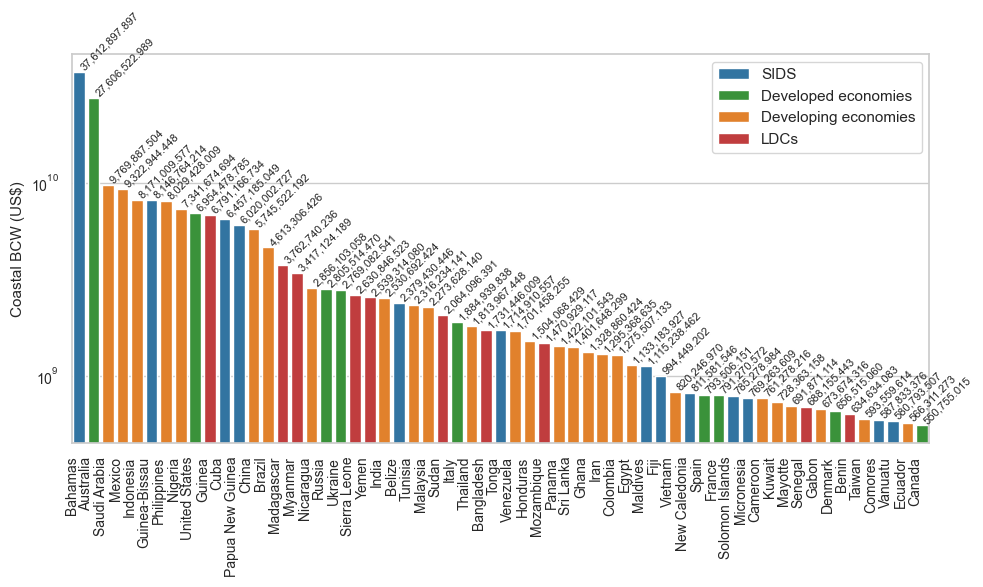

In [ ]:
by_country = df[['country_name', 'cBCW', 'Groups']]
by_country = by_country.dropna(subset='Groups')
by_country = by_country.sort_values(by='cBCW', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style='whitegrid')
sns.barplot(by_country.head(60), y='cBCW', x='country_name', palette= color_mapping,
 hue='Groups',ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)

plt.ylabel('Coastal BCW (US$)', fontsize=11)
plt.xlabel('', fontsize=14)
plt.xticks(rotation=90, ha='right')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

### Total BCW Country-Level

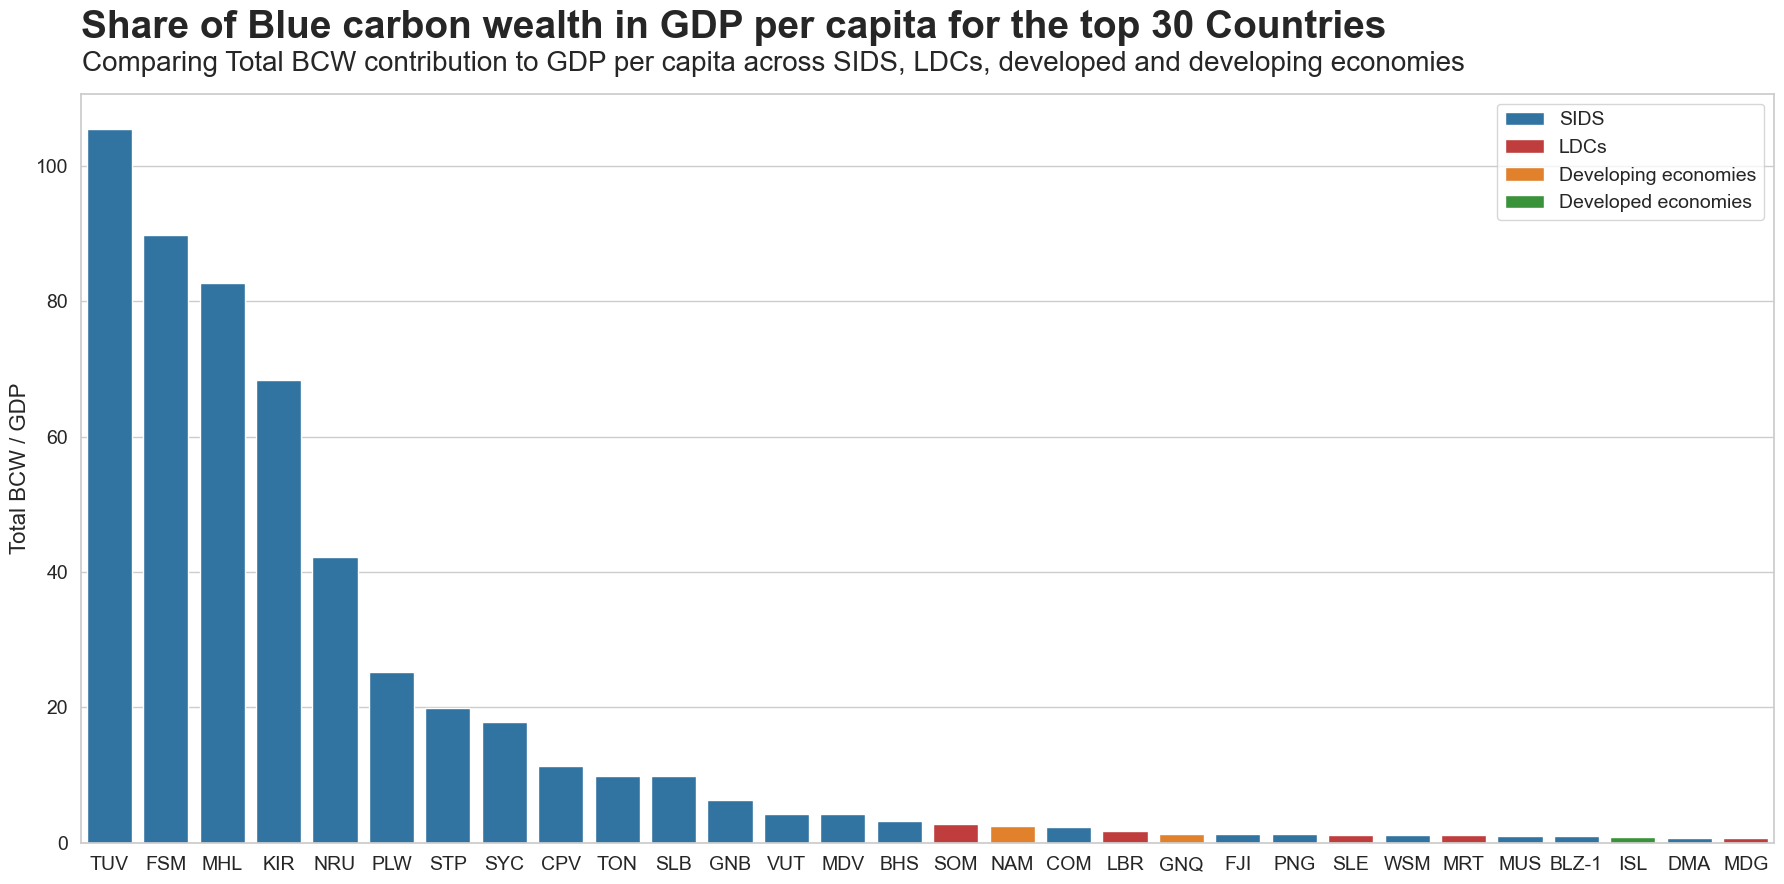

In [ ]:
# 1. Total BCW per capita / GDP per capita
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_per_capita'] / df['GDP_per_capita']
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_GDP_per_capita_ratio'].replace([np.inf, -np.inf], np.nan)

by_bg = df[['ISO', 'Groups', 'Total BCW_GDP_per_capita_ratio']].sort_values(by='Total BCW_GDP_per_capita_ratio', ascending=False)
fig, ax = plt.subplots(figsize=(18, 9))
sns.barplot(data=by_bg.head(30), x='ISO', y='Total BCW_GDP_per_capita_ratio', palette=color_mapping, hue='Groups', ax=ax)
plt.title('Share of Blue carbon wealth in GDP per capita for the top 30 Countries', 
         fontsize=28, fontweight='bold', loc='left', pad=40)
fig.text(0.05, 0.935, 'Comparing Total BCW contribution to GDP per capita across SIDS, LDCs, developed and developing economies', 
         fontsize=20, va='top', ha='left')
plt.ylabel('Total BCW / GDP', fontsize=16)
plt.xlabel('')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()

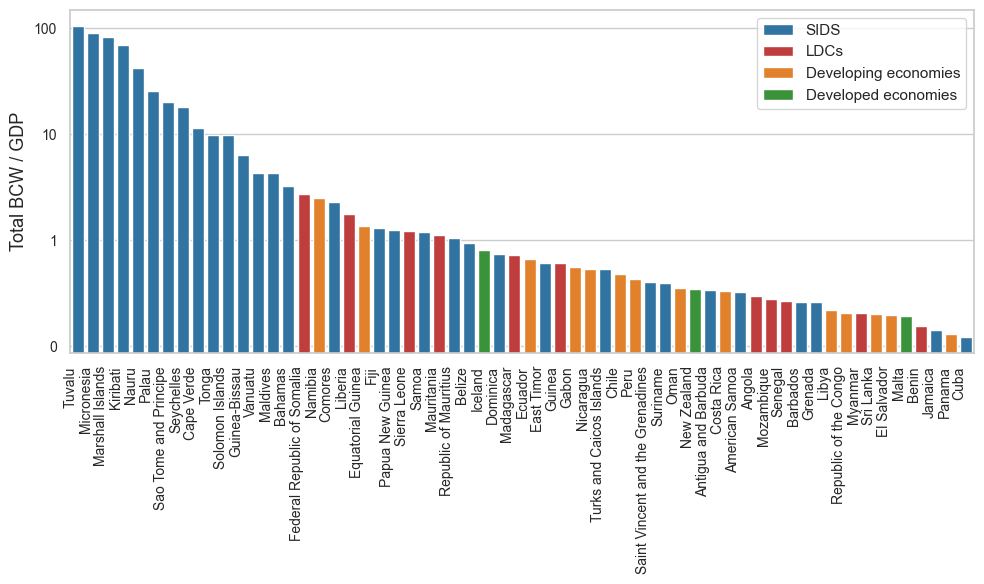

In [ ]:
# 1. Total BCW per capita / GDP per capita
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_per_capita'] / df['GDP_per_capita']
df['Total BCW_GDP_per_capita_ratio'] = df['Total BCW_GDP_per_capita_ratio'].replace([np.inf, -np.inf], np.nan)

by_bg = df[['country_name', 'Groups', 'Total BCW_GDP_per_capita_ratio']].sort_values(by='Total BCW_GDP_per_capita_ratio', ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=by_bg.head(60), x='country_name', y='Total BCW_GDP_per_capita_ratio', palette=color_mapping, hue='Groups', ax=ax)
plt.ylabel('Total BCW / GDP', fontsize=13)
plt.yscale("log")
format_log_axis_plain('y')
plt.xlabel('')
plt.xticks(rotation=90, ha='right')
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend(fontsize=11)
plt.show()

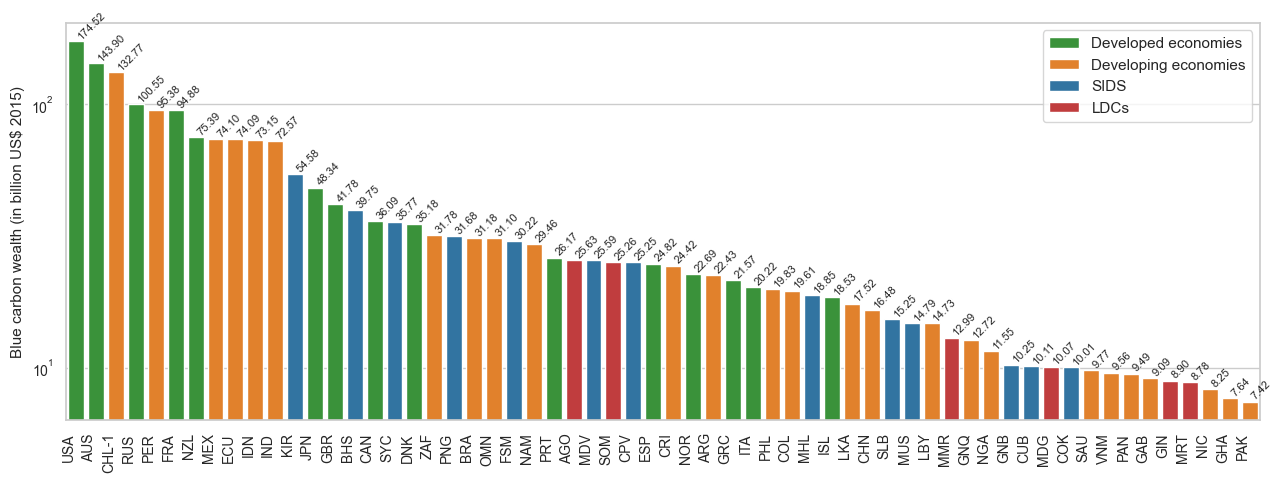

In [ ]:
# 2. Total BCW absolute value by country
by_countryx = df[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW', ascending=False)
by_countryx['Total BCW'] = by_countryx['Total BCW'] / 1e9
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=by_countryx.head(60), y='Total BCW', x='ISO', palette=color_mapping, hue='Groups', ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.2f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='right', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.show()

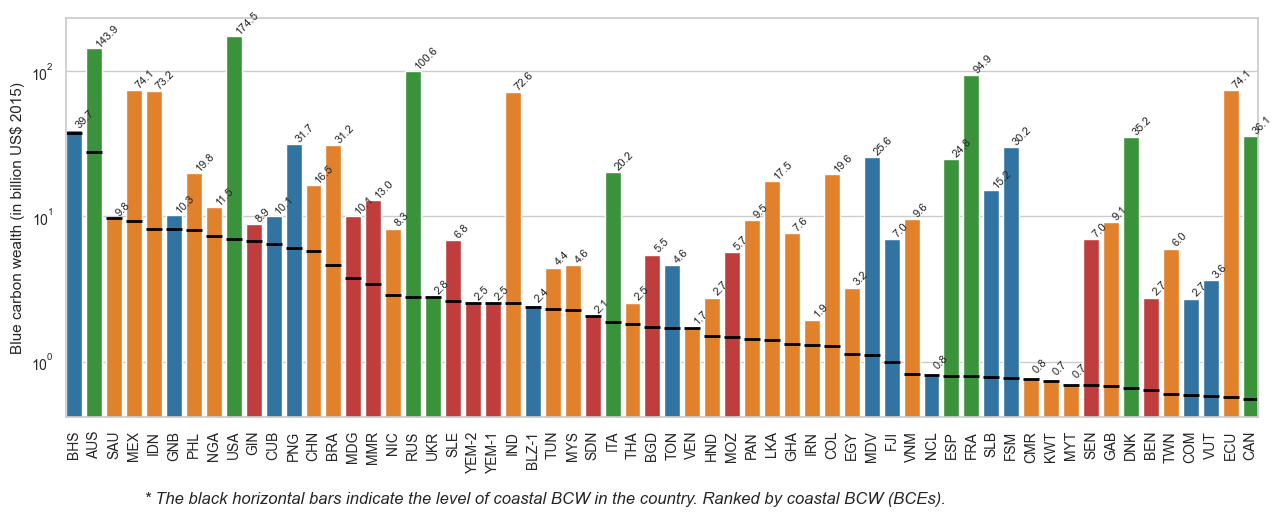

In [ ]:
# 2. Total BCW absolute value by country
by_country = df[['ISO', 'Total BCW', 'cBCW', 'Groups']].dropna(subset=['Groups']).sort_values(by='cBCW', ascending=False)
by_country['Total BCW'] = by_country['Total BCW']/1e9
by_country['cBCW'] = by_country['cBCW']/1e9
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(13, 5))

# 1) Barres Total BCW
sns.barplot(
    data=top,
    y='Total BCW', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW']) else row['cBCW']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height:,.1f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth (in billion US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center', fontsize=14)
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.425, 0, 
    "* The black horizontal bars indicate the level of coastal BCW in the country. Ranked by coastal BCW (BCEs).",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

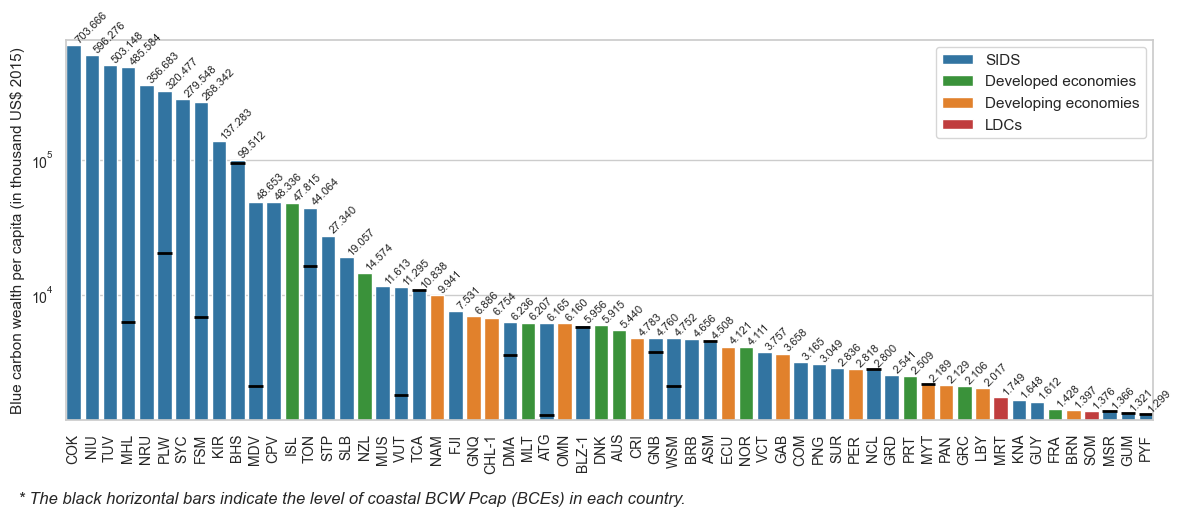

In [ ]:
# Total BCW_per_capita absolute value by country
by_country = df[['ISO', 'Total BCW_per_capita', 'cBCW_per_capita', 'Groups']].dropna(subset=['Groups']).sort_values(by='Total BCW_per_capita', ascending=False)
top = by_country.head(60)

fig, ax = plt.subplots(figsize=(12, 5))

# Bars for Total BCW_per_capita
sns.barplot(
    data=top,
    y='Total BCW_per_capita', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

ymin = top['Total BCW_per_capita'].replace(0, np.nan).min()          
ymax = top['Total BCW_per_capita'].max()
ax.set_yscale('log')
ax.set_ylim(ymin*0.9, ymax*1.1)                     
ax.autoscale(enable=False, axis='y')                 

for i, row in by_country.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW_per_capita']) else row['cBCW_per_capita']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,   
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth per capita (in thousand US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center')
# ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.figtext(
    0.3, 0, 
    "* The black horizontal bars indicate the level of coastal BCW Pcap (BCEs) in each country.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

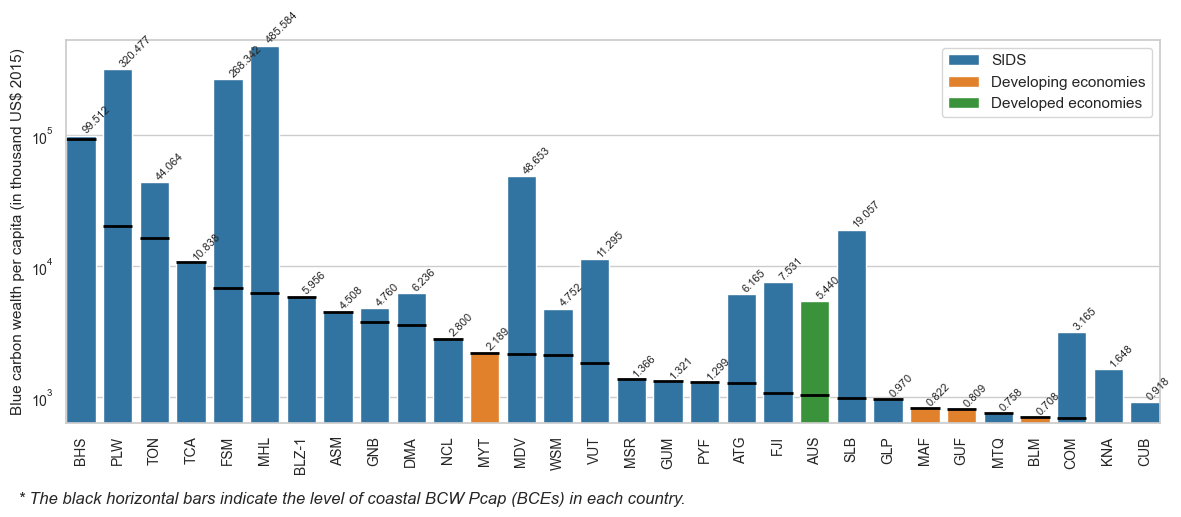

In [ ]:
by_country = df[['ISO', 'Total BCW_per_capita', 'cBCW_per_capita', 'Groups']].dropna(subset=['Groups']).sort_values(by='cBCW_per_capita', ascending=False)
top = by_country.head(30)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=top,
    y='Total BCW_per_capita', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)
ymin = top['Total BCW_per_capita'].replace(0, np.nan).min()          
ymax = top['Total BCW_per_capita'].max()
ax.set_yscale('log')
ax.set_ylim(ymin*0.9, ymax*1.1)                    
ax.autoscale(enable=False, axis='y')                

for i, row in by_country.head(30).reset_index().iterrows():
    bcw = 0 if pd.isna(row['cBCW_per_capita']) else row['cBCW_per_capita']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,   
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.05, f'{height/1e3:,.3f}',
                ha='left', va='bottom', rotation=45, fontsize=8)
plt.ylabel('Blue carbon wealth per capita (in thousand US$ 2015)', fontsize=11)
plt.xlabel('')
plt.xticks(rotation=90, ha='center')
# ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend()
plt.figtext(
    0.3, 0, 
    "* The black horizontal bars indicate the level of coastal BCW Pcap (BCEs) in each country.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

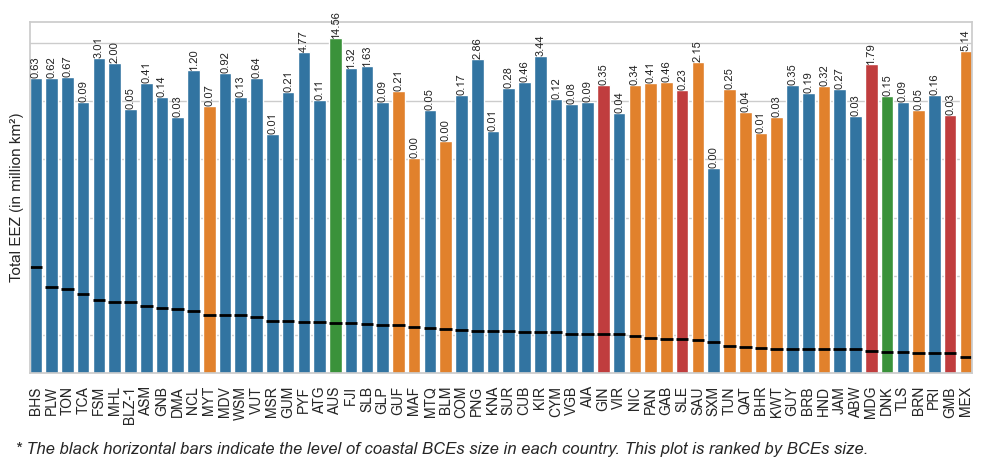

In [ ]:
by_eez = df.copy()
by_eez['EEZ'] = by_eez['Area_EEZ_KM2']
by_eez['BCEs_size'] = by_eez[['mangroves_area_km2', 'saltmarshes_area_km2', 'seagrasses_area_km2']].sum(axis=1)
by_eez['BCEs_size'] = by_eez['BCEs_size'] / by_eez['Population']
by_eez = by_eez[['ISO', 'Groups', 'EEZ', 'BCEs_size'
             ]].dropna(subset=['Groups']).sort_values(by='BCEs_size', ascending=False)
top = by_eez.head(60)

fig, ax = plt.subplots(figsize=(10, 4.5))

sns.barplot(
    data=top,
    y='EEZ', x='ISO',
    palette=color_mapping, hue='Groups', ax=ax
)
ax.margins(x=0)

for i, row in by_eez.head(60).reset_index().iterrows():
    bcw = 0 if pd.isna(row['BCEs_size']) else row['BCEs_size']
    ax.hlines(
        y=bcw,
        xmin=i - 0.4, xmax=i + 0.4,  
        colors="black", linewidth=2
    )
 
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2, height + 0.1, f'{height/1e6:,.2f}',
                ha='center', va='bottom', rotation=90, fontsize=8)
plt.ylabel('Total EEZ (in million km²)', fontsize=11)
plt.xlabel('')
# remove y tick labels
ax.set_yticklabels([], visible=False)
plt.xticks(rotation=90, ha='center')
ax.set_yscale("log")
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.legend().remove()
plt.figtext(
    0.45, 0, 
    "* The black horizontal bars indicate the level of coastal BCEs size in each country. This plot is ranked by BCEs size.",
    ha="center", va="top", fontsize=12, style="italic"
)
plt.show()

In [ ]:
print('Well Done !')

Well Done !
